# Analyse des déterminants du marché du sucre

Le sucre est l'une des principales matières premières agricoles, jouant un rôle crucial dans l'économie mondiale, notamment pour les pays exportateurs comme le Brésil. Comprendre les déterminants de son prix est essentiel pour les acteurs du marché afin de mieux anticiper les fluctuations dues aux conditions climatiques ou aux chocs macroéconomiques. De plus, dans un contexte de dérèglement climatique et de volatilité accrue des marchés de l'énergie, cette analyse permet d'identifier les risques potentiels pour la stabilité des prix des matières premières.

Ce projet vise à analyser l'impact des facteurs climatiques (température, précipitations, humidité) ainsi que des variables macroéconomiques (prix du pétrole, taux de change BRL/USD) sur le prix du sucre à l'aide de méthodes d'économétrie des séries temporelles. En utilisant des modèles ARMA et VAR, l'objectif est de mieux comprendre la dynamique entre ces variables pour réaliser des prévisions sur les variations futures du prix du sucre.

## Introduction

Le sucre, souvent surnommé "or blanc", est l'une des matières premières agricoles les plus importantes au monde. Historiquement, il a joué un rôle central dans le développement économique de nombreux pays, notamment pendant l'ère coloniale, où il était une source de richesse pour les puissances européennes. Aujourd'hui, le sucre continue d'avoir un impact significatif sur les économies de nombreux pays, en particulier ses principaux producteurs et exportateurs mondiaux comme l'Inde, la Thaïlande et le Brésil.

Pour mieux comprendre cette dynamique, il est essentiel d'examiner le cas du Brésil, le plus grand producteur et exportateur de sucre au monde, représentant environ 50 % des exportations mondiales de cette denrée. L'économie brésilienne est fortement tributaire des exportations de matières premières, et les fluctuations du prix du sucre ont des répercussions directes sur la balance commerciale, les revenus des agriculteurs, et le marché du travail rural.

La production de sucre repose principalement sur la canne à sucre, une plante extrêmement sensible aux conditions climatiques. Des fluctuations dans la température, les précipitations, et l'humidité peuvent affecter les rendements des cultures, entraînant des variations importantes dans l'offre et, par conséquent, dans les prix.

Cependant, le prix du sucre ne dépend pas uniquement des conditions climatiques. Il est également influencé par des facteurs macroéconomiques tels que les coûts de l'énergie et les taux de change. En effet, le prix du pétrole joue un rôle crucial dans la détermination des coûts de production du sucre, car il impacte à la fois le transport, l'irrigation, et les intrants agricoles comme les engrais. De plus, le Brésil utilise une part significative de sa production de canne à sucre pour la production d'éthanol, un substitut au carburant dérivé du pétrole. Ainsi, les variations du prix du pétrole peuvent entraîner un arbitrage entre la production de sucre et celle d'éthanol, influençant ainsi directement l'offre de sucre sur le marché international.

Enfin, il ne faut pas oublier le rôle des taux de change. Le taux de change entre le réal brésilien (BRL) et le dollar américain (USD) est un autre facteur clé à considérer. Comme la majorité des transactions mondiales de sucre sont libellées en dollars, une dépréciation du réal brésilien rend les exportations brésiliennes plus compétitives, augmentant ainsi la rentabilité pour les producteurs locaux. À l'inverse, une appréciation du réal brésilien peut réduire la compétitivité du sucre brésilien sur le marché mondial, affectant les volumes d'exportation et, par ricochet, les prix internationaux.

Dans le contexte actuel, marqué par une instabilité économique mondiale, la récente crise énergétique, exacerbée par des tensions géopolitiques, a conduit à des hausses du prix du pétrole, affectant les coûts de production agricole. Parallèlement, les chocs climatiques deviennent de plus en plus fréquents, mettant en péril la sécurité alimentaire à l'échelle mondiale. Ces dynamiques créent une volatilité accrue sur les marchés des matières premières, rendant essentiel l'usage d'outils économétriques pour prévoir les prix et mieux anticiper les impacts sur les économies des pays exportateurs.

Il convient alors de se demander comment les facteurs climatiques, le prix du pétrole et les fluctuations du taux de change influencent le prix du sucre sur le marché mondial.

Afin de répondre à ces questions, après avoir présenté les données et les séries temporelles utilisées, nous réaliserons une analyse univariée du prix du sucre. Ensuite, nous estimerons un modèle VAR afin d'examiner l'influence de nos variables sur le prix du sucre. Finalement, nous discuterons des résultats et expliciterons les implications économiques.


### Préliminaire

Pour mener à bien ce projet sur R, il est nécessaire de télécharger un certain nombre de bibliothèques indispensables à l’analyse des données et à la modélisation. Par souci de réplicabilité (et pour gagner du temps), il est préférable d'avoir un même environnement d'une session à l'autre, c'est-à-dire les mêmes bibliothèques et le même jeu de données.

On récupère [les bibliothèques](https://drive.google.com/file/d/1ZRko34j4ILbpVJW719piRbAcrj2nDxUl/view?usp=drive_link) et [la base de données](https://docs.google.com/spreadsheets/d/1Glil_wBRK6c7RQQl0HOzKDhbOQryLrey/edit?usp=drive_link&ouid=116602512760070114686&rtpof=true&sd=true) depuis Google Drive.

In [1]:
# Téléchargement du dossier compressé comprenant les bibiliothèques
system("gdown --id 1ZRko34j4ILbpVJW719piRbAcrj2nDxUl")
# Décompression du dossier
untar("library.tar.gz", "library")

# Mise en place de l'environnement par défaut
Sys.setenv("R_LIBS_USER"="library")

# Téléchargement de la base de données
system("gdown --id 1Glil_wBRK6c7RQQl0HOzKDhbOQryLrey")

(NB : En cas de problème lors du téléchargement, les bibliothèques peuvent être installées en lançant le code suivant.)

```
.libPaths("library")
install.packages('readxl')
install.packages('ggplot2')
install.packages('gridExtra')
install.packages('urca')
install.packages('zoo')
install.packages('lmtest')
install.packages("xts")
install.packages("TTR")
install.packages("quadprog")
install.packages("quantmod")
install.packages("fracdiff")
install.packages("timeDate")
install.packages("tseries")
install.packages("RcppArmadillo")
install.packages('forecast')
install.packages('sandwich')
install.packages("plyr")
install.packages("reshape2")
install.packages("moments")
install.packages("Metrics")
install.packages("tsm")
install.packages("FinTS")
install.packages("miscTools")
install.packages("rbibutils")
install.packages("iterators")
install.packages("bdsmatrix")
install.packages("collapse")
install.packages("maxLik")
install.packages("maRdpackxLik")
install.packages("foreach")
install.packages("Formula")
install.packages("doParallel")
install.packages("Rdpack")
install.packages("plm")
install.packages("lpirfs")
install.packages("strucchange")
install.packages("vars")
install.packages("deSolve")
install.packages("mnormt")
install.packages("tseriesChaos")
install.packages("tsDyn")
```



In [2]:
# Chargement des bibliothèques nécéssaires
.libPaths("library")
library(doParallel)
library(FinTS)
library(forecast)
library(foreach)
library(ggplot2)
library(gridExtra)
library(lmtest)
library(lpirfs)
library(moments)
library(parallel)
library(readxl)
library(reshape2)
library(sandwich)
library(tsDyn)
library(tseries)
library(urca)
library(vars)
library(zoo)

Loading required package: foreach

Loading required package: iterators

Loading required package: parallel

Loading required package: zoo


Attaching package: ‘zoo’


The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric


Registered S3 method overwritten by 'quantmod':
  method            from
  as.zoo.data.frame zoo 


Attaching package: ‘forecast’


The following object is masked from ‘package:FinTS’:

    Acf


Loading required package: MASS

Loading required package: strucchange



## 1 &emsp; Présentation des données

Pour analyser les déterminants du prix du sucre, nous avons collecté des données, couvrant la période de janvier 2000 à août 2024, sur le prix du sucre, les facteurs climatiques au Brésil (température, humidité, précipitations...) et des variables macroéconomiques (prix du pétrole et taux de change BRL/USD).

Dans cette première partie, nous présenterons le prix du sucre et le prix du pétrole. Pour une lecture plus approfondie, les autres variables seront présentées en annexe.

#### Importation et visualisation des données

In [ ]:
# Création d'un DataFrame pour visualiser les séries
df <- read_excel("data/data.xlsx","monthly") # (options: daily, monthly)
str(df)

tibble [296 × 9] (S3: tbl_df/tbl/data.frame)
 $ Date                                      : POSIXct[1:296], format: "2000-01-01" "2000-02-01" ...
 $ Sugar Price ($ per pound)                 : num [1:296] 0.0558 0.0526 0.0527 0.0618 0.0705 ...
 $ Temperature (°C)                          : num [1:296] 22.8 22.6 22 21.2 18.5 ...
 $ Rainfall (mm)                             : num [1:296] 207.47 170.38 143.16 6.61 9.72 ...
 $ Relative Humidity (%)                     : num [1:296] 0.77 0.787 0.784 0.723 0.713 ...
 $ Wind Speed (m/s)                          : num [1:296] 2.8 3.32 3.23 3.11 2.91 2.39 2.57 3.01 3.54 3.25 ...
 $ Cloud Cover (%)                           : num [1:296] 0.778 0.803 0.762 0.453 0.486 ...
 $ Europe Brent Spot Price FOB ($ per Barrel): num [1:296] 25.4 27.8 27.6 22.9 27.8 ...
 $ Exchange Rate (BRL/USD)                   : num [1:296] 1.8 1.78 1.74 1.77 1.83 ...


In [4]:
# Visualisation du DataFrame
head(df)
tail(df)

# [Optionnel] Export des Head & Tail du DataFrame en CSV
#write.csv(head(df),"data_head.csv",row.names = TRUE)
#write.csv(tail(df),"data_tail.csv",row.names = TRUE)

Date,Sugar Price ($ per pound),Temperature (°C),Rainfall (mm),Relative Humidity (%),Wind Speed (m/s),Cloud Cover (%),Europe Brent Spot Price FOB ($ per Barrel),Exchange Rate (BRL/USD)
<dttm>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2000-01-01,0.0558,22.84,207.47,0.7701,2.80,0.7779,25.35,1.8038
2000-02-01,0.0526,22.62,170.38,0.7875,3.32,0.8035,27.79,1.7760
2000-03-01,0.0527,21.98,143.16,0.7837,3.23,0.7618,27.57,1.7418
2000-04-01,0.0618,21.20,6.61,0.7230,3.11,0.4527,22.95,1.7706
2000-05-01,0.0705,18.48,9.72,0.7126,2.91,0.4857,27.79,1.8294
2000-06-01,0.0843,18.52,10.79,0.6876,2.39,0.3439,29.68,1.8096


Date,Sugar Price ($ per pound),Temperature (°C),Rainfall (mm),Relative Humidity (%),Wind Speed (m/s),Cloud Cover (%),Europe Brent Spot Price FOB ($ per Barrel),Exchange Rate (BRL/USD)
<dttm>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2024-03-01,0.2178,23.50,311.86,0.7963,3.55,0.6842,85.50,4.9833
2024-04-01,0.2060,22.87,67.45,0.7533,3.36,0.6013,89.94,5.1307
2024-05-01,0.1880,21.12,67.26,0.7231,3.36,0.5933,81.85,5.1332
2024-06-01,0.1917,19.48,0.54,0.6973,2.79,0.5421,82.31,5.3884
2024-07-01,0.1933,17.53,91.56,0.7631,2.85,0.6593,85.13,5.5398
2024-08-01,0.1844,18.88,84.36,0.6347,3.02,0.5637,80.42,5.5531


#### 1.1 &emsp; Le prix du sucre

Pour analyser le prix du sucre, nous avons utilisé des données mensuelles du prix moyen du sucre en dollars par livre, couvrant la période de janvier 2000 à août 2024, provenant de [MacroTrends](https://www.macrotrends.net).

Afin de mieux observer l'impact des variables sur le prix du sucre, il convenait de choisir une fréquence mensuelle plutôt que journalière ou hebdomadaire. En effet, les données climatiques (température, précipitations, etc.) ont généralement un impact observable sur la production agricole sur une échelle de temps plus longue que la semaine ou le jour. De même, les effets de la variation du prix du pétrole ou des taux de change se répercutent aussi sur plusieurs semaines avant d'affecter réellement les prix du sucre.

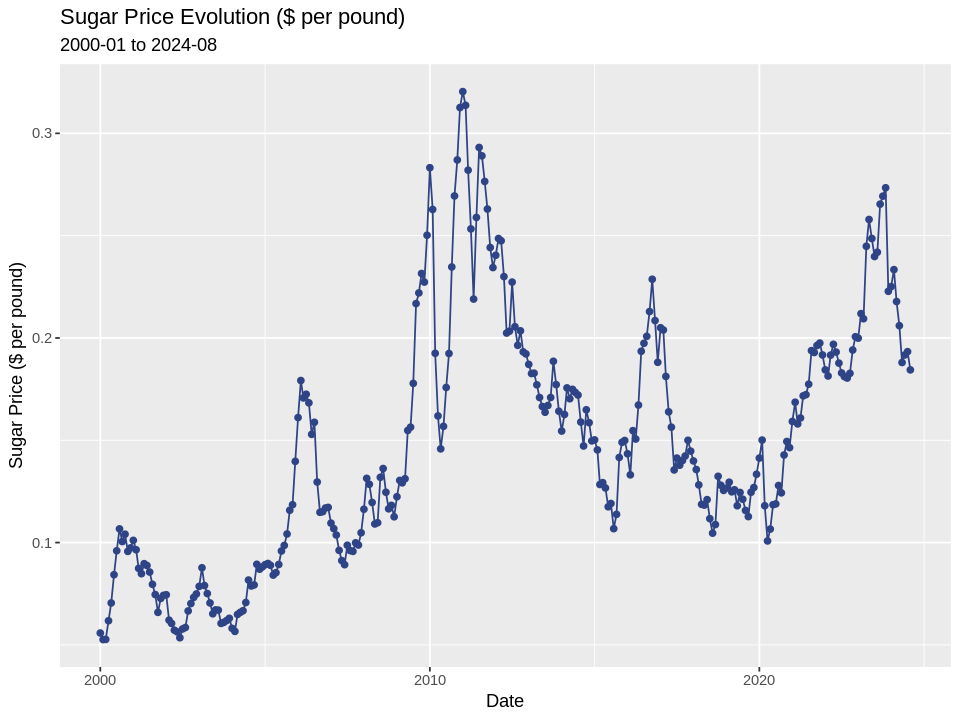

In [5]:
# Création d'un DataFrame avec la date et le prix du sucre
df_sugar_price <- df[, c("Date", "Sugar Price ($ per pound)")]
colnames(df_sugar_price) <- c('date', 'sugar_price')

# Ajustement de la taille du graphique
options(repr.plot.width = 8, repr.plot.height = 6)

# Création du graphique avec ggplot2
p_sugar <- ggplot(data=df_sugar_price, aes(x=date, y=sugar_price)) +
  geom_point(color='#2F4486') +
  geom_line(color='#2F4486') +
  xlab('Date') +
  ylab("Sugar Price ($ per pound)") +
  labs(title=paste("Sugar Price Evolution ($ per pound)"),
        subtitle="2000-01 to 2024-08")

# Affichage du graphique
p_sugar

Une première observation visuelle révèle des fluctuations importantes autour d'une tendance générale à la hausse. Une telle tendance contredit l'hypothèse d'une moyenne constante dans le temps, ce qui suggère que la série est non stationnaire.

De plus, la volatilité de la série semble varier au cours du temps. Des périodes de forte volatilité alternent avec des périodes plus calmes. Cela indique qu'il y a une possible hétéroscédasticité.

Par ailleurs, on peut observer des cycles apparents dans les données. En effet, le prix du sucre est à son minimum annuel en début d'année (aux alentours de janvier, février) puis remonte jusqu'à atteindre son maximum annuel aux alentours de juin-juillet avant de redescendre. La présence de cycles renforce l'idée que le prix du sucre peut s'expliquer par des facteurs saisonniers que sont les facteurs climatiques.

Sur la base de l'analyse visuelle, il est peu probable que la série du prix du sucre soit stationnaire. La présence d'une tendance à long terme, d'une volatilité variable et de cycles suggère qu'un processus de transformation des données est nécessaire avant de pouvoir appliquer nos modèles économétriques standard qui supposent la stationnarité.

Pour confirmer ces observations, examinons l'Autocorrelation Function et le Partial Autocorrelation Function.

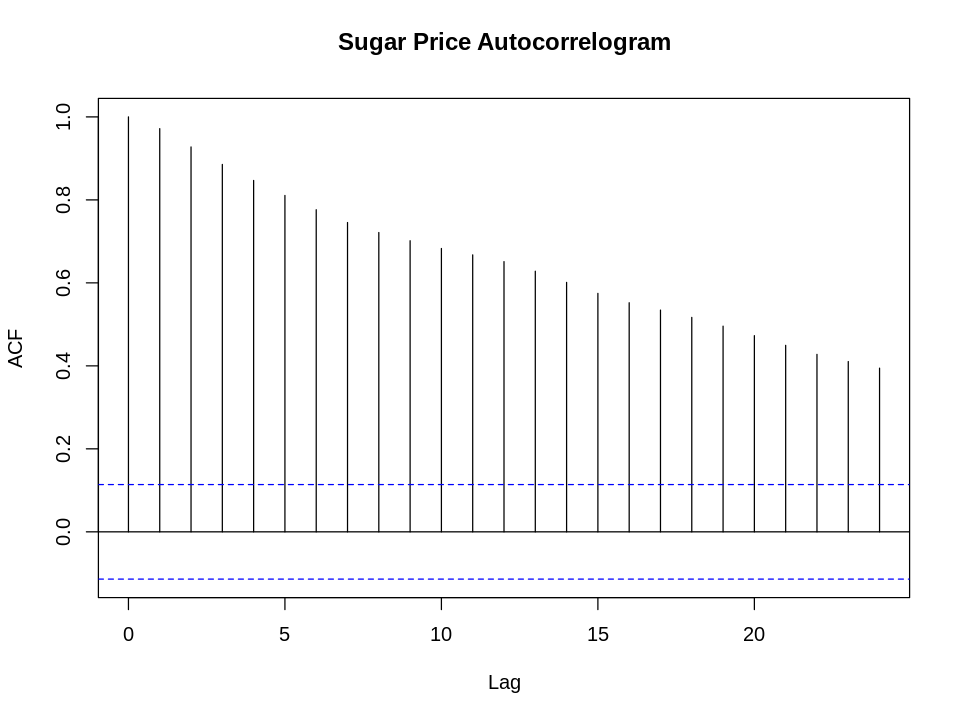

In [6]:
# Ajustement de la taille du graphique
options(repr.plot.width = 8, repr.plot.height = 6)

# Création de la représentation graphique de l'ACF
acf_sugar_price <- acf(df_sugar_price$sugar_price, main = 'Sugar Price Autocorrelogram')

Le graphique de l'ACF montrent une décroissance lente des autocorrélations, ce qui est cohérent avec la présence d'une tendance non stationnaire. En effet, une diminution lente de l'autocorrélation indique une mémoire à long terme dans la série.

Par ailleurs, l'autocorrélation est significatives pour de nombreux lags, suggérant que la série présente une tendance ou une composante saisonnière.

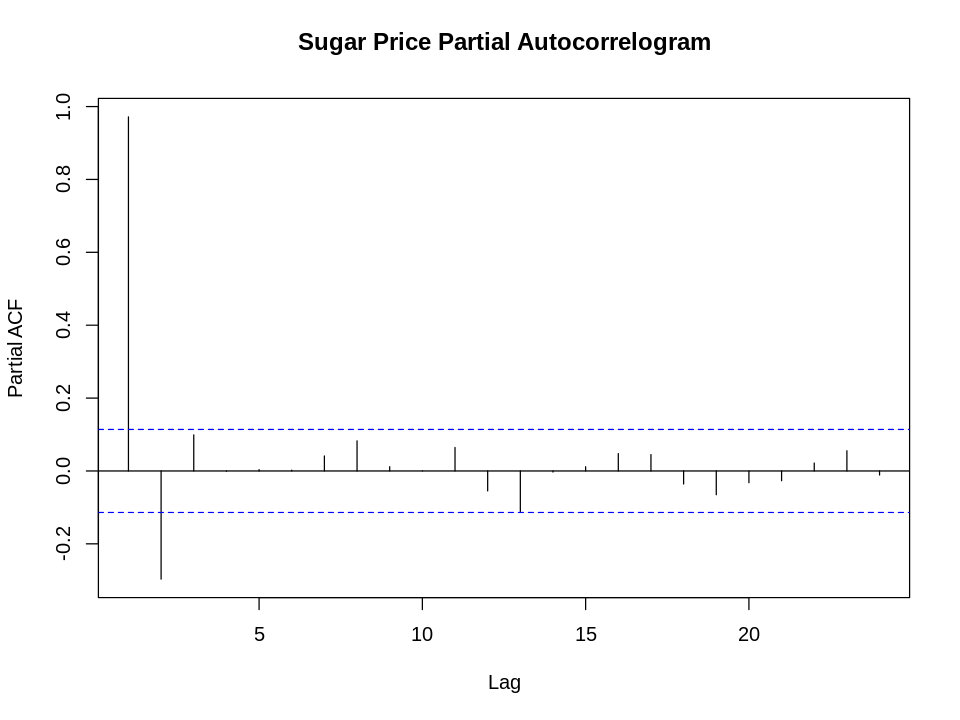

In [7]:
# Ajustement de la taille du graphique
options(repr.plot.width = 8, repr.plot.height = 6)

# Création de la représentation graphique de l'ACF
pacf_sugar_price <- pacf(df_sugar_price$sugar_price, main = 'Sugar Price Partial Autocorrelogram')

Le PACF montre une autocorrélation partielle significative pour le lag 1 et 2, suivie d'une chute rapide à des valeurs proches de zéro. Cela suggère une corrélation directe et forte entre le prix du sucre à un instant t et celui à l'instant t-1 et entre l'instant t et t-2.

L'autocorrélation élevée au lag 1 indique une certaine inertie dans les prix, c'est-à-dire que les prix ont tendance à persister autour de leur niveau précédent.

Ces résultats montrent que la série pourrait être modélisée par un AR(2). De plus, cela confirme que la série n'est pas stationnaire. La présence d'une tendance à long terme, d'une volatilité variable et de cycles saisonniers implique qu'une transformation des données sera nécessaire avant d'appliquer des modèles économétriques standard.

#### 1.2 &emsp; Le prix du pétrole

Afin de mieux comprendre les dynamiques du marché, il est nécessaire d'étudier l'influence des variables macroéconomiques afin d'expliquer le prix du sucre.

Nous avons alors décidé d'analyser le prix moyen mensuel d'un baril de pétrole (Brent) et le taux de change BRL/USD (voir annexe) dont les données sont issues de la [FRED](https://fred.stlouisfed.org/).

Le prix du pétrole, en tant que baromètre des coûts énergétiques mondiaux, affecte directement les coûts liés à la production (engrais, pesticides,...), à l'irrigation des cultures agricoles et au transport du sucre.

De plus, au Brésil, le lien entre pétrole et sucre est renforcé par la production d'éthanol, un biocarburant dérivé de la canne à sucre. Ainsi, une hausse des prix du pétrole peut inciter les producteurs à allouer davantage de canne à sucre à la production d'éthanol, réduisant l'offre de sucre. Ce mécanisme d’arbitrage peut réduire l’offre de sucre sur le marché mondial, provoquant une pression haussière sur les prix internationaux.

Enfin, nous avons décidé de choisir le Brent plutôt que le WTI (West Texas Intermediate) en tant qu'indice de référence du pétrole brut, puisque le Brent est le prix de référence pour les marchés mondiaux. Il reflète mieux les dynamique globales du marché pétrolier par rapport au WTI, qui est plus représentatif du marché nord-américain.

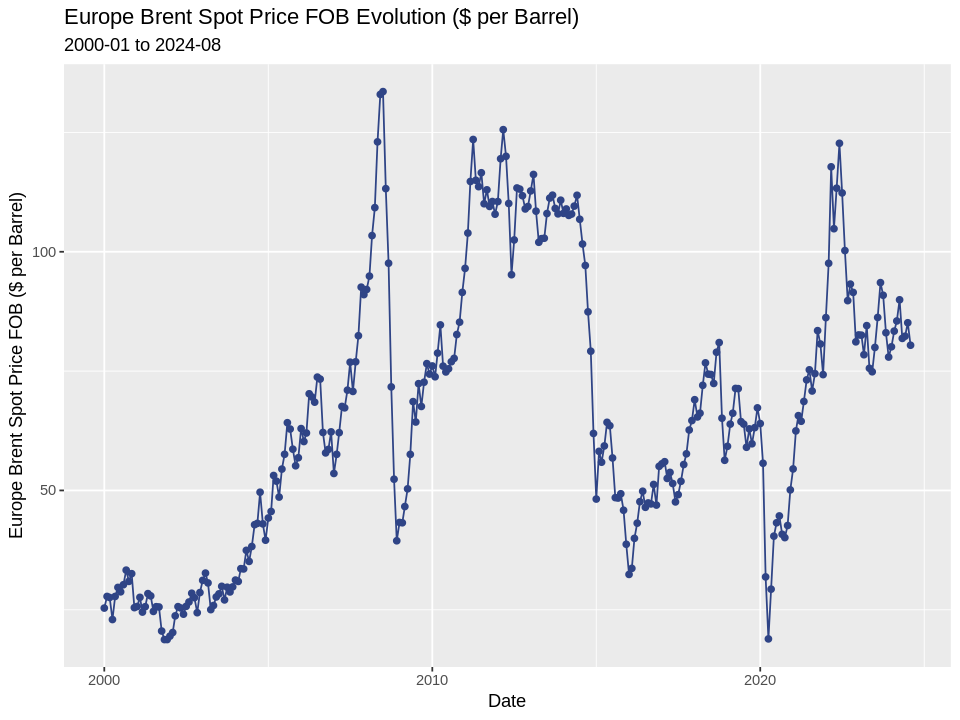

In [8]:
# Création d'un DataFrame avec la date et le prix du pétrole
df_oil_price <- df[, c("Date", "Europe Brent Spot Price FOB ($ per Barrel)")]
colnames(df_oil_price) <- c('date', 'oil_price')

# Ajustement de la taille du graphique
options(repr.plot.width = 8, repr.plot.height = 6)

# Création du graphique avec ggplot2
p_oil <- ggplot(data=df_oil_price, aes(x=date, y=oil_price)) +
  geom_point(color='#2F4486') +
  geom_line(color='#2F4486') +
  xlab('Date') +
  ylab("Europe Brent Spot Price FOB ($ per Barrel)") +
  labs(title=paste("Europe Brent Spot Price FOB Evolution ($ per Barrel)"),
        subtitle="2000-01 to 2024-08")

# Affichage du graphique
p_oil

Le graphique présente tout d'abord une tendance haussière entre 2000 et 2008, culminant à un pic à 133,56 $/baril. Cette augmentation reflète une demande mondiale soutenue.

Cependant, en 2009, avec l’éclatement de la crise financière qui a considérablement réduit la consommation énergétique, une chute brutale des prix s’ensuit.

Après une reprise progressive, le marché subit une nouvelle secousse entre 2014 et 2016, marquée par une baisse significative due à une surproduction de pétrole et un ralentissement de la croissance mondiale.

Par la suite, la pandémie de COVID-19 en 2020 provoque une chute historique des prix, reflétant une baisse drastique de la demande, liée aux confinements et à la réduction des activités économiques.

Aujourd'hui, une reprise partielle est visible, bien que les prix demeurent volatils, en partie sous l’effet des tensions géopolitiques et des perturbations de l’offre.

En somme, la série ne semble pas stationnaire. En effet, la série présente des phases marquées de hausse (2000-2008) et de baisse (2014-2016) prolongées, ainsi que des amplitudes des variations changeantes au fil du temps.

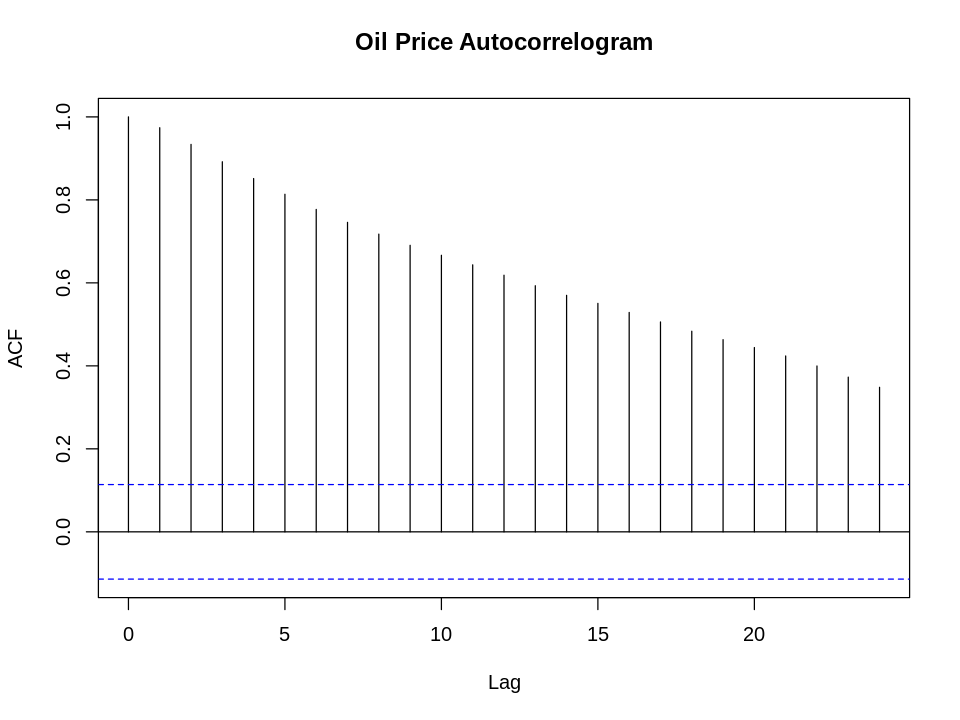

In [9]:
# Ajustement de la taille du graphique
options(repr.plot.width = 8, repr.plot.height = 6)

# Création de la représentation graphique de l'ACF
acf_oil_price <- acf(df_oil_price$oil_price, main = 'Oil Price Autocorrelogram')

L'ACF nous conforte dans l'idée que la série n'est pas stationnaire.

Tout d'abord, il y a une forte persistance des dépendances entre les observations successives, montrée par la décroissance lente des coefficients d'autocorrélation.

Par ailleurs, les barres d'autocorrélation demeurent significatives pour un grand nombre de lags. Cela reflète une mémoire longue dans la série et confirme la présence de corrélations importantes même à des retards élevés.

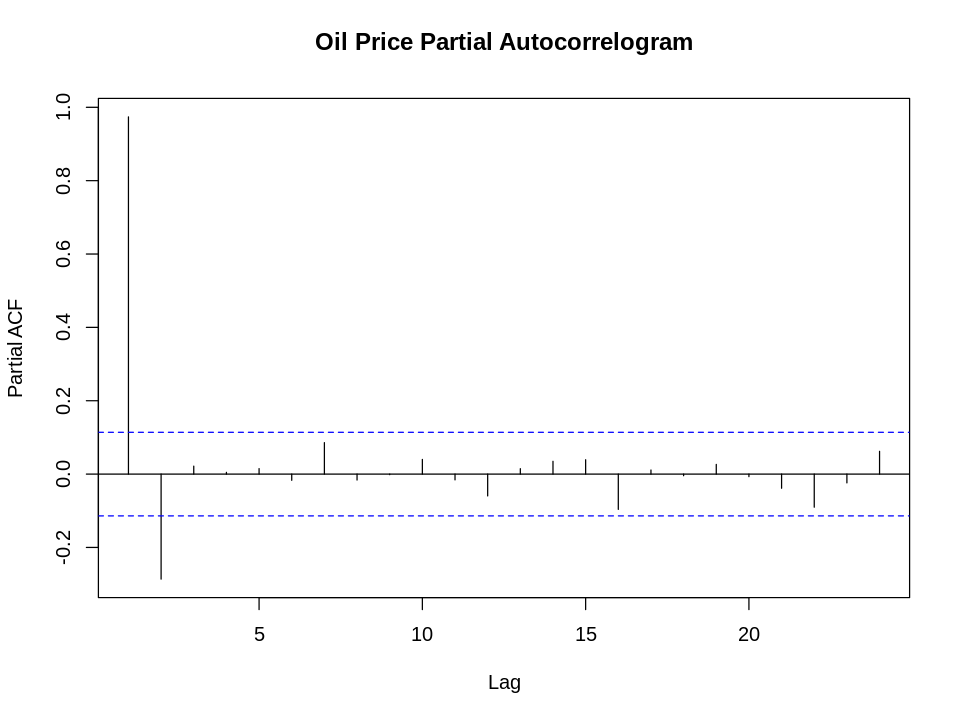

In [10]:
# Ajustement de la taille du graphique
options(repr.plot.width = 8, repr.plot.height = 6)

# Création de la représentation graphique de l'ACF
pacf_oil_price <- pacf(df_oil_price$oil_price, main = 'Oil Price Partial Autocorrelogram')

Le PACF présente des pics significatifs aux premier et deuxième lag, ce qui suggère une corrélation directe et forte entre le prix du pétrole à un instant t et celui à l'instant t-1 et entre l'instant t et t-2. L'autocorrélation élevée au lag 1 indique une certaine inertie dans les prix, c'est-à-dire que les prix ont tendance à persister autour de leur niveau précédent.

Au-delà du premier lag, les coefficients du PACF décroissent rapidement vers zéro et ne dépassent plus les limites de confiance. La corrélation directe entre le prix du pétrole et les prix observés plusieurs périodes auparavant est faible, voire inexistante.

En somme, la série du prix du pétrole pourrait être modélisée par un AR(2) et n’est pas stationnaire. Les tendances prolongées, les variations d’amplitude et les dépendances de longue durée nécessitent également une transformation des données avant d’envisager une modélisation économétrique.

## 2 &emsp; Modélisation univariée

Afin d’analyser les dynamiques propres aux séries temporelles étudiées, nous allons dans cette partie développer une approche de modélisation univariée. Cette méthodologie nous permettrait de mieux comprendre l’évolution des variables, leurs comportements intrinsèques et leurs éventuelles composantes saisonnières ou cycliques, tout en établissant une base pour la prévision.

Après avoir vérifié la stationnarité des séries, en fonction des résultats obtenus, nous appliquerons des transformations pour stationnariser les séries. Une fois les séries stationnaires, nous estimerons un modèle ARIMA sur les prix du sucre en déterminant les spécifications optimales.

### 2.1 &emsp; Tests de racine unitaire

Avant d'entreprendre toute modélisation des séries temporelles, il est essentiel de vérifier leur stationnarité. En effet, pour que les modèles ARIMA soient valides, les séries doivent être stationnaires, c'est-à-dire que leur moyenne et leur variance ne doivent pas dépendre du temps.

Dans cette sous-partie, nous allons appliquer des tests d'Augmented Dickey-Fuller (ADF) et des tests Kwiatkowski-Phillips-Schmidt-Shin (KPSS) qui permettent de déterminer si une racine unitaire est présente dans la série et donc si la série est stationnaire.

#### 2.1.1 &emsp; Le prix du sucre

##### ***Test de Dickey-Fuller augmenté***

Le test de Dickey-Fuller Augmenté permet de déterminer la stationnarité d'une série temporelle en testant la présence d'une racine unitaire. \

$$
\begin{align*}
\text{Hypothèses : }& \left\{
\begin{array}{ll}
H_0: & \rho = 0 →x_t & \text{non stationnaire} \\
H_1: & \rho < 0 → x_t & \text{stationnaire}
\end{array}
\right. \\
\\
\text{Statistique de test : }& \quad t_{\hat{\rho}}=\frac{\hat{\rho}}{\hat{\sigma}}_{\hat{\rho}} = \frac{\hat{\phi}_1 - 1}{\hat{\sigma}_{\hat{\phi}_1}}
\end{align*}
$$

###### Test ADF avec constante et tendance déterministe

In [11]:
adf_sugar <- ur.df(y = df_sugar_price$sugar_price, type = c("trend"), lag = 8, selectlags = c('AIC'))
summary(adf_sugar)


############################################### 
# Augmented Dickey-Fuller Test Unit Root Test # 
############################################### 

Test regression trend 


Call:
lm(formula = z.diff ~ z.lag.1 + 1 + tt + z.diff.lag)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.053516 -0.006162 -0.001049  0.005744  0.051733 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept)  4.061e-03  2.029e-03   2.001  0.04630 *  
z.lag.1     -3.943e-02  1.478e-02  -2.667  0.00809 ** 
tt           1.371e-05  1.035e-05   1.324  0.18647    
z.diff.lag1  3.787e-01  5.816e-02   6.513 3.38e-10 ***
z.diff.lag2 -1.342e-01  5.896e-02  -2.277  0.02354 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.0122 on 282 degrees of freedom
Multiple R-squared:  0.1458,	Adjusted R-squared:  0.1337 
F-statistic: 12.03 on 4 and 282 DF,  p-value: 4.835e-09


Value of test-statistic is: -2.6673 2.4144 3.5682 

Critical value

La statistique du test ADF est égale à  $t_{ADF}=−2.667$ . Les seuils de rejet figurent sur la ligne `tau3`.

La statistique de test  $t_{ADF}$  est supérieure aux seuils 1%, 5% et 10%. On ne peut pas rejeter l'hypothèse nulle de racine unitaire.

On procède à un test ADF avec constante.

###### Test ADF avec constante

In [12]:
adf_sugar <- ur.df(y = df_sugar_price$sugar_price, type = c("drift"), lag = 8, selectlags = c('AIC'))
summary(adf_sugar)


############################################### 
# Augmented Dickey-Fuller Test Unit Root Test # 
############################################### 

Test regression drift 


Call:
lm(formula = z.diff ~ z.lag.1 + 1 + z.diff.lag)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.054915 -0.006339 -0.001520  0.006160  0.050465 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept)  0.004552   0.001998   2.278   0.0234 *  
z.lag.1     -0.028796   0.012429  -2.317   0.0212 *  
z.diff.lag1  0.375999   0.058195   6.461 4.53e-10 ***
z.diff.lag2 -0.142392   0.058714  -2.425   0.0159 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.01222 on 283 degrees of freedom
Multiple R-squared:  0.1405,	Adjusted R-squared:  0.1314 
F-statistic: 15.42 on 3 and 283 DF,  p-value: 2.567e-09


Value of test-statistic is: -2.317 2.7375 

Critical values for test statistics: 
      1pct  5pct 10pct
tau2 -3.44 -2.87 -2.57
ph

La statistique du test ADF est égale à  $t_{ADF}=-2.317$ . Les seuils de rejet figurent sur la ligne `tau2`.

La statistique de test  $t_{ADF}$  est supérieure aux seuils 1%, 5% et 10%. On ne peut pas rejeter l'hypothèse nulle de racine unitaire.

On procède à un test ADF sans constante ni tendance déterministe.

###### Test ADF sans constante ni tendance déterministe

In [13]:
adf_sugar <- ur.df(y = df_sugar_price$sugar_price, type = c("none"), lag = 8, selectlags = c('AIC'))
summary(adf_sugar)


############################################### 
# Augmented Dickey-Fuller Test Unit Root Test # 
############################################### 

Test regression none 


Call:
lm(formula = z.diff ~ z.lag.1 - 1 + z.diff.lag)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.056840 -0.005748 -0.000129  0.007207  0.048494 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
z.lag.1     -0.002390   0.004522  -0.528  0.59760    
z.diff.lag1  0.369533   0.058553   6.311 1.06e-09 ***
z.diff.lag2 -0.160418   0.058606  -2.737  0.00659 ** 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.01231 on 284 degrees of freedom
Multiple R-squared:  0.1251,	Adjusted R-squared:  0.1159 
F-statistic: 13.54 on 3 and 284 DF,  p-value: 2.778e-08


Value of test-statistic is: -0.5284 

Critical values for test statistics: 
      1pct  5pct 10pct
tau1 -2.58 -1.95 -1.62


La statistique du test ADF est égale à  $t_{ADF}=-0.5284 $ . Les seuils de rejet figurent sur la ligne `tau1`.

La statistique de test  $t_{ADF}$ est supérieure aux seuils 1%, 5% et 10%. On ne peut pas rejeter l'hypothèse nulle de racine unitaire.

###### Conclusion sur les tests ADF
Les tests ADF montrent que notre série sur le prix du sucre n'est pas stationnaire.

Procédons au test KPSS pour confirmer les résultats de nos tests ADF.

##### ***Test de Kwiatkowski-Phillips-Schmidt-Shin***

Afin de vérifier la robustesse des conclusions du test ADF, on procède au test KPSS. On inverse les hypothèses des tests ADF, testant ainsi le rejet à tort de la présence d'une racine unitaire et donc testant l'hypothèse nulle de stationnarité.

$$
\begin{align*}
\text{Hypothèses : }& \left\{
\begin{array}{ll}
H_0: & \sigma_{\varepsilon} = 0 →x_t & \text{stationnaire} \\
H_1: & \sigma_{\varepsilon} > 0 → x_t & \text{non stationnaire}
\end{array}
\right. \\
\\
\text{Statistique de test : }& \quad LM_{stat}=\frac{1}{s²} \frac{\Sigma^{T}_t S^2_t}{T}
\end{align*}
$$

###### Test de stationnarité autour d'une tendance déterministe

In [14]:
kpss_sugar <- ur.kpss(y = df_sugar_price$sugar_price, type = "tau", lags = "long")
summary(kpss_sugar)


####################### 
# KPSS Unit Root Test # 
####################### 

Test is of type: tau with 15 lags. 

Value of test-statistic is: 0.2112 

Critical value for a significance level of: 
                10pct  5pct 2.5pct  1pct
critical values 0.119 0.146  0.176 0.216


La statistique de test est égale à $LM_{KPSS} = 0.2112$.

La statistique de test est supérieure aux seuils 10%, 5% et 1%.
On rejette l'hypothèse de stationnarité autour d'une tendance déterministe.

###### Test de stationnarité autour d'une constante

In [15]:
kpss_sugar_mu <- ur.kpss(y = df_sugar_price$sugar_price, type = "mu", lags = "long")
summary(kpss_sugar_mu)


####################### 
# KPSS Unit Root Test # 
####################### 

Test is of type: mu with 15 lags. 

Value of test-statistic is: 0.7806 

Critical value for a significance level of: 
                10pct  5pct 2.5pct  1pct
critical values 0.347 0.463  0.574 0.739


La statistique de test est égale à $LM_{KPSS} = 0.7806$.

La statistique de test est supérieure aux seuils 10%, 5% et 1%.
On rejette l'hypothèse de stationnarité autour d'une constante.

###### **Conclusion sur les tests KPSS**

Les tests KPSS montrent que notre série des prix du sucre n'est pas stationnaire.

##### ***Conclusion sur les tests de racine unitaire et de stationnarité***

Les tests de racine unitaire ont montré que la série des prix du sucre n'est pas stationnaire. Il est nécessaire de procéder à des transformations sur notre série pour la rendre stationnaire avant de poursuivre notre étude.

#### 2.1.2 &emsp; Le prix du pétrole

##### ***Test de Dickey-Fuller augmenté***
$$
\begin{align*}
\text{Hypothèses : }& \left\{
\begin{array}{ll}
H_0: & \rho = 0 →x_t & \text{non stationnaire} \\
H_1: & \rho < 0 → x_t & \text{stationnaire}
\end{array}
\right. \\
\\
\text{Statistique de test : }& \quad t_{\hat{\rho}}=\frac{\hat{\rho}}{\hat{\sigma}}_{\hat{\rho}} = \frac{\hat{\phi}_1 - 1}{\hat{\sigma}_{\hat{\phi}_1}}
\end{align*}
$$

###### Test ADF avec constante et tendance déterministe

In [16]:
adf_oil <- ur.df(y = df_oil_price$oil_price, type = c("trend"), lag = 8, selectlags = c('AIC'))
summary(adf_oil)


############################################### 
# Augmented Dickey-Fuller Test Unit Root Test # 
############################################### 

Test regression trend 


Call:
lm(formula = z.diff ~ z.lag.1 + 1 + tt + z.diff.lag)

Residuals:
     Min       1Q   Median       3Q      Max 
-21.8926  -3.6619   0.3823   3.7181  16.8906 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept)  2.016790   0.942183   2.141  0.03317 *  
z.lag.1     -0.037355   0.013161  -2.838  0.00486 ** 
tt           0.004035   0.004511   0.894  0.37185    
z.diff.lag   0.340187   0.055902   6.085 3.77e-09 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 5.792 on 283 degrees of freedom
Multiple R-squared:  0.1288,	Adjusted R-squared:  0.1195 
F-statistic: 13.94 on 3 and 283 DF,  p-value: 1.667e-08


Value of test-statistic is: -2.8383 2.7404 4.0657 

Critical values for test statistics: 
      1pct  5pct 10pct
tau3 -3.98 -3.42 -3.13
p

La statistique du test ADF est égale à  $t_{ADF}=-2.8383$ . Les seuils de rejet figurent sur la ligne `tau3`.

La statistique de test  $t_{ADF}$  est supérieure aux seuils 1%, 5% et 10%. On ne peut pas rejeter l'hypothèse nulle de racine unitaire.

On procède à un test ADF avec constante.

###### Test ADF avec constante

In [17]:
adf_oil <- ur.df(y = df_oil_price$oil_price, type = c("drift"), lag = 8, selectlags = c('AIC'))
summary(adf_oil)


############################################### 
# Augmented Dickey-Fuller Test Unit Root Test # 
############################################### 

Test regression drift 


Call:
lm(formula = z.diff ~ z.lag.1 + 1 + z.diff.lag)

Residuals:
     Min       1Q   Median       3Q      Max 
-21.4994  -3.7037   0.4872   3.6945  17.2447 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  2.30892    0.88345   2.614  0.00944 ** 
z.lag.1     -0.03261    0.01204  -2.709  0.00717 ** 
z.diff.lag   0.33699    0.05577   6.043 4.75e-09 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 5.79 on 284 degrees of freedom
Multiple R-squared:  0.1263,	Adjusted R-squared:  0.1202 
F-statistic: 20.53 on 2 and 284 DF,  p-value: 4.702e-09


Value of test-statistic is: -2.7086 3.7132 

Critical values for test statistics: 
      1pct  5pct 10pct
tau2 -3.44 -2.87 -2.57
phi1  6.47  4.61  3.79


La statistique du test ADF est égale à  $t_{ADF}=-2.7086$ . Les seuils de rejet figurent sur la ligne `tau2`.

La statistique de test  $t_{ADF}$  est supérieure aux seuils 1% et 5%. On ne peut pas rejeter l'hypothèse nulle de racine unitaire.

On procède à un test ADF sans constante ni tendance déterministe.

###### Test ADF sans constante ni tendance déterministe

In [18]:
adf_oil <- ur.df(y = df_oil_price$oil_price, type = c("none"), lag = 8, selectlags = c('AIC'))
summary(adf_oil)


############################################### 
# Augmented Dickey-Fuller Test Unit Root Test # 
############################################### 

Test regression none 


Call:
lm(formula = z.diff ~ z.lag.1 - 1 + z.diff.lag)

Residuals:
    Min      1Q  Median      3Q     Max 
-20.900  -3.256   1.262   3.907  16.851 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
z.lag.1    -0.003597   0.004707  -0.764    0.445    
z.diff.lag  0.325688   0.056166   5.799 1.77e-08 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 5.849 on 285 degrees of freedom
Multiple R-squared:  0.1059,	Adjusted R-squared:  0.09966 
F-statistic: 16.88 on 2 and 285 DF,  p-value: 1.175e-07


Value of test-statistic is: -0.7642 

Critical values for test statistics: 
      1pct  5pct 10pct
tau1 -2.58 -1.95 -1.62


La statistique du test ADF est égale à  $t_{ADF}=-0.7642 $ . Les seuils de rejet figurent sur la ligne `tau1`.

La statistique de test  $t_{ADF}$ est supérieure aux seuils 1%, 5% et 10%. On ne peut pas rejeter l'hypothèse nulle de racine unitaire.

###### **Conclusion sur les tests ADF**

Les tests ADF montrent que notre série sur le prix du pétrole n'est pas stationnaire.

Procédons au test KPSS pour confirmer les résultats de nos tests ADF.

##### ***Test de Kwiatkowski-Phillips-Schmidt-Shin***

$$
\begin{align*}
\text{Hypothèses : }& \left\{
\begin{array}{ll}
H_0: & \sigma_{\varepsilon} = 0 →x_t & \text{stationnaire} \\
H_1: & \sigma_{\varepsilon} > 0 → x_t & \text{non stationnaire}
\end{array}
\right. \\
\\
\text{Statistique de test : }& \quad LM_{stat}=\frac{1}{s²} \frac{\Sigma^{T}_t S^2_t}{T}
\end{align*}
$$

###### Test de stationnarité autour d'une tendance déterministe

In [19]:
kpss_oil <- ur.kpss(y = df_oil_price$oil_price, type = "tau", lags = "long")
summary(kpss_oil)


####################### 
# KPSS Unit Root Test # 
####################### 

Test is of type: tau with 15 lags. 

Value of test-statistic is: 0.2663 

Critical value for a significance level of: 
                10pct  5pct 2.5pct  1pct
critical values 0.119 0.146  0.176 0.216


La statistique de test est égale à $LM_{KPSS} = 0.2663 $.

La statistique de test est supérieure aux seuils 10%, 5% et 1%.
On rejette l'hypothèse de stationnarité autour d'une tendance déterministe.

###### Test de stationnarité autour d'une constante

In [20]:
kpss_oil_mu <- ur.kpss(y = df_oil_price$oil_price, type = "mu", lags = "long")
summary(kpss_oil)


####################### 
# KPSS Unit Root Test # 
####################### 

Test is of type: tau with 15 lags. 

Value of test-statistic is: 0.2663 

Critical value for a significance level of: 
                10pct  5pct 2.5pct  1pct
critical values 0.119 0.146  0.176 0.216


La statistique de test est égale à $LM_{KPSS} = 0.2663$.

La statistique de test est supérieure aux seuils 10%, 5% et 1%.
On rejette l'hypothèse de stationnarité autour d'une constante.

###### **Conclusion sur les tests KPSS**
Les tests KPSS montrent que notre série des prix du pétrole n'est pas stationnaire.

##### ***Conclusion sur les test de racine unitaire et de stationnarité***

Les tests de racine unitaire ont montré que la série des prix du pétrole n'est pas stationnaire. Il est nécessaire de procéder à des transformations sur notre série pour la rendre stationnaire avant de poursuivre notre étude.

### 2.2 &emsp; Stationnarisation des séries

Comme les séries analysées dans cette étude ont montré des signes de non-stationnarité, il est impératif de les rendre stationnaires avant d'appliquer des modèles ARIMA. Pour ce faire, on appliquera des méthodes de transformation de données. Une fois ces transformations effectuées, nous procéderons à une nouvelle vérification de la stationnarité pour nous assurer que les séries sont désormais stationnaires.

#### 2.2.1 &emsp; Les variations du prix du sucre

Afin de stationnariser la série des prix du sucre, on applique une différenciation d'ordre 1 sur la série.

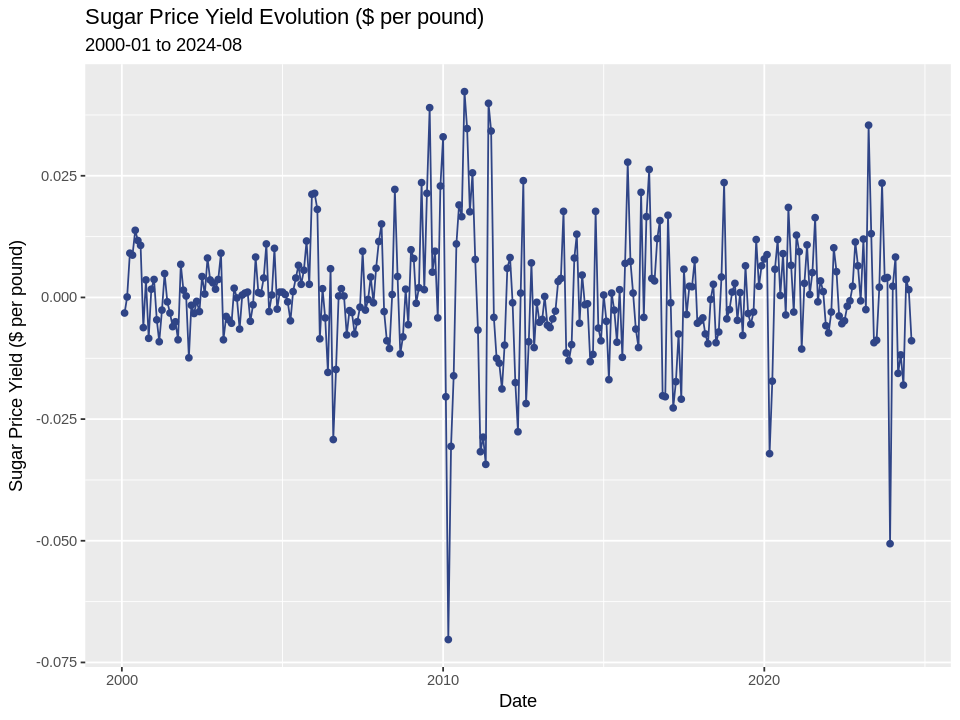

In [21]:
# Création d'un DataFrame avec la date et les variations du prix du sucre
df_sugar_price_diff <- data.frame(date = df_sugar_price$date[-1], sugar_price_yield = diff(df_sugar_price$sugar_price))

# Ajustement de la taille du graphique
options(repr.plot.width = 8, repr.plot.height = 6)

# Création du graphique avec ggplot2
p_sugar_diff <- ggplot(data=df_sugar_price_diff, aes(x=date, y=sugar_price_yield)) +
  geom_point(color='#2F4486') +
  geom_line(color='#2F4486') +
  xlab('Date') +
  ylab("Sugar Price Yield ($ per pound)") +
  labs(title=paste("Sugar Price Yield Evolution ($ per pound)"),
        subtitle="2000-01 to 2024-08")

# Affichage du graphique
p_sugar_diff

Visuellement, la série différenciée semble présenter une plus grande stabilité que la série initiale. Les fluctuations sont moins importantes et il n'y a pas de tendance apparente à la hausse ou à la baisse. Cependant, il est difficile de conclure de la stationnarité de la stationnarité.

Pour affirmer que la série est stationnaire, il est nécessaire de réaliser des tests ADF et KPSS.

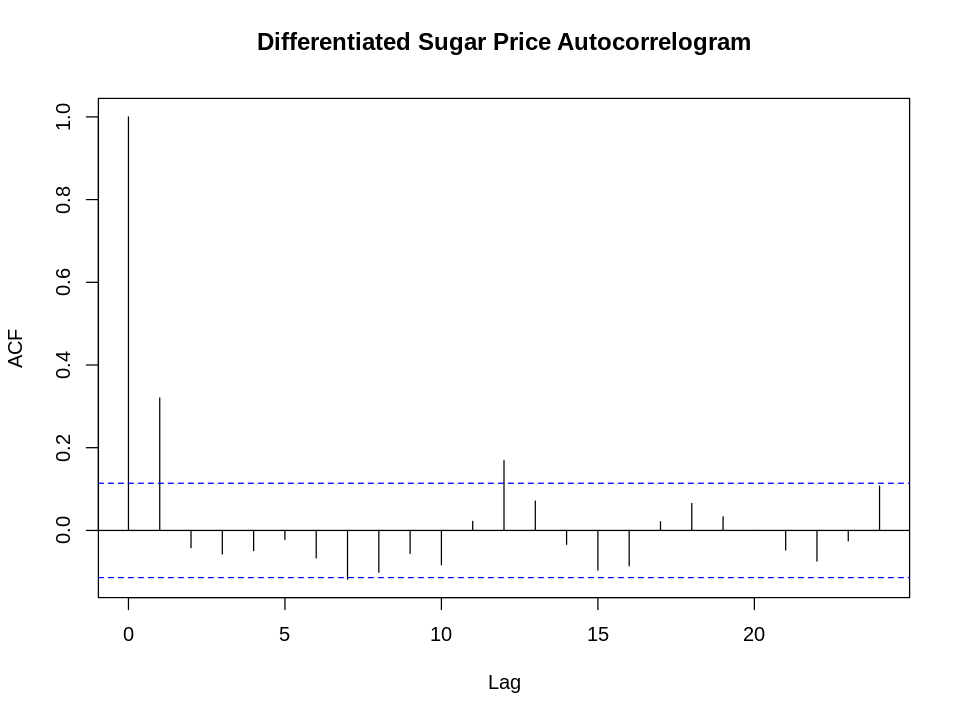

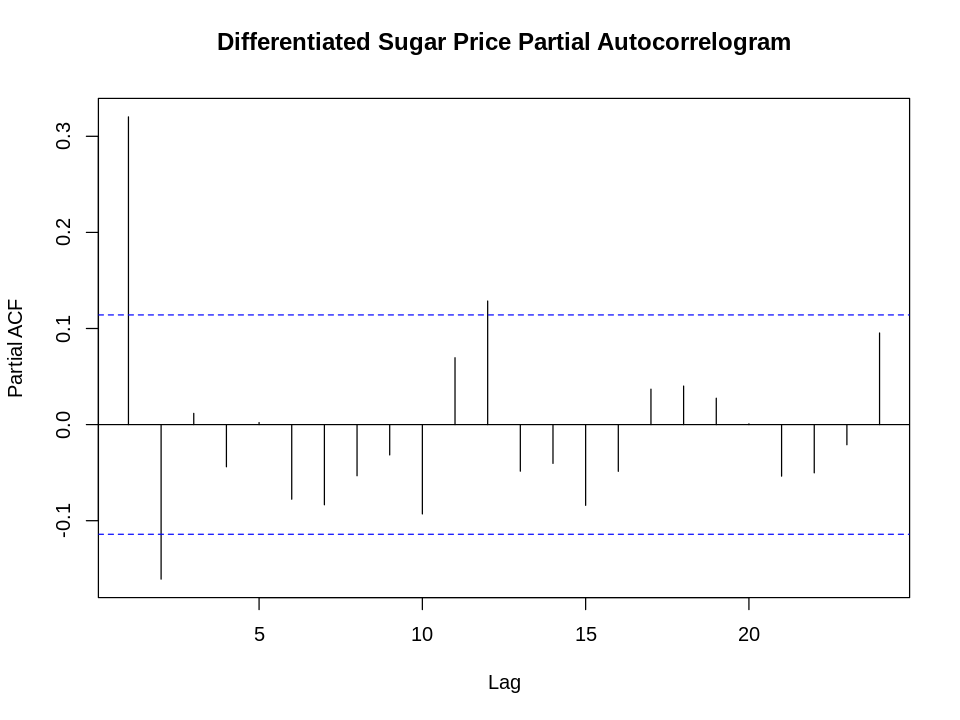

In [22]:
# Ajustement de la taille du graphique
options(repr.plot.width = 8, repr.plot.height = 6)

# Création des graphiques ACF et PACF
acf(df_sugar_price_diff$sugar_price_yield, main = 'Differentiated Sugar Price Autocorrelogram')
pacf(df_sugar_price_diff$sugar_price_yield, main = 'Differentiated Sugar Price Partial Autocorrelogram')

Le graphique de l'ACF montre une décroissance rapide vers zéro des autocorrélations. Cela suggère que la différenciation a été efficace pour éliminer une grande partie de l'autocorrélation et que la série différenciée est probablement stationnaire.

Le PACF présente des pics significatifs aux premier et deuxième lags.

Au vu de l'ACF et du PACF, la série pourrait être modélisée par un modèle ARMA(2,1)

##### ***Test de Dickey-Fuller augmenté***

$$
\text{Hypothèses : } \left\{
\begin{array}{ll}
H_0: & \rho = 0 →x_t & \text{non stationnaire} \\
H_1: & \rho < 0 → x_t & \text{stationnaire}
\end{array}
\right. \\
\\
\text{Statistique de test : } \quad t_{\hat{\rho}}=\frac{\hat{\rho}}{\hat{\sigma}}_{\hat{\rho}} = \frac{\hat{\phi}_1 - 1}{\hat{\sigma}_{\hat{\phi}_1}}
$$

###### Test ADF avec constante et tendance déterministe

In [23]:
adf_sugar_diff <- ur.df(y = df_sugar_price_diff$sugar_price_yield, type = c("trend"), lag = 8, selectlags = c('AIC'))
summary(adf_sugar_diff)


############################################### 
# Augmented Dickey-Fuller Test Unit Root Test # 
############################################### 

Test regression trend 


Call:
lm(formula = z.diff ~ z.lag.1 + 1 + tt + z.diff.lag)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.057541 -0.006313 -0.000793  0.006506  0.047622 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept)  3.247e-04  1.526e-03   0.213  0.83166    
z.lag.1     -7.954e-01  6.868e-02 -11.582  < 2e-16 ***
tt          -7.579e-07  8.844e-06  -0.086  0.93177    
z.diff.lag   1.651e-01  5.875e-02   2.811  0.00529 ** 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.01235 on 282 degrees of freedom
Multiple R-squared:  0.3589,	Adjusted R-squared:  0.3521 
F-statistic: 52.62 on 3 and 282 DF,  p-value: < 2.2e-16


Value of test-statistic is: -11.5818 44.7146 67.0705 

Critical values for test statistics: 
      1pct  5pct 10pct
tau3

La statistique du test ADF est égale à  $t_{ADF}=-11.5818$ . Les seuils de rejet figurent sur la ligne `tau3`.

La statistique de test  $t_{ADF}$  est inférieure aux seuils 1%, 5% et 10%. On rejette l'hypothèse nulle de racine unitaire.

On procède à un test de significativité du coefficient de la tendance.
$$
\begin{align*}
\text{Hypothèses : }& \left\{
\begin{array}{ll}
H_0: & b = 0 \\
H_1: & b \neq 0
\end{array}
\right. \\
\text{Statistique de test : }& \quad t_{\hat{b}}=\frac{\hat{b}}{\hat{\sigma}}_{\hat{b}}
\\
\text{Règle de décision : }& \quad |t_b|=0.086 < 1,96
\end{align*}
$$

On ne rejette pas l'hypothèse nulle de non significativité de la tendance déterministe. On procède à un test ADF avec constante.

###### Test ADF avec constante

In [24]:
adf_sugar_diff <- ur.df(y = df_sugar_price_diff$sugar_price_yield, type = c("drift"), lag = 8, selectlags = c('AIC'))
summary(adf_sugar_diff)


############################################### 
# Augmented Dickey-Fuller Test Unit Root Test # 
############################################### 

Test regression drift 


Call:
lm(formula = z.diff ~ z.lag.1 + 1 + z.diff.lag)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.057517 -0.006314 -0.000743  0.006421  0.047634 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept)  0.0002099  0.0007292   0.288  0.77369    
z.lag.1     -0.7953674  0.0685545 -11.602  < 2e-16 ***
z.diff.lag   0.1651339  0.0586461   2.816  0.00521 ** 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.01233 on 283 degrees of freedom
Multiple R-squared:  0.3589,	Adjusted R-squared:  0.3544 
F-statistic: 79.21 on 2 and 283 DF,  p-value: < 2.2e-16


Value of test-statistic is: -11.602 67.3042 

Critical values for test statistics: 
      1pct  5pct 10pct
tau2 -3.44 -2.87 -2.57
phi1  6.47  4.61  3.79


La statistique du test ADF est égale à  $t_{ADF}=-11.602$. Les seuils de rejet figurent sur la ligne `tau2`.

La statistique de test  $t_{ADF}$  est inférieure aux seuils 1%, 5% et 10%. On rejette l'hypothèse nulle de racine unitaire.

On procède à un test de significativité de la constante.
$$
\begin{align*}
\text{Hypothèses : }& \left\{
\begin{array}{ll}
H_0: & c = 0 \\
H_1: & c \neq 0
\end{array}
\right. \\
\text{Statistique de test : }& \quad t_{\hat{c}}=\frac{\hat{c}}{\hat{\sigma}}_{\hat{c}}
\\
\text{Règle de décision : }& \quad |t_b|=0.288 < 1,96
\end{align*}
$$

On ne rejette pas l'hypothèse nulle de non significativité de la constante. On procède à un test ADF sans constante ni tendance déterministe.

###### Test ADF sans constante ni tendance déterministe

In [25]:
adf_sugar_diff <- ur.df(y = df_sugar_price_diff$sugar_price_yield, type = c("none"), lag = 8, selectlags = c('AIC'))
summary(adf_sugar_diff)


############################################### 
# Augmented Dickey-Fuller Test Unit Root Test # 
############################################### 

Test regression none 


Call:
lm(formula = z.diff ~ z.lag.1 - 1 + z.diff.lag)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.057310 -0.006110 -0.000541  0.006627  0.047862 

Coefficients:
           Estimate Std. Error t value Pr(>|t|)    
z.lag.1    -0.79479    0.06841 -11.617   <2e-16 ***
z.diff.lag  0.16487    0.05854   2.816   0.0052 ** 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.01231 on 284 degrees of freedom
Multiple R-squared:  0.3587,	Adjusted R-squared:  0.3542 
F-statistic: 79.43 on 2 and 284 DF,  p-value: < 2.2e-16


Value of test-statistic is: -11.6173 

Critical values for test statistics: 
      1pct  5pct 10pct
tau1 -2.58 -1.95 -1.62


La statistique du test ADF est égale à  $t_{ADF}=-11.6173$. Les seuils de rejet figurent sur la ligne `tau1`.

La statistique de test  $t_{ADF}$  est inférieure aux seuils 1%, 5% et 10%. On rejette l'hypothèse nulle de racine unitaire.

###### ***Conclusion sur les tests ADF***
Les tests ADF montrent que notre série est DS sans constante ni tendance déterministe.

Réalisons des tests KPSS pour confirmer les résultats des tests.

##### ***Test de stationnarité de Kwiatkowski-Phillips-Schmidt-Shin***

$$
\text{Hypothèses : } \left\{
\begin{array}{ll}
H_0: & \sigma_{\varepsilon} = 0 →x_t & \text{stationnaire} \\
H_1: & \sigma_{\varepsilon} > 0 → x_t & \text{non stationnaire}
\end{array}
\right. \\
\\
\text{Statistique de test : } \quad LM_{stat}=\frac{1}{s²} \frac{\Sigma^{T}_t S^2_t}{T}
$$

###### Test de stationnarité autour d'une tendance déterministe

In [26]:
kpss_sugar_diff <- ur.kpss(y = df_sugar_price_diff$sugar_price_yield, type = "tau", lags = "long")
summary(kpss_sugar_diff)


####################### 
# KPSS Unit Root Test # 
####################### 

Test is of type: tau with 15 lags. 

Value of test-statistic is: 0.0442 

Critical value for a significance level of: 
                10pct  5pct 2.5pct  1pct
critical values 0.119 0.146  0.176 0.216


La statistique de test est égale à $LM_{KPSS} = 0.0442$.

La statistique de test est inférieure aux seuils 10%, 5% et 1%.
On ne rejette pas l'hypothèse de stationnarité autour d'une tendance déterministe.

###### Test de stationnarité autour d'une constante

In [27]:
kpss_sugar_diff <- ur.kpss(y = df_sugar_price_diff$sugar_price_yield, type = "mu", lags = "long")
summary(kpss_sugar_diff)


####################### 
# KPSS Unit Root Test # 
####################### 

Test is of type: mu with 15 lags. 

Value of test-statistic is: 0.0651 

Critical value for a significance level of: 
                10pct  5pct 2.5pct  1pct
critical values 0.347 0.463  0.574 0.739


La statistique de test est égale à $LM_{KPSS} = 0.0651 $.

La statistique de test est inférieure aux seuils 10%, 5% et 1%.
On ne rejette pas l'hypothèse de stationnarité autour d'une constante.

###### Conclusion sur les tests KPSS

Les tests KPSS montrent que notre série est DS.

##### ***Conclusion sur les test de racine unitaire et de stationnarité***

Les tests ADF et KPSS montrent que notre série est DS sans constante ni tendance déterministe.

#### 2.2.2 &emsp; Les variations du prix du pétrole
Afin de stationnariser la série des prix du pétrole, on applique une différenciation d'ordre 1 sur la série.

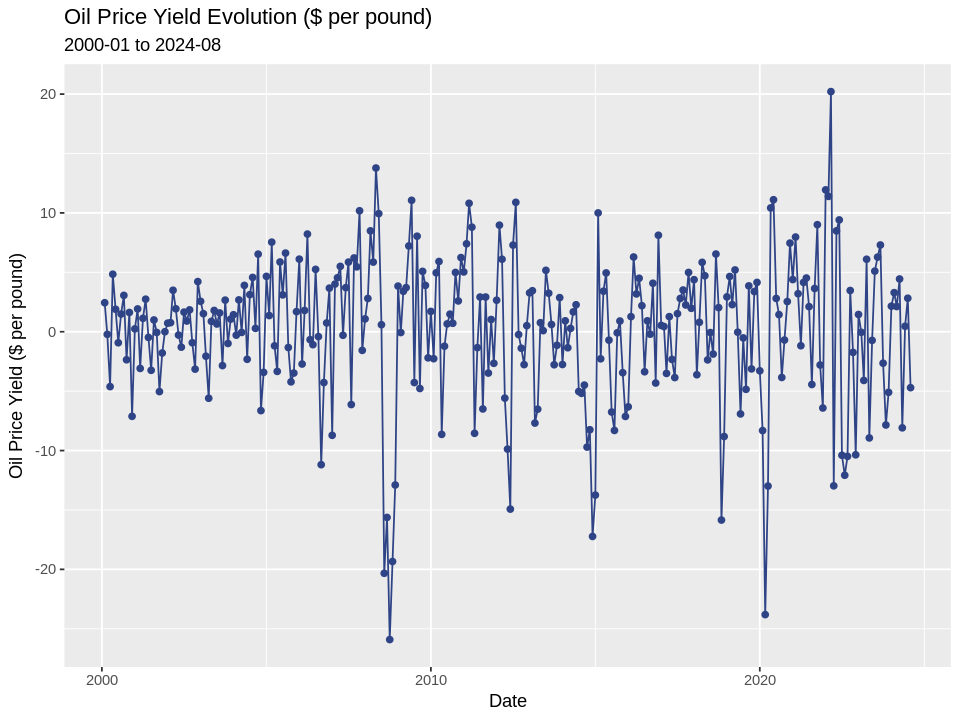

In [28]:
# Création d'un DataFrame avec la date et les variations du prix du sucre
df_oil_price_diff <- data.frame(date = df_oil_price$date[-1], oil_price_yield = diff(df_oil_price$oil_price))

# Ajustement de la taille du graphique
options(repr.plot.width = 8, repr.plot.height = 6)

# Création du graphique avec ggplot2
p_oil_diff <- ggplot(data=df_oil_price_diff, aes(x=date, y=oil_price_yield)) +
  geom_point(color='#2F4486') +
  geom_line(color='#2F4486') +
  xlab('Date') +
  ylab("Oil Price Yield ($ per pound)") +
  labs(title=paste("Oil Price Yield Evolution ($ per pound)"),
        subtitle="2000-01 to 2024-08")

# Affichage du graphique
p_oil_diff

Visuellement, à l'instar de la série différenciée du prix du sucre, la différenciation du prix du pétrole a amené une plus grande stabilité que la série initiale. Les fluctuations sont moins importantes et il n'y a pas de tendance apparente à la hausse ou à la baisse.

Toutefois, pour affirmer que la série est stationnaire, il est nécessaire de réaliser des tests ADF et KPSS.

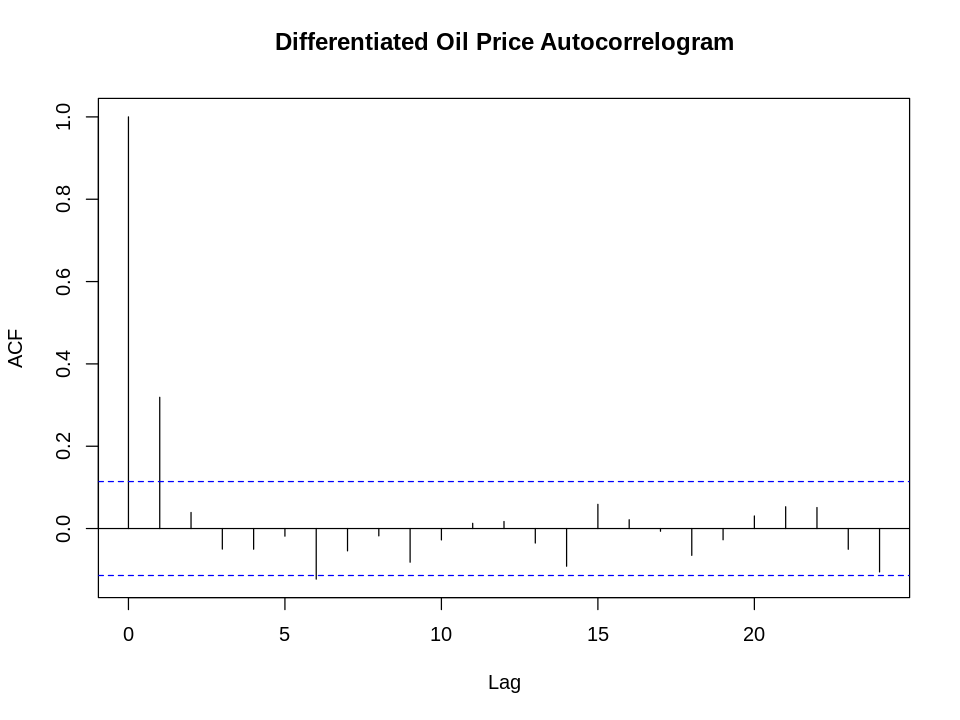

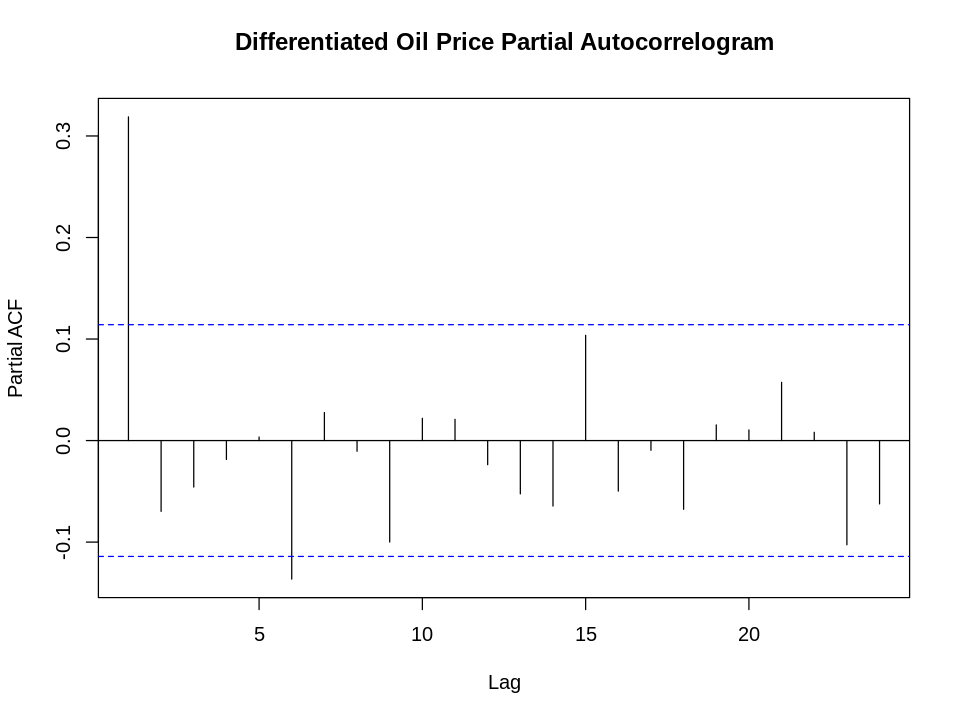

In [29]:
# Ajustement de la taille du graphique
options(repr.plot.width = 8, repr.plot.height = 6)

# Création des graphiques ACF et PACF
acf(df_oil_price_diff$oil_price_yield, main = 'Differentiated Oil Price Autocorrelogram')
pacf(df_oil_price_diff$oil_price_yield, main = 'Differentiated Oil Price Partial Autocorrelogram')

La différenciation semble avoir été efficace pour éliminer une grande partie de l'autocorrélation et que la série différenciée est probablement stationnaire.
En effet, le graphique de l'ACF montre une décroissance rapide vers zéro des autocorrélations.

Le PACF montre que le lag 1 est significatif.

Au vu de l'ACF et du PACF, la série pourrait être modélisée par un modèle ARMA(1,1)

##### ***Test de Dickey-Fuller augmenté***
$$
\text{Hypothèses : } \left\{
\begin{array}{ll}
H_0: & \rho = 0 →x_t & \text{non stationnaire} \\
H_1: & \rho < 0 → x_t & \text{stationnaire}
\end{array}
\right. \\
\\
\text{Statistique de test : } \quad t_{\hat{\rho}}=\frac{\hat{\rho}}{\hat{\sigma}}_{\hat{\rho}} = \frac{\hat{\phi}_1 - 1}{\hat{\sigma}_{\hat{\phi}_1}}
$$

###### Test ADF avec constante et tendance déterministe

In [30]:
adf_oil_diff <- ur.df(y = df_oil_price_diff$oil_price_yield, type = c("trend"), lag = 8, selectlags = c('AIC'))
summary(adf_oil_diff)


############################################### 
# Augmented Dickey-Fuller Test Unit Root Test # 
############################################### 

Test regression trend 


Call:
lm(formula = z.diff ~ z.lag.1 + 1 + tt + z.diff.lag)

Residuals:
     Min       1Q   Median       3Q      Max 
-22.1291  -3.6143   0.8389   3.5280  17.1570 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept)  0.347988   0.725443   0.480    0.632    
z.lag.1     -0.724592   0.069163 -10.477   <2e-16 ***
tt          -0.001484   0.004203  -0.353    0.724    
z.diff.lag   0.070238   0.059460   1.181    0.238    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 5.866 on 282 degrees of freedom
Multiple R-squared:  0.3415,	Adjusted R-squared:  0.3345 
F-statistic: 48.75 on 3 and 282 DF,  p-value: < 2.2e-16


Value of test-statistic is: -10.4767 36.5904 54.8853 

Critical values for test statistics: 
      1pct  5pct 10pct
tau3 -3.98 -3.42 -3.1

La statistique du test ADF est égale à  $t_{ADF}=-10.477$. Les seuils de rejet figurent sur la ligne `tau3`.

La statistique de test  $t_{ADF}$  est inférieure aux seuils 1%, 5% et 10%. On rejette l'hypothèse nulle de racine unitaire.

On procède à un test de significativité du coefficient de la tendance.
$$
\text{Hypothèses : } \left\{
\begin{array}{ll}
H_0: & b = 0 \\
H_1: & b \neq 0
\end{array}
\right. \\
\\
\text{Statistique de test : } \quad t_{\hat{b}}=\frac{\hat{b}}{\hat{\sigma}}_{\hat{b}}
\\
\text{Règle de décision : }\quad |t_b|=0.480 < 1,96
$$

On ne rejette pas l'hypothèse nulle de non significativité de la tendance déterministe. On procède à un test ADF avec constante.

###### Test ADF avec constante

In [31]:
adf_oil_diff <- ur.df(y = df_oil_price_diff$oil_price_yield, type = c("drift"), lag = 8, selectlags = c('AIC'))
summary(adf_oil_diff)


############################################### 
# Augmented Dickey-Fuller Test Unit Root Test # 
############################################### 

Test regression drift 


Call:
lm(formula = z.diff ~ z.lag.1 + 1 + z.diff.lag)

Residuals:
     Min       1Q   Median       3Q      Max 
-22.0476  -3.5017   0.8388   3.5568  16.9818 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  0.12305    0.34657   0.355    0.723    
z.lag.1     -0.72401    0.06904 -10.487   <2e-16 ***
z.diff.lag   0.06987    0.05936   1.177    0.240    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 5.857 on 283 degrees of freedom
Multiple R-squared:  0.3412,	Adjusted R-squared:  0.3365 
F-statistic: 73.29 on 2 and 283 DF,  p-value: < 2.2e-16


Value of test-statistic is: -10.4874 54.9934 

Critical values for test statistics: 
      1pct  5pct 10pct
tau2 -3.44 -2.87 -2.57
phi1  6.47  4.61  3.79


La statistique du test ADF est égale à  $t_{ADF}=-10.487$. Les seuils de rejet figurent sur la ligne `tau2`.

La statistique de test  $t_{ADF}$  est inférieure aux seuils 1%, 5% et 10%. On rejette l'hypothèse nulle de racine unitaire.

On procède à un test de significativité du coefficient de la constante.
$$
\text{Hypothèses : } \left\{
\begin{array}{ll}
H_0: & c = 0 \\
H_1: & c \neq 0
\end{array}
\right. \\
\\
\text{Statistique de test : } \quad t_{\hat{c}}=\frac{\hat{c}}{\hat{\sigma}}_{\hat{c}}
\\
\text{Règle de décision : }\quad |t_b|=0.355 < 1,96
$$

On ne rejette pas l'hypothèse nulle de non significativité de la constante. On procède à un test ADF sans constante ni tendance déterministe.

###### Test ADF sans constante ni tendance déterministe

In [32]:
adf_oil_diff <- ur.df(y = df_oil_price_diff$oil_price_yield, type = c("none"), lag = 8, selectlags = c('AIC'))
summary(adf_oil_diff)


############################################### 
# Augmented Dickey-Fuller Test Unit Root Test # 
############################################### 

Test regression none 


Call:
lm(formula = z.diff ~ z.lag.1 - 1 + z.diff.lag)

Residuals:
     Min       1Q   Median       3Q      Max 
-21.9086  -3.3823   0.9603   3.6788  17.0945 

Coefficients:
           Estimate Std. Error t value Pr(>|t|)    
z.lag.1    -0.72312    0.06888 -10.498   <2e-16 ***
z.diff.lag  0.06942    0.05925   1.172    0.242    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 5.848 on 284 degrees of freedom
Multiple R-squared:  0.3409,	Adjusted R-squared:  0.3363 
F-statistic: 73.45 on 2 and 284 DF,  p-value: < 2.2e-16


Value of test-statistic is: -10.4976 

Critical values for test statistics: 
      1pct  5pct 10pct
tau1 -2.58 -1.95 -1.62


La statistique du test ADF est égale à  $t_{ADF}=-10.4976$. Les seuils de rejet figurent sur la ligne `tau1`.

La statistique de test  $t_{ADF}$  est inférieure aux seuils 1%, 5% et 10%. On rejette l'hypothèse nulle de racine unitaire.

###### ***Conclusion sur les tests ADF***
Les tests ADF montrent que notre série est DS sans constante ni tendance déterministe.

Réalisons des tests KPSS pour confirmer les résultats des tests.

##### ***Test de stationnarité de Kwiatkowski-Phillips-Schmidt-Shin***

$$
\text{Hypothèses : } \left\{
\begin{array}{ll}
H_0: & \sigma_{\varepsilon} = 0 →x_t & \text{stationnaire} \\
H_1: & \sigma_{\varepsilon} > 0 → x_t & \text{non stationnaire}
\end{array}
\right. \\
\\
\text{Statistique de test : } \quad LM_{stat}=\frac{1}{s²} \frac{\Sigma^{T}_t S^2_t}{T}
$$

###### Test de stationnarité autour d'une tendance déterministe

In [33]:
kpss_oil_diff <- ur.kpss(y = df_oil_price_diff$oil_price_yield, type = "tau", lags = "long")
summary(kpss_oil_diff)


####################### 
# KPSS Unit Root Test # 
####################### 

Test is of type: tau with 15 lags. 

Value of test-statistic is: 0.0457 

Critical value for a significance level of: 
                10pct  5pct 2.5pct  1pct
critical values 0.119 0.146  0.176 0.216


La statistique de test est égale à $LM_{KPSS} = 0.0457$.

La statistique de test est inférieure aux seuils 10%, 5% et 1%.
On ne rejette pas l'hypothèse de stationnarité autour d'une tendance déterministe.

###### Test de stationnarité autour d'une constante

In [34]:
kpss_oil_diff <- ur.kpss(y = df_oil_price_diff$oil_price_yield, type = "mu", lags = "long")
summary(kpss_oil_diff)


####################### 
# KPSS Unit Root Test # 
####################### 

Test is of type: mu with 15 lags. 

Value of test-statistic is: 0.0698 

Critical value for a significance level of: 
                10pct  5pct 2.5pct  1pct
critical values 0.347 0.463  0.574 0.739


La statistique de test est égale à $LM_{KPSS} = 0.0698$.

La statistique de test est inférieure aux seuils 10%, 5% et 1%.
On ne rejette pas l'hypothèse de stationnarité autour d'une constante.

###### ***Conclusion sur les tests KPSS***
Les tests KPSS montrent que notre série est DS.

##### ***Conclusion sur les test de racine unitaire et de stationnarité***

Les tests ADF et KPSS montrent que notre série est DS.

### 2.3 &emsp; Estimation d'un modèle ARIMA

Après avoir appliqué les transformations nécessaires pour rendre les séries stationnaires, nous pouvons désormais modéliser le prix du sucre à l'aide d'un modèle ARIMA. Dans cette section, nous procéderons à l'estimation du modèle ARIMA, en déterminant les paramètres optimaux, et en évaluant la qualité de l'ajustement à l'aide des critères d'information, des résidus du modèle et des prévisions générées.

Nous allons écarter les 3 dernières observations de l'échantillon (de juin 2024 à août 2024), afin de comparer les valeurs prédites par le modèle final aux valeurs réelles et ainsi évaluer les performances du modèle.

#### 2.3.1 &emsp;Estimation d'un modèle à l'aide des ACF et PACF

Au vu de l'ACF et du PACF, la série des rendements du prix du sucre pourrait être modélisée par un modèle ARMA(1,2)

In [35]:
# Estimation d'un modèle ARIMA(2,1)
ARIMA21 <- Arima(y = df_sugar_price_diff$sugar_price_yield[1:292], order = c(2, 0, 1))

# Affichage de l'estimation
summary(ARIMA21)

# Test de siginificativité des coefficients
coeftest(ARIMA21)

Series: df_sugar_price_diff$sugar_price_yield[1:292] 
ARIMA(2,0,1) with non-zero mean 

Coefficients:
         ar1      ar2     ma1   mean
      0.2445  -0.1171  0.1336  4e-04
s.e.  0.5473   0.1953  0.5556  9e-04

sigma^2 = 0.0001504:  log likelihood = 872.69
AIC=-1735.38   AICc=-1735.17   BIC=-1717

Training set error measures:
                       ME       RMSE        MAE      MPE     MAPE      MASE
Training set 3.118558e-06 0.01218087 0.00866373 111.3327 146.3055 0.8131677
                     ACF1
Training set 0.0005280548


z test of coefficients:

             Estimate  Std. Error z value Pr(>|z|)
ar1        0.24449383  0.54733202  0.4467   0.6551
ar2       -0.11714345  0.19533944 -0.5997   0.5487
ma1        0.13361327  0.55561775  0.2405   0.8100
intercept  0.00043661  0.00092759  0.4707   0.6379


##### ***Analyse des racines***
On représente les inverses des racines dans le cercle unitaire. La condition de stationnarité impose que ces inverses doivent être de module strictement inférieur à 1, c'est-à-dire dans le cercle unitaire.

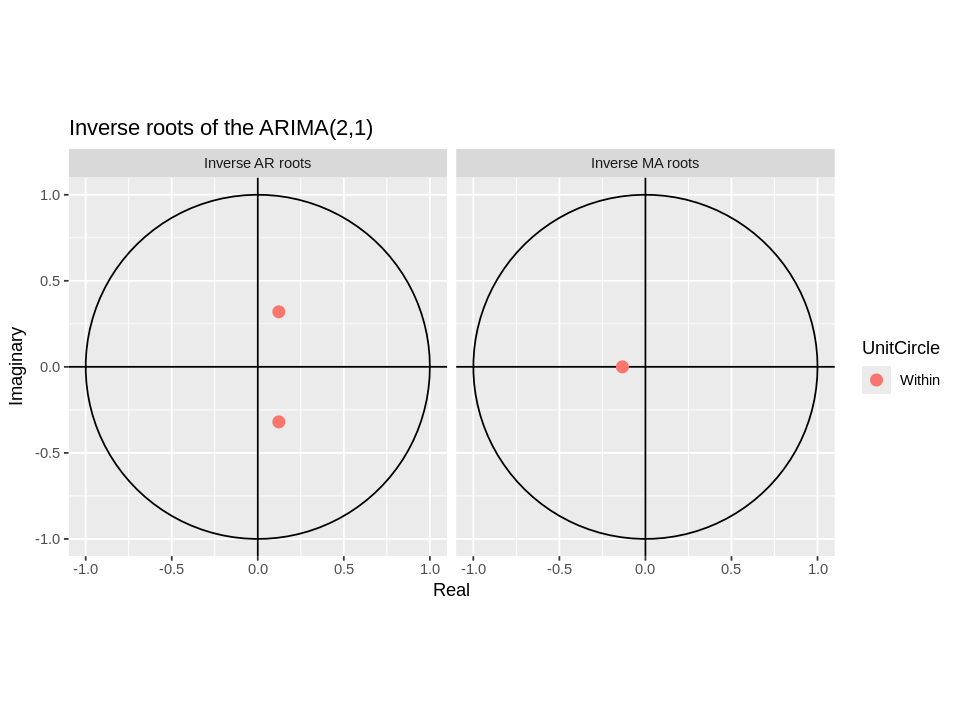

In [36]:
# Ajustement de la taille du graphique
options(repr.plot.width = 8, repr.plot.height = 6)

# Visualisation des racines dans le cercle unitaire
autoplot(ARIMA21,main="Inverse roots of the ARIMA(2,1)")

 La condition de stationnarité est donc satisfaite.

##### ***Test de significativité des coefficients***
On vérifie la significativité de la constante et des coefficients de l'ARIMA.

In [37]:
coeftest(ARIMA21)


z test of coefficients:

             Estimate  Std. Error z value Pr(>|z|)
ar1        0.24449383  0.54733202  0.4467   0.6551
ar2       -0.11714345  0.19533944 -0.5997   0.5487
ma1        0.13361327  0.55561775  0.2405   0.8100
intercept  0.00043661  0.00092759  0.4707   0.6379


###### *Test de significativité de la constante*
$$
\begin{align*}
\text{Hypothèses : }& \left\{
\begin{array}{ll}
H_0: & c = 0 \\
H_1: & c \neq 0
\end{array}
\right. \\
\text{Statistique de test : }& \quad t_{\hat{c}}=\frac{\hat{c}}{\hat{\sigma}}_{\hat{c}}
\\
\text{Règle de décision : }& \quad |t_c|=0.4707 < 1,96
\end{align*}
$$

La constante n'est pas significative au seuil 5%.

###### *Test de significativité des coefficients*
$$
\begin{align*}
\text{Hypothèses : }& \left\{
\begin{array}{ll}
H_0: & \phi_i = 0 \\
H_1: & \phi_i \neq 0
\end{array}
\right. \\
\\
\text{Statistique de test : }& \quad t_{\hat{\phi_i}}=\frac{\hat{\phi_i}}{\hat{\sigma}}_{\hat{\phi_i}}
\\
\text{Règle de décision : }&
\begin{array}{ll}
\quad |t_{\phi_1}|=0.4467 < 1,96 \\
\quad |t_{\phi_2}|=0.5997 < 1,96 \\
\quad |t_{\theta_1}|=0.2405 < 1,96
\end{array}
\end{align*}
$$

Les coefficients ne sont pas significatifs au seuil 5%.

##### **Test sur les résidus**

###### *Test d'absence d'autocorrélation*

On teste l'absence d'autocorrélation des résidus jusqu'à l'ordre 10.
$$
\begin{align*}
\text{Hypothèses : }& \left\{
\begin{array}{ll}
H_0: & \rho(1) = \rho(2) = \cdots = \rho(10) = 0 \\
H_1: & \exists i \in \{1, \cdots, 10\} \text{ tel que } \rho(i) \neq 0
\end{array}
\right.
\\
\text{Statistique de test : }& \quad Q^*(10) ∼ \chi²(7)
\\
\text{Règle de décision : }&
\quad Q^*(10) = 7.7824 < 14.067 = Q^*(10)_{0.95}
\end{align*}
$$

$Q^*(10) = 7.7824$  est inférieure au seuil critique de 5%. On ne rejette pas l'hypothèse nulle d'absence d'autocorrélation des résidus.


	Ljung-Box test

data:  Residuals from ARIMA(2,0,1) with non-zero mean
Q* = 7.7824, df = 7, p-value = 0.3522

Model df: 3.   Total lags used: 10



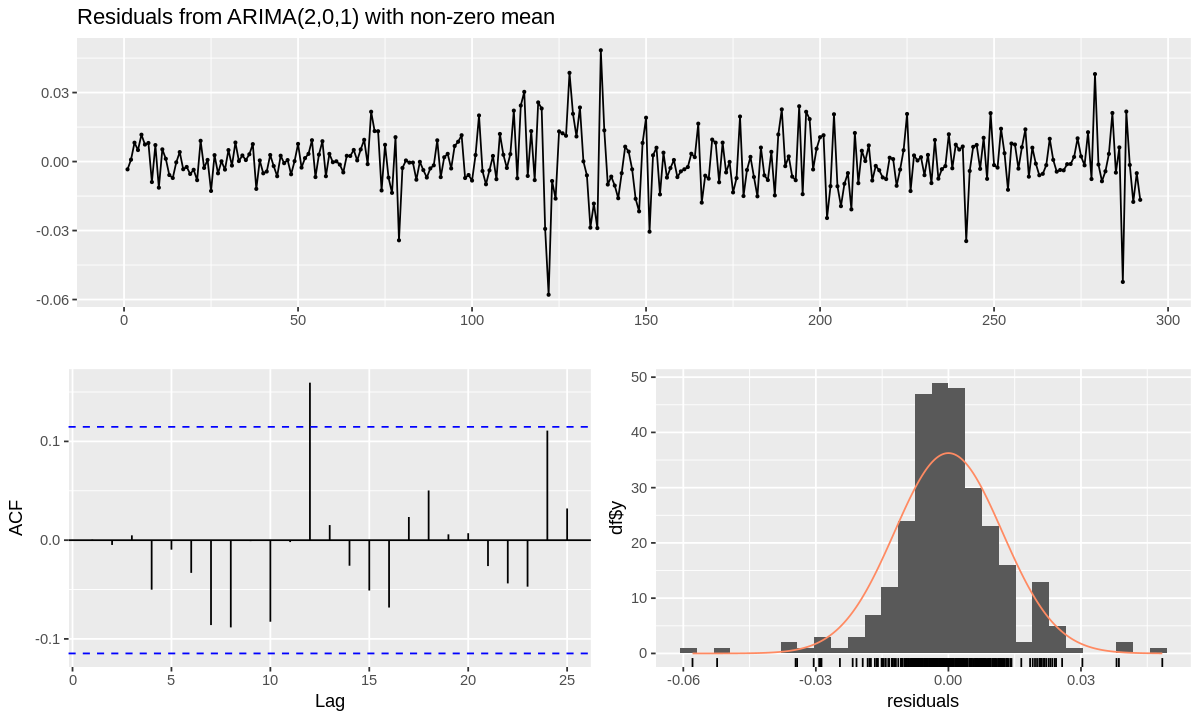

In [38]:
# Ajustement de la taille du graphique
options(repr.plot.width = 10, repr.plot.height = 6)

test_resARIMA21<-checkresiduals(ARIMA21,lag = 10)

###### *Test de l'hypothèse de normalité des résidus : Test de Jarque & Bera*
$$
\begin{align*}
\text{Hypothèses : }& \left\{
\begin{array}{ll}
H_0 : S(X) = 0 \ \text{et} \ K(X) = 3 \\
H_1 : S(X) \neq 0 \ \text{ou} \ K(X) \neq 3
\end{array}
\right.
\\
\text{Statistique de test : }& \quad JB_{stat} ∼ \chi²(2)
\end{align*}
$$

In [39]:
which(ARIMA21$residuals==min(ARIMA21$residuals))
which(ARIMA21$residuals==max(ARIMA21$residuals))

[1] 122

[1] 137

[1] "Skewness des residus : -0.481744"

[1] "kurtosis des residus : 6.382377"

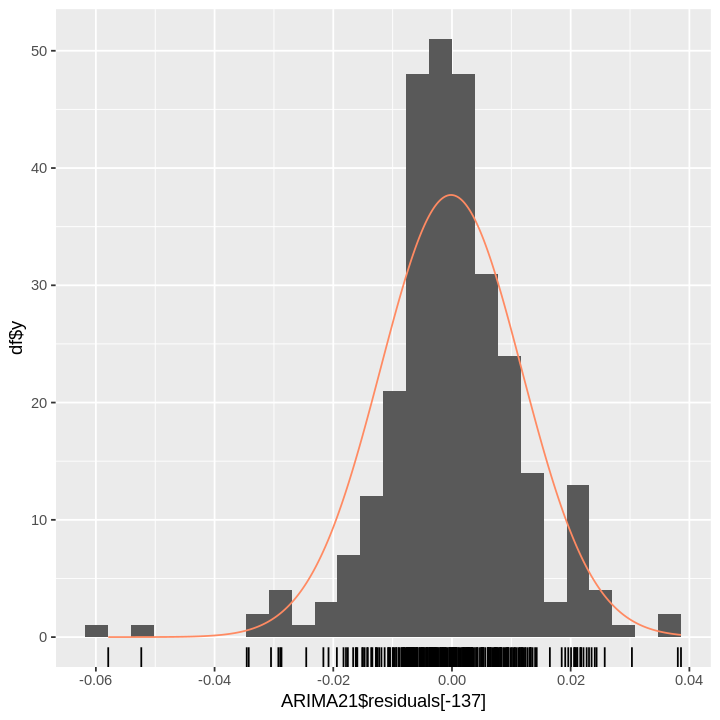

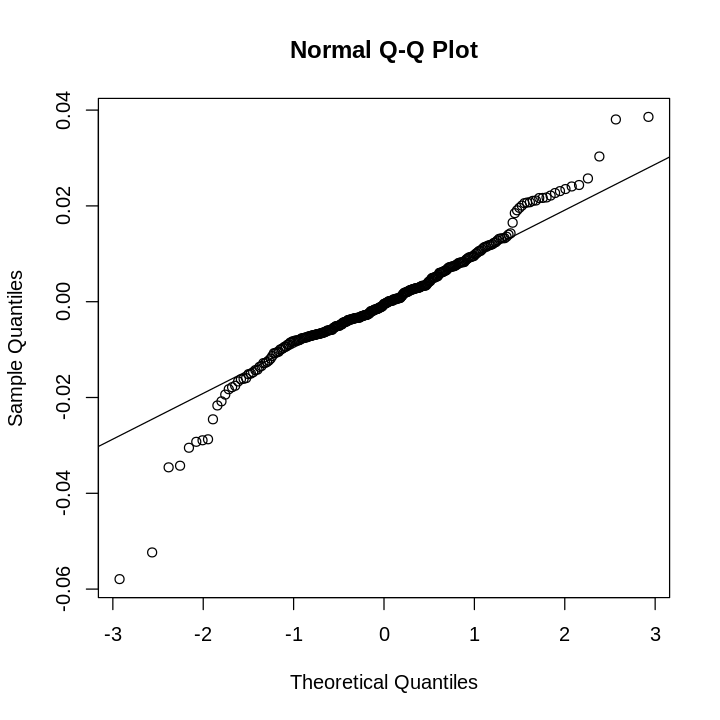

In [40]:
# Ajustement de la taille du graphique
options(repr.plot.width = 6, repr.plot.height = 6)

gghistogram(ARIMA21$residuals[-137], add.normal = TRUE)
sprintf("Skewness des residus : %f",skewness(ARIMA21$residuals[-137]))
sprintf("kurtosis des residus : %f",kurtosis(ARIMA21$residuals[-137]))
qqnorm(ARIMA21$residuals[-137])
qqline(ARIMA21$residuals[-137])

Le skewness mesure l'asymétrie d'une distribution. Ici, le skewness négatif indique que la distribution est plus étirée vers la gauche qu'une loi normale, en d'autres termes, il y a plus de valeurs extrêmes négatives.

Le kurtosis mesure l'aplatissement d'une distribution par rapport à une distribution normale. La valeur du kurtosis pour une distribution normale est de 3. Le kurtosis des résidus est de 6.382377 ce qui est bien supérieure à la valeur du kurtosis pour une distribution normale. Cela veut dire que notre distribution est plus pointue qu'une distribution normale.

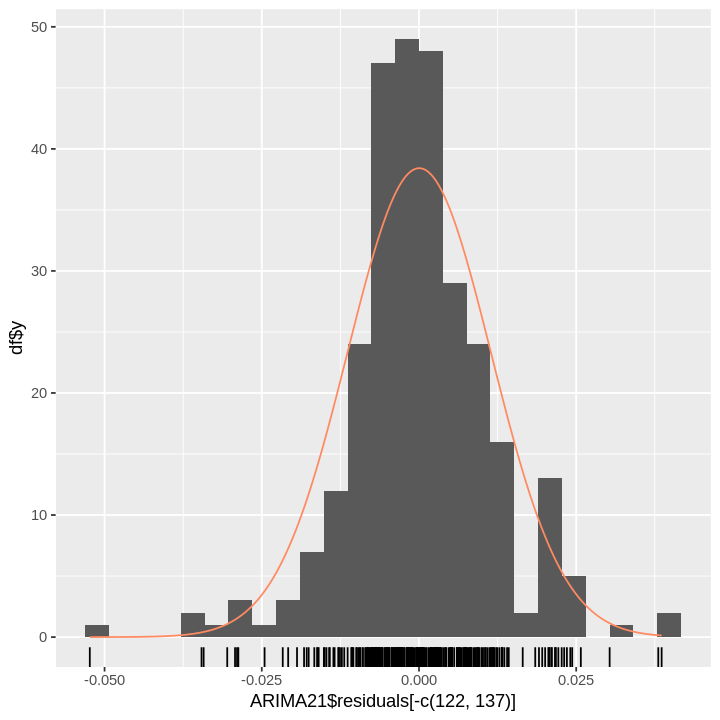

In [41]:
gghistogram(ARIMA21$residuals[-c(122,137)], add.normal = TRUE)

On constate quelques différences entre les deux histogrammes ce qui permet de supposer que les résidus ne suivent pas une loi normale. On vérifie cette hypothèse par un test de Jarque Bera.

In [42]:
jarque.bera.test(ARIMA21$residuals[-c(137)])


	Jarque Bera Test

data:  ARIMA21$residuals[-c(137)]
X-squared = 149.97, df = 2, p-value < 2.2e-16


$$
\text{Règle de décision : } \quad JB_{stat} = 149.97 >\chi^2_{0.95}(2) = 5,99
$$

La statistique du test de Jarque et Bera est supérieure au seuil critique de 5%. De ce fait, on rejette l’hypothèse nulle d’une distribution normale des résidus. La distribution des résidus ne suit pas une loi normale.

###### *Test d'absence d'effet ARCH*
On teste l'hypothèse d'absence d'effet ARCH avec quatre retards. La régression estimée est :
$$
\hat{\epsilon}_{t}^{2}= \gamma_{0} + \gamma_{1} \hat{\epsilon}_{t-1}^{2} +\gamma_{2} \hat{\epsilon}_{t-2}^{2} +\gamma_{3} \hat{\epsilon}_{t-3}^{2} +\gamma_{4} \hat{\epsilon}_{t-4}^{2} + v_{t} \\
$$

$$
\begin{align*}
\text{Hypothèses : }& \left\{
\begin{array}{ll}
H_{0} : \gamma_{1}=...=\gamma_{4}=0 \rightarrow \text{pas d'effet ARCH}\\
H_{a} : \gamma_{1}\neq 0 \space \text{ou} \,... \gamma_{4} \neq 0 \rightarrow \text{effet ARCH}
\end{array}
\right.
\\
\text{Statistique de test : }& \quad ARCH_{LM} ∼ \chi²(2)
\end{align*}
$$

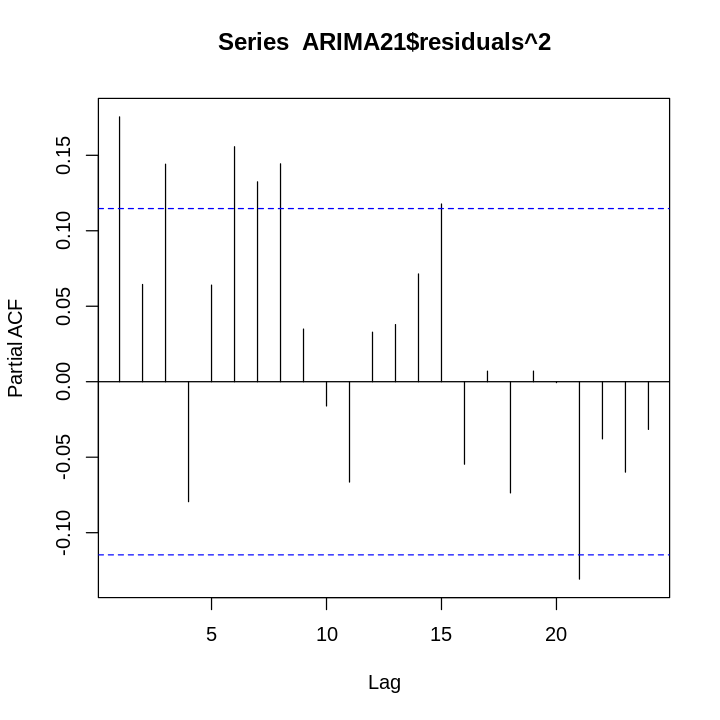

In [43]:
pacf(ARIMA21$residuals^2)

In [44]:
ArchTest(ARIMA21$residuals,lags=4,demean = FALSE)


	ARCH LM-test; Null hypothesis: no ARCH effects

data:  ARIMA21$residuals
Chi-squared = 17.427, df = 4, p-value = 0.001596


$$
\text{Règle de décision : }
\quad ARCH_{LM} = 17.427 > 9,488 = \chi²^*(4)_{0.95}
$$

La statistique de test est supérieure au seuils critique de 5%. On ne rejette pas l'hypothèse nulle d'absence d'effet ARCH pour les résidus : il y a une  hétéroscédasticité conditionnelle dans les résidus.

Cela indique que la variance des résidus n'est pas constante, mais dépend des valeurs passées des résidus au carré.

##### **Prévision**
$$
\begin{align*}
&\text{A t+1 : } \quad \hat{Y}_{t+1} = c + \phi _1Y_{t} + \phi _2Y_{t-1} + \theta _1 \varepsilon _t \\
&\text{A t+2 : } \quad \hat{Y}_{t+2} = c + \phi _1\hat{Y}_{t+1} + \phi _2Y_{t} + 0 \\
&\text{A t+3 : } \quad \hat{Y}_{t+3} = c + \phi _1\hat{Y}_{t+2} + \phi _2\hat{Y}_{t+1} + 0 \\
\end{align*}
$$

In [45]:
df_sugar_price_diff$sugar_price_yield[291:292]

[1] -0.0118 -0.0180

In [46]:
resid(ARIMA21)[292]

[1] -0.01664859

**Calcul de la prévision pour Juin 2024 (h=1)**

$$
\begin{aligned}
\hat{Y}_{t+1} &= 0.0004 + 0.2445 \times (-0.0180) -0.1171\times (-0.0118) + 0.0166 \times (-0.0166)= -0.0048
\end{aligned}
$$

**Calcul de la prévision pour Juillet 2024 (h=2)**

$$
\begin{aligned}
\hat{Y}_{t+2} &= 0.0004 + 0.2445 \times (-0.0048) -0.1171\times (-0.0180) = 0.0013
\end{aligned}
$$

**Calcul de la prévision pour Août 2024 (h=3)**

$$
\begin{aligned}
\hat{Y}_{t+3} &= 0.0004 + 0.2445 \times 0.0013 -0.1171\times (-0.0048) = 0.0012
\end{aligned}
$$

In [47]:
# Calcul des prévisions
forecast_ARIMA21<-forecast(ARIMA21,h=3,level=95)
forecast_ARIMA21

    Point Forecast       Lo 95      Hi 95
293   -0.004862061 -0.02890135 0.01917723
294    0.001300845 -0.02439945 0.02700114
295    0.001268615 -0.02443853 0.02697576

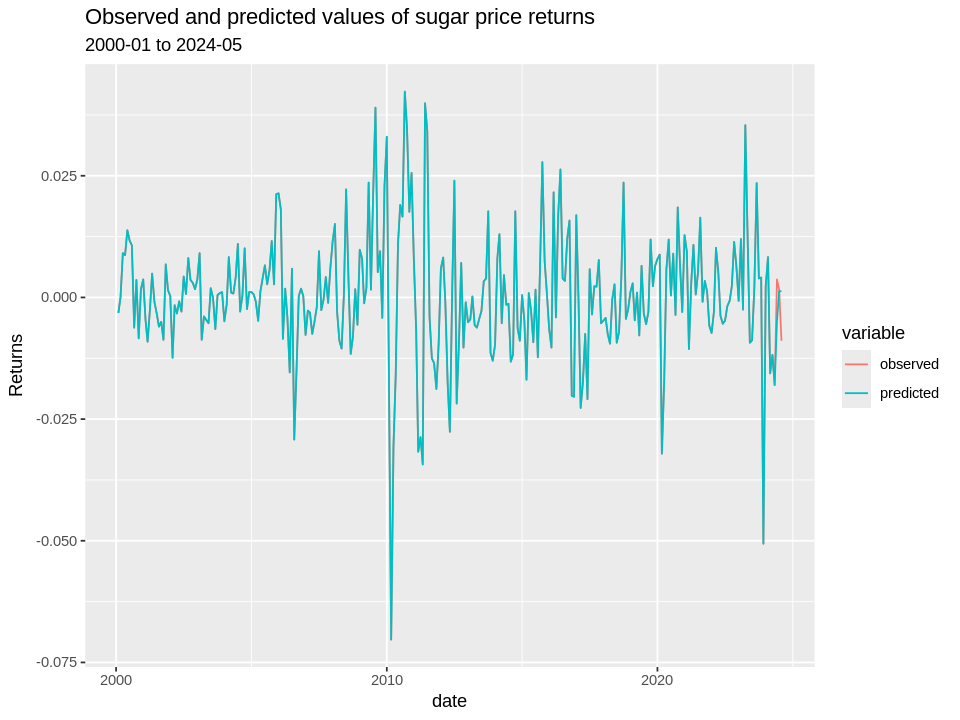

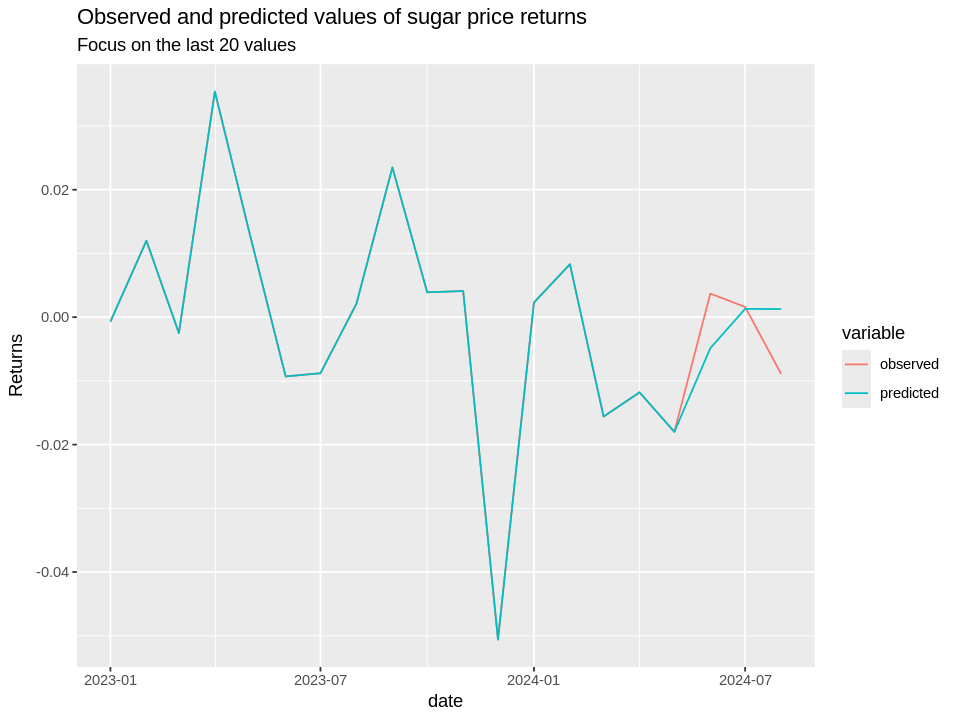

In [48]:
# Ajustement de la taille du graphique
options(repr.plot.width = 8, repr.plot.height = 6)

### Graphique principal
# Fusionner les données (date, rendement observé) avec les prévisions du modèle ARIMA
df_forecast <- cbind.data.frame(df_sugar_price_diff$date,df_sugar_price_diff$sugar_price_yield,c(df_sugar_price_diff$sugar_price_yield[1:292],as.matrix(forecast_ARIMA21$mean)))

# Attribuer des noms de colonnes au dataframe fusionné
colnames(df_forecast)<-c("date","observed","predicted")

# Préparation des données pour ggplot
data_F_melt=melt(as.data.frame(df_forecast),id.vars = 1)

# Ajouter des labels au graphique
p_forecast <-ggplot(data=data_F_melt,aes(x=date))+geom_line(aes(x=date,y=value,color= variable))
p_forecast+labs(y="Returns",title = "Observed and predicted values of sugar price returns",
            subtitle = "2000-01 to 2024-05")

### Graphique zoomé
# Garder uniquement les 20 dernières valeurs
df_forecast_last20 <- df_forecast [(nrow(df_forecast )-19):nrow(df_forecast ), ]

# Transformer pour ggplot
data_F_melt_last20 <- melt(as.data.frame(df_forecast_last20), id.vars = 1)

# Tracer les données zoomées
p_forecast_last20 <- ggplot(data = data_F_melt_last20, aes(x = date)) +
  geom_line(aes(y = value, color = variable)) +
  labs(
    y = "Returns",
    title = "Observed and predicted values of sugar price returns",
    subtitle = "Focus on the last 20 values"
  )

# Afficher le graphique
print(p_forecast_last20)

## 3 &emsp; Modélisation multivariée

Après avoir exploré les caractéristiques individuelles des séries temporelles, nous avons vérifié leur stationnarité et estimé un modèle ARIMA pour décrire le comportement de la variation des prix du sucre. Cependant, cette approche univariée se concentre uniquement sur l’évolution indépendante d'une série, sans considérer les interactions potentielles entre les différentes séries présentées.

Dans cette troisième partie, nous abordons à présent une modélisation multivariée qui permet d’étudier les relations dynamiques entre les variables. Après avoir estimé un modèle VAR, nous analyserons comment les séries influencent mutuellement leurs évolutions, tout en approfondissant la compréhension des liens structurels à travers l'analyse impulsion-réponse et les tests de cointégration.

### Préliminaire

On crée un DataFrame avec l'ensemble des séries stationnarisées

In [51]:
# Ajout des dates
df_stationary_data <- data.frame(Date = df$Date[-1])

# Ajout des rendements des prix du sucre
df_stationary_data[["Sugar Price Returns"]] <- diff(df$"Sugar Price ($ per pound)")

# Ajout des facteurs météorologiques
for (col in colnames(df)[c(3:5)]) {

  # Extraire le nom de la variable et l'unité à partir du nom de la colonne
  parts <- unlist(strsplit(col, " \\(")) # Séparer par espace suivi de parenthèse ouvrante
  variable_name <- parts[1] # Partie avant la parenthèse
  unit <- ifelse(length(parts) > 1, gsub("\\)", "", parts[2]), "") # Supprimer la parenthèse fermante

  # Créer un DataFrame temporaire avec la date et la colonne courante
  df_temp <- df[, c("Date", col)]
  colnames(df_temp) <- c("date", "value")

  # Ajustement d'une régression pour retirer la tendance
  model_temp <- lm(value ~ date, data = df_temp)

  # Extraction des résidus
  stationary_serie <- resid(model_temp)

  # Enregistrement de la série stationnaire dans le DataFrame final
  df_stationary_data[[variable_name]] <- stationary_serie[-1]
}

# Ajout des rendements des prix du pétrole
df_stationary_data[["Oil Price Returns"]] <- diff(df$"Europe Brent Spot Price FOB ($ per Barrel)")

# Ajout des rendements du taux de change BRL/USD
df_stationary_data[["Exchange Rate Returns"]] <- diff(df$"Exchange Rate (BRL/USD)")

head(df_stationary_data)
tail(df_stationary_data)

,Date,Sugar Price Returns,Temperature,Rainfall,Relative Humidity,Oil Price Returns,Exchange Rate Returns
,<dttm>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,2000-02-01,-0.0032,2.555326,101.23063,0.02569295,2.44,-0.0278
2,2000-03-01,0.0001,1.913904,73.78779,0.02200802,-0.22,-0.0342
3,2000-04-01,0.0091,1.132384,-63.00043,-0.03856896,-4.62,0.0288
4,2000-05-01,0.0087,-1.589087,-60.12095,-0.04884991,4.84,0.0588
5,2000-06-01,0.0138,-1.550607,-59.28916,-0.07372690,1.89,-0.0198
6,2000-07-01,0.0117,-4.522077,-17.95969,-0.06230785,-0.93,-0.0113


,Date,Sugar Price Returns,Temperature,Rainfall,Relative Humidity,Oil Price Returns,Exchange Rate Returns
,<dttm>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
290,2024-03-01,-0.0156,3.004141,175.12765,0.069393480,2.12,0.0202
291,2024-04-01,-0.0118,2.372621,-69.52056,0.026516495,4.44,0.1474
292,2024-05-01,-0.0180,0.621150,-69.94108,-0.003564459,-8.09,0.0025
293,2024-06-01,0.0037,-1.020370,-136.89930,-0.029241444,0.46,0.2552
294,2024-07-01,0.0016,-2.971841,-46.10982,0.036677603,2.82,0.1514
295,2024-08-01,-0.0089,-1.623360,-53.54804,-0.091599382,-4.71,0.0133


### 3.1 &emsp; Estimation d'un modèle VAR

Pour capturer les relations dynamiques entre les variables étudiées, nous estimons un modèle Vector AutoRegressive (VAR). Ce modèle permet d'analyser les interactions simultanées entre plusieurs séries temporelles. L'objectif est de déterminer les dynamiques conjointes des variables et leur pertinence.

#### 3.1.1 &emsp; Sélection du nombre de retards

On commence tout d'abord par choisir le nombre de retards optimal. Le nombre de retards influence la capacité du modèle à capturer les dynamiques temporelles entre les variables. Le choix du nombre de retards optimal est crucial pour éviter l'overfitting, tout en captant les relations entre les variables de manière ajustée. On applique les critères d'informations (AIC, HQ et SC) pour sélectionner le nombre de retards optimal.

On choisit un nombre de retards maximum égal à 8 et l'on estime un modèle VAR avec une constante (la moyenne des taux de croissance n'est pas nulle.)

In [52]:
pselect<-VARselect(y=df_stationary_data[,c(2, 3, 4, 5, 6, 7)],lag.max=8,type=c("const"))
pselect$criteria # Affichage des valeurs des critère de sélection
pselect$selection # nombre de retards optimal selon les critères de sélection

,1,2,3,4,5,6,7,8
AIC(n),-7.5098448602,-7.57026069,-7.8092407115,-7.8240150809,-7.8453850931,-7.798185925,-7.753468439,-7.6624082255
HQ(n),-7.2952109850,-7.17165492,-7.2266630504,-7.0574655268,-6.8948636461,-6.663692585,-6.435003206,-6.1599710996
SC(n),-6.9743108774,-6.57569758,-6.3556484725,-5.9113937138,-5.4737345979,-4.967506302,-4.463759688,-3.9136703460
FPE(n),0.0005476978,0.00051575,0.0004064389,0.0004010762,0.0003935475,0.000414048,0.000435145,0.0004797978


AIC(n)  HQ(n)  SC(n) FPE(n) 
     5      1      1      5

Le critère AIC est connu pour surestimer le nombre de retards. On décide alors d'estimer le modèle VAR avec 1 retard, comme l'estiment les critères HQ et SC.

#### 3.1.2 &emsp; Estimation d'un modèle VAR(1)

Le nombre de retards déterminé, nous estimons un modèle VAR(1). On modélise les interactions dynamiques entre les différentes variables de manière à analyser leur interdépendance. Nous présentons les coefficients estimés ainsi que leur significativité statistique.

#### 3.1.3 &emsp; Vérification de la stationnarité

Pour garantir la validité des résultats du modèle VAR, il est essentiel de vérifier que le processus estimé est stationnaire. Analysons les inverses des racines du polynôme caractéristique.

In [54]:
roots(var.1lag)

[1] 0.65710932 0.65710932 0.40791602 0.32033370 0.18114167 0.03060854

Les inverses des racines sont de module strictement inférieur à 1. La condition de stationnarité est donc satisfaite.

### 3.2 &emsp; Les relations de causalité entre les variables

Une fois le modèle VAR estimé, il est essentiel de comprendre les relations qui lient les différentes variables. Cette sous-partie se focalisera sur l'analyse de ces interrelations et leur interprétation.

Grâce aux les tests de causalité, identifions l'importance relative de chaque variable dans le système et évaluons leur rôle en tant que prédicteurs ou récepteurs de chocs.

#### 3.2.1 &emsp; Test de causalité au sens de Granger
$$
\begin{align*}
\text{Hypothèses pour sugar return: } \left\{
\begin{array}{ll}
H_{0} : a_{12}^{1}=0\Rightarrow \text{Sugar Price Returns ne cause pas les autres variables}\\\
H_{a} : a_{12}^{1}\neq 0 \Rightarrow \text{Sugar Price Returns cause les autres variables}\,
\end{array}
\right.
\end{align*}
$$

Les seuils critiques pour 6 variables explicatives  :

| $\alpha$                  | 5\%  | 10\% |
|---------------------------|------|------|
| $f_{1-\alpha}(1,+\infty)$ | 2.09 | 2.80 |


On réalise par ailleurs le test pour les autres variables avec la même structure d'hypothèses

In [55]:
causality(var.1lag,cause=c('Sugar.Price.Returns'))
causality(var.1lag,cause=c('Temperature'))
causality(var.1lag,cause=c('Rainfall'))
causality(var.1lag,cause=c('Relative.Humidity'))
causality(var.1lag,cause=c('Oil.Price.Returns'))
causality(var.1lag,cause=c('Exchange.Rate.Returns'))

$Granger

	Granger causality H0: Sugar.Price.Returns do not Granger-cause
	Temperature Rainfall Relative.Humidity Oil.Price.Returns
	Exchange.Rate.Returns

data:  VAR object var.1lag
F-Test = 1.362, df1 = 5, df2 = 1722, p-value = 0.2357


$Instant

	H0: No instantaneous causality between: Sugar.Price.Returns and
	Temperature Rainfall Relative.Humidity Oil.Price.Returns
	Exchange.Rate.Returns

data:  VAR object var.1lag
Chi-squared = 27.1, df = 5, p-value = 5.453e-05



$Granger

	Granger causality H0: Temperature do not Granger-cause
	Sugar.Price.Returns Rainfall Relative.Humidity Oil.Price.Returns
	Exchange.Rate.Returns

data:  VAR object var.1lag
F-Test = 10.4, df1 = 5, df2 = 1722, p-value = 7.603e-10


$Instant

	H0: No instantaneous causality between: Temperature and
	Sugar.Price.Returns Rainfall Relative.Humidity Oil.Price.Returns
	Exchange.Rate.Returns

data:  VAR object var.1lag
Chi-squared = 66.335, df = 5, p-value = 5.922e-13



$Granger

	Granger causality H0: Rainfall do not Granger-cause Sugar.Price.Returns
	Temperature Relative.Humidity Oil.Price.Returns Exchange.Rate.Returns

data:  VAR object var.1lag
F-Test = 14.976, df1 = 5, df2 = 1722, p-value = 2.043e-14


$Instant

	H0: No instantaneous causality between: Rainfall and
	Sugar.Price.Returns Temperature Relative.Humidity Oil.Price.Returns
	Exchange.Rate.Returns

data:  VAR object var.1lag
Chi-squared = 90.051, df = 5, p-value < 2.2e-16



$Granger

	Granger causality H0: Relative.Humidity do not Granger-cause
	Sugar.Price.Returns Temperature Rainfall Oil.Price.Returns
	Exchange.Rate.Returns

data:  VAR object var.1lag
F-Test = 4.6349, df1 = 5, df2 = 1722, p-value = 0.0003317


$Instant

	H0: No instantaneous causality between: Relative.Humidity and
	Sugar.Price.Returns Temperature Rainfall Oil.Price.Returns
	Exchange.Rate.Returns

data:  VAR object var.1lag
Chi-squared = 85.465, df = 5, p-value < 2.2e-16



$Granger

	Granger causality H0: Oil.Price.Returns do not Granger-cause
	Sugar.Price.Returns Temperature Rainfall Relative.Humidity
	Exchange.Rate.Returns

data:  VAR object var.1lag
F-Test = 2.6661, df1 = 5, df2 = 1722, p-value = 0.0208


$Instant

	H0: No instantaneous causality between: Oil.Price.Returns and
	Sugar.Price.Returns Temperature Rainfall Relative.Humidity
	Exchange.Rate.Returns

data:  VAR object var.1lag
Chi-squared = 19.989, df = 5, p-value = 0.001256



$Granger

	Granger causality H0: Exchange.Rate.Returns do not Granger-cause
	Sugar.Price.Returns Temperature Rainfall Relative.Humidity
	Oil.Price.Returns

data:  VAR object var.1lag
F-Test = 1.0569, df1 = 5, df2 = 1722, p-value = 0.3826


$Instant

	H0: No instantaneous causality between: Exchange.Rate.Returns and
	Sugar.Price.Returns Temperature Rainfall Relative.Humidity
	Oil.Price.Returns

data:  VAR object var.1lag
Chi-squared = 24.139, df = 5, p-value = 0.0002041



**Résumé des résultats des tests de causalité**


| **Variable causale**       | **Statistique F** | **Conclusion à α = 5%**        | **Conclusion à α = 10%**       |
|----------------------------|-------------------|---------------------------------|---------------------------------|
| Sugar.Price.Returns        | 1.362             | Non (pas de causalité)          | Non (pas de causalité)          |
| Temperature                | 10.4              | Oui (causalité significative)   | Oui (causalité significative)   |
| Rainfall                   | 14.976            | Oui (causalité significative)   | Oui (causalité significative)   |
| Relative.Humidity          | 4.6349            | Oui (causalité significative)   | Oui (causalité significative)   |
| Oil.Price.Returns          | 2.6661            | Oui (causalité significative)   | Non (pas de causalité)          |
| Exchange.Rate.Returns      | 1.0569            | Non (pas de causalité)          | Non (pas de causalité)          |


#### 3.2.2 &emsp; Interprétation des résultats

1. **Performances des prix du sucre** et **taux de change** :
   - Ces variables n'ont **pas d'effet causal significatif** dans ce système.

2. **Variables environnementales** :
   - Les **température**, **précipitations**, et **humidité relative** jouent un **rôle crucial**, influençant significativement les autres variables.

3. **Prix du pétrole** :
   - Les fluctuations des prix du pétrole montrent une **influence modérée**, mais celle-ci dépend du seuil de significativité considéré.



Tout d'abord, les résultats montrent que certaines variables climatiques ont une relation causale significative avec les rendements du sucre. La température, les précipitations et l'humidité ont des F-stats élevées (respectivement 10.4, 14.976 et 4.6349), ce qui signifie qu'elles causent de manière significative les variations du prix du sucre. Ce résultat est tout à fait en ligne avec nos attentes, car les prix du sucre peuvent être fortement influencés par les conditions météorologiques. En effet, ces facteurs influencent directement la récolte, la qualité de la canne à sucre et, par conséquent, les prix sur le marché.

En revanche, les variations du prix du pétrole montre un résultat contrasté. Bien que la F-stat associée à l'huile soit de 2.6661, ce qui suggère une certaine relation, elle n’est significative qu’à un seuil de 5%, mais pas à 10%. Cela signifie que la relation causale entre le prix du pétrole et celui du sucre n'est pas suffisamment forte pour être conclue comme significative. Ce résultat pourrait sembler contre-intuitif, car à première vue, on pourrait s’attendre à ce que les prix du pétrole aient une incidence plus directe sur les prix des produits agricoles comme le sucre, en particulier en raison des coûts énergétiques liés à la production, au transport et à la transformation du sucre, et à la relation d'arbitrage entre l'éthanol et le prix du pétrole au Brésil. Cependant, cette absence de causalité forte pourrait s'expliquer par le fait que les prix des matières premières agricoles, comme le sucre, ne sont pas uniquement influencés par les coûts énergétiques, mais aussi par des facteurs spécifiques à l'agriculture, tels que les rendements, les politiques agricoles, et les subventions, qui peuvent atténuer ou compenser l'impact des prix du pétrole.

Enfin, les résultats indiquent qu'il n'existe pas de relation causale significative entre le prix du sucre et le taux de change BRL/USD. Le marché des changes peut influencer indirectement les prix du sucre via le commerce international, mais il semble que dans notre analyse, cet effet n'ait pas été suffisamment fort pour justifier une relation causale directe.

### 3.3 &emsp; Analyse des fonctions impulsion-réponse des chocs

Après avoir étudié les relations entre les variables, nous analyserons plus en détail la manière dont un choc affecte chaque variable à travers le système.

L'analyse impulsion-réponse permet de quantifier les effets dynamiques d'un choc sur une variable donnée sur les autres variables du système. Elle permet de comprendre comment une perturbation, qu'elle soit d'origine exogène ou endogène, se transmet au fil du temps dans un système de variables interdépendantes. Afin d'observer les réactions des variables face à des chocs et de quantifier l'intensité et la durée de leur effet, nous utiliserons deux approches : la méthode des VAR et la méthode des projections locales.

Dans cette section, nous utilisons deux approches complémentaires pour mener l'analyse impulsion-réponse. La première, la méthode des VAR (modèles autorégressifs vectoriels), permet d'examiner les relations dynamiques entre plusieurs séries temporelles en prenant en compte leurs interrelations directes. Cette méthode est particulièrement utile pour analyser la réponse d'une variable à un choc dans un système où les variables sont interdépendantes.

La seconde approche, les projections locales, constitue une alternative qui permet de traiter les non-linéarités dans les relations économiques et d'obtenir des réponses plus robustes aux chocs, particulièrement lorsque le modèle VAR pourrait être limité dans sa capacité à capturer des phénomènes complexes. Chaque méthode sera appliquée pour observer les effets des chocs sur les variables clés, notamment les prix du sucre, les facteurs climatiques, et les prix du pétrole, et pour comparer la dynamique résultante sous différentes hypothèses.

#### 3.3.1 &emsp; Estimation des IRF par la méthode des VAR

La méthode des VAR permet d'examiner les relations dynamiques entre plusieurs séries temporelles en prenant en compte leurs interrelations directes. Elle permet d'analyser la réponse d'une variable à un choc dans un système où les variables sont interdépendantes.



Les résultats des tests de causalité de Granger nous permettent de déterminer l'ordre suivant des variables dans la décomposition de Cholesky :

1. **Rainfall** :
   - Montre une causalité significative sur d'autres variables climatiques et économiques.
   - Cette relation est cohérente avec le rôle des précipitations dans les dynamiques météorologiques.

2. **Temperature** :
  - Cause significativement `Relative.Humidity`, et d'autres variables.
  - Cet ordre est logique car la température influence directement les conditions climatiques.

3. **Relative.Humidity** :
   - A une causalité significative, bien que plus faible, en lien avec les autres variables climatiques.

4. **Oil.Price.Returns** :
   - Montre une causalité faible mais significative, probablement via son impact sur les coûts globaux.

5. **Sugar.Price.Returns** :
   - Bien qu'elle soit centrale dans notre analyse, cette variable n'a pas montré de causalité significative dans les tests de Granger. Elle est donc placée en avant-dernier dans l'ordre.

6. **Exchange.Rate.Returns** :
   - N'a pas démontré de causalité significative dans les tests de Granger, mais reste économiquement importante.


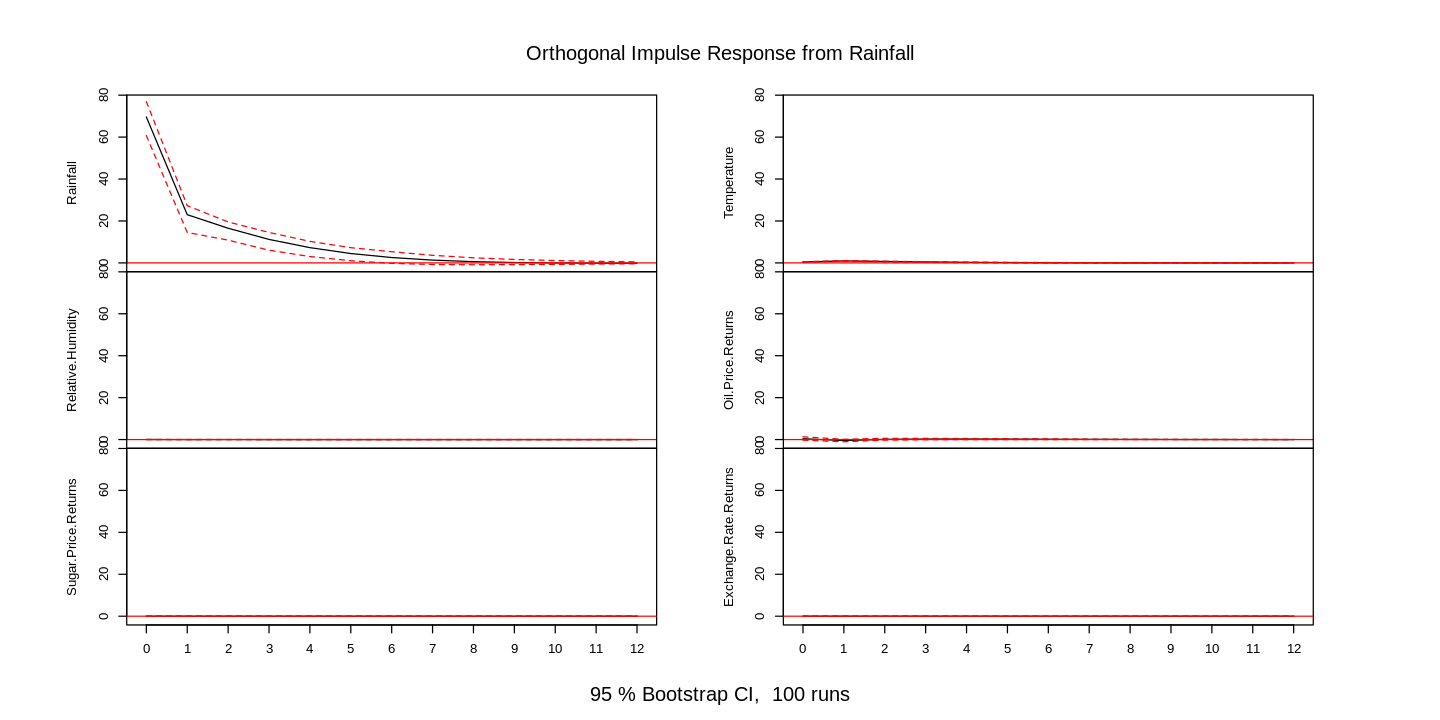

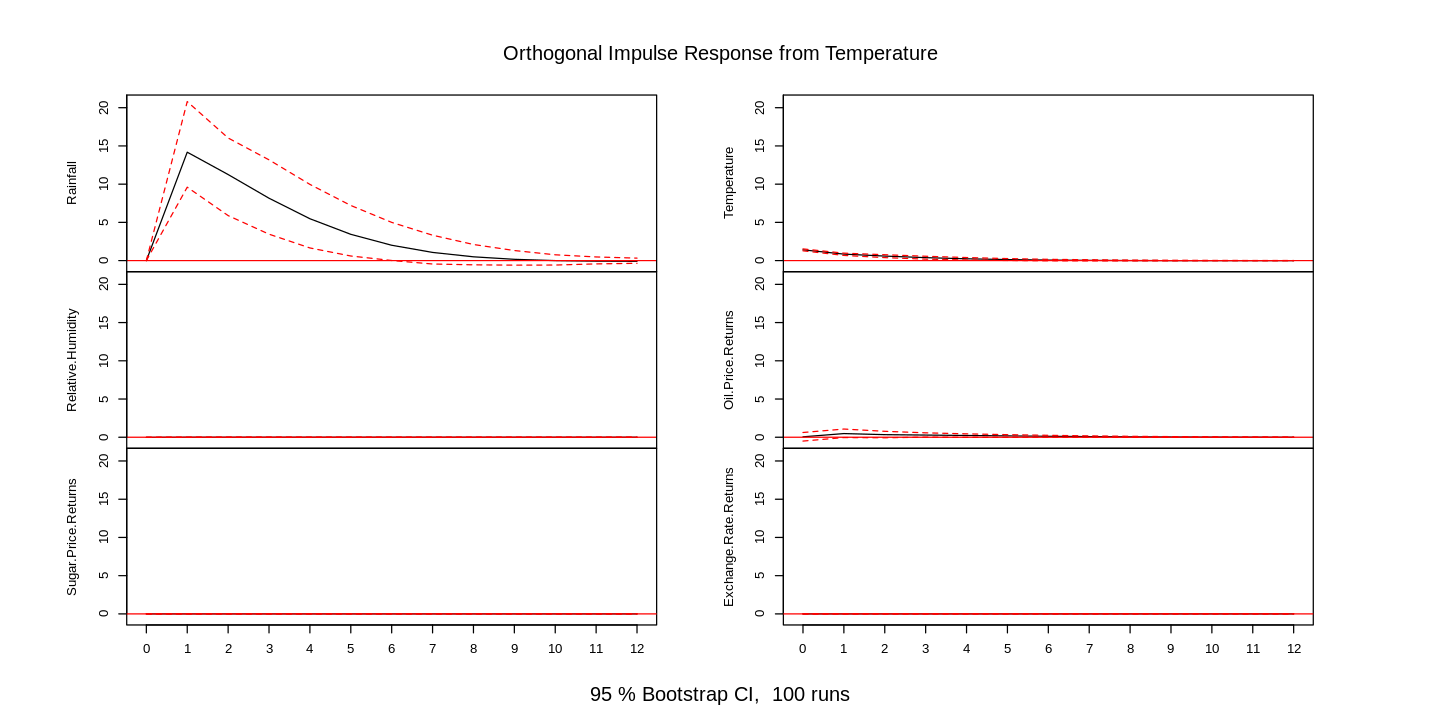

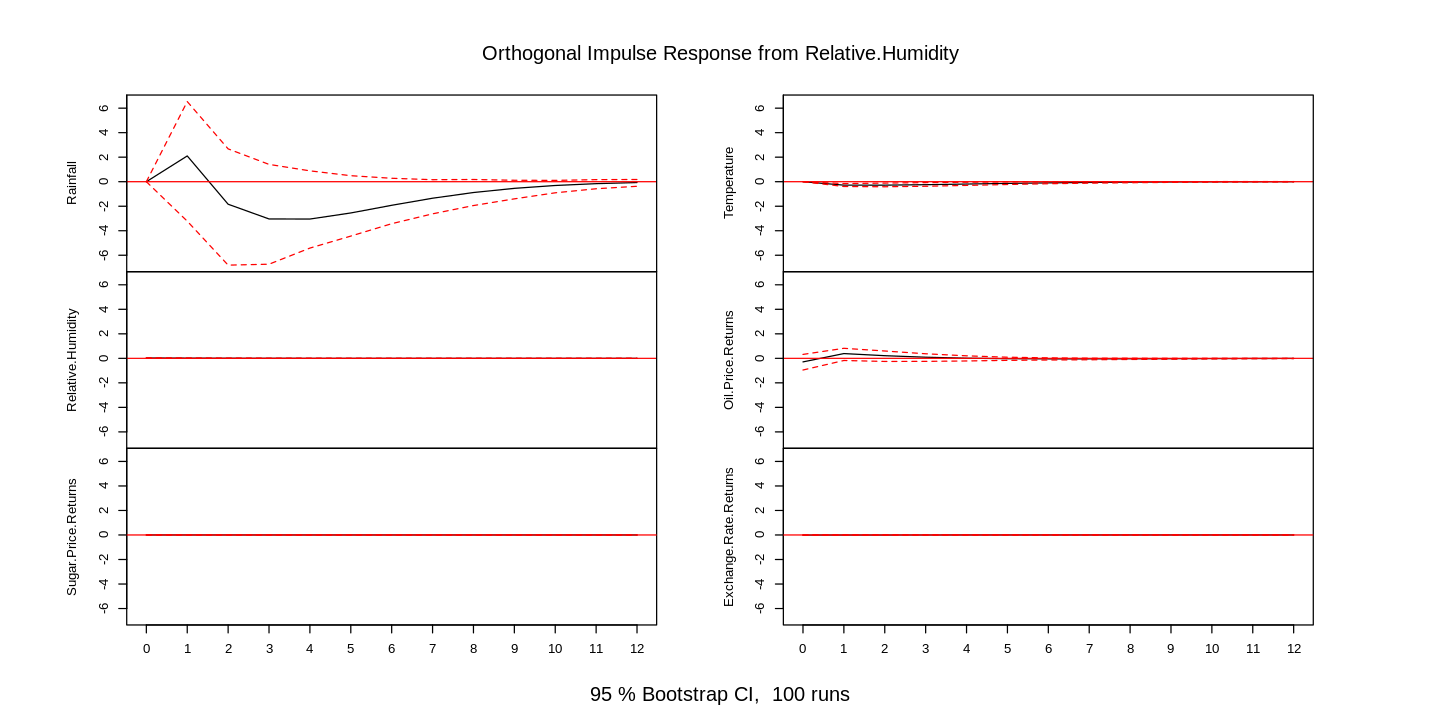

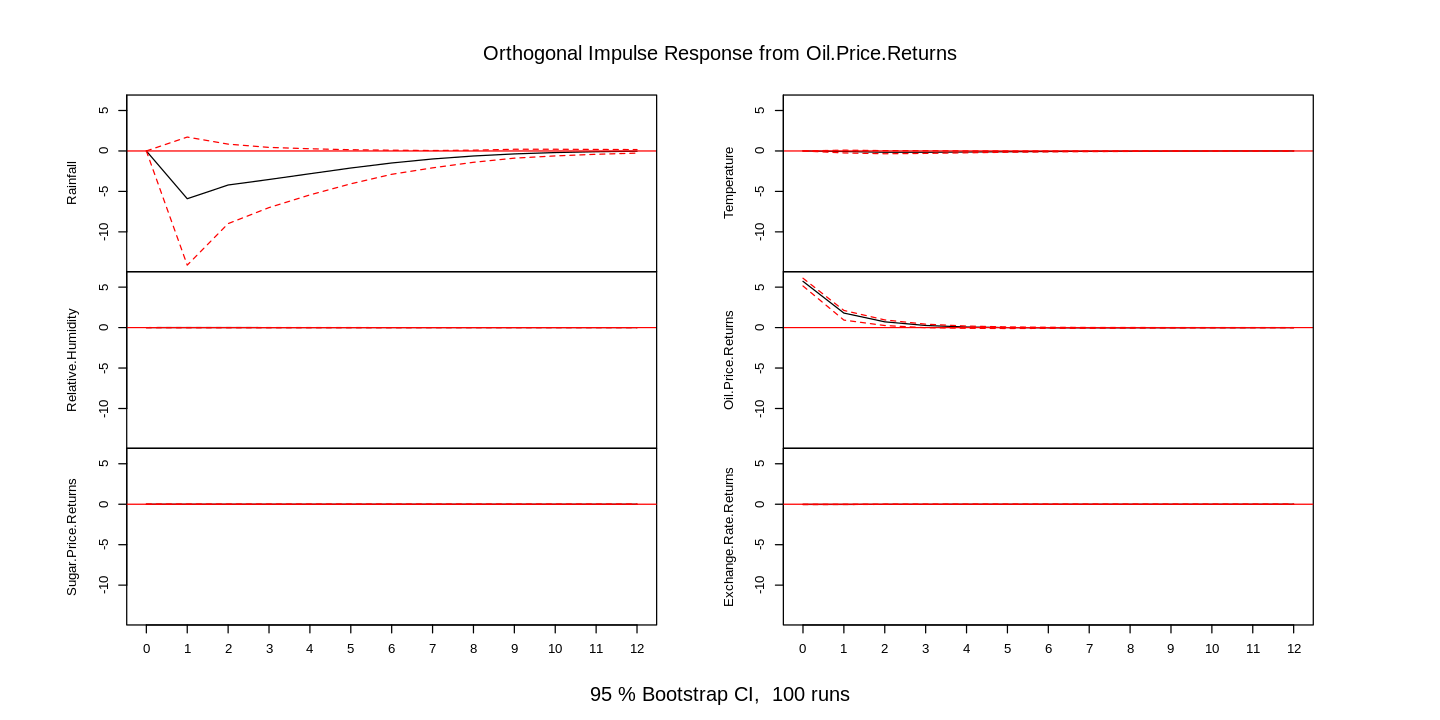

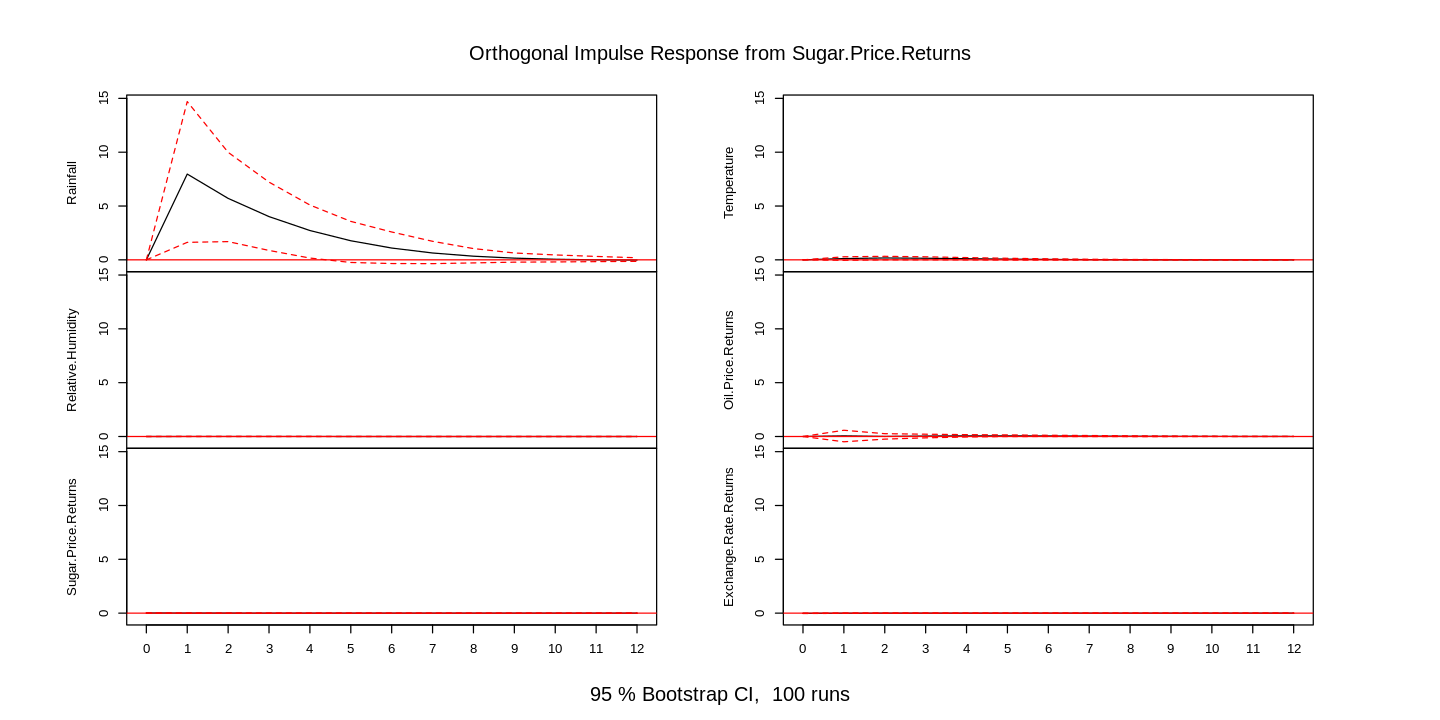

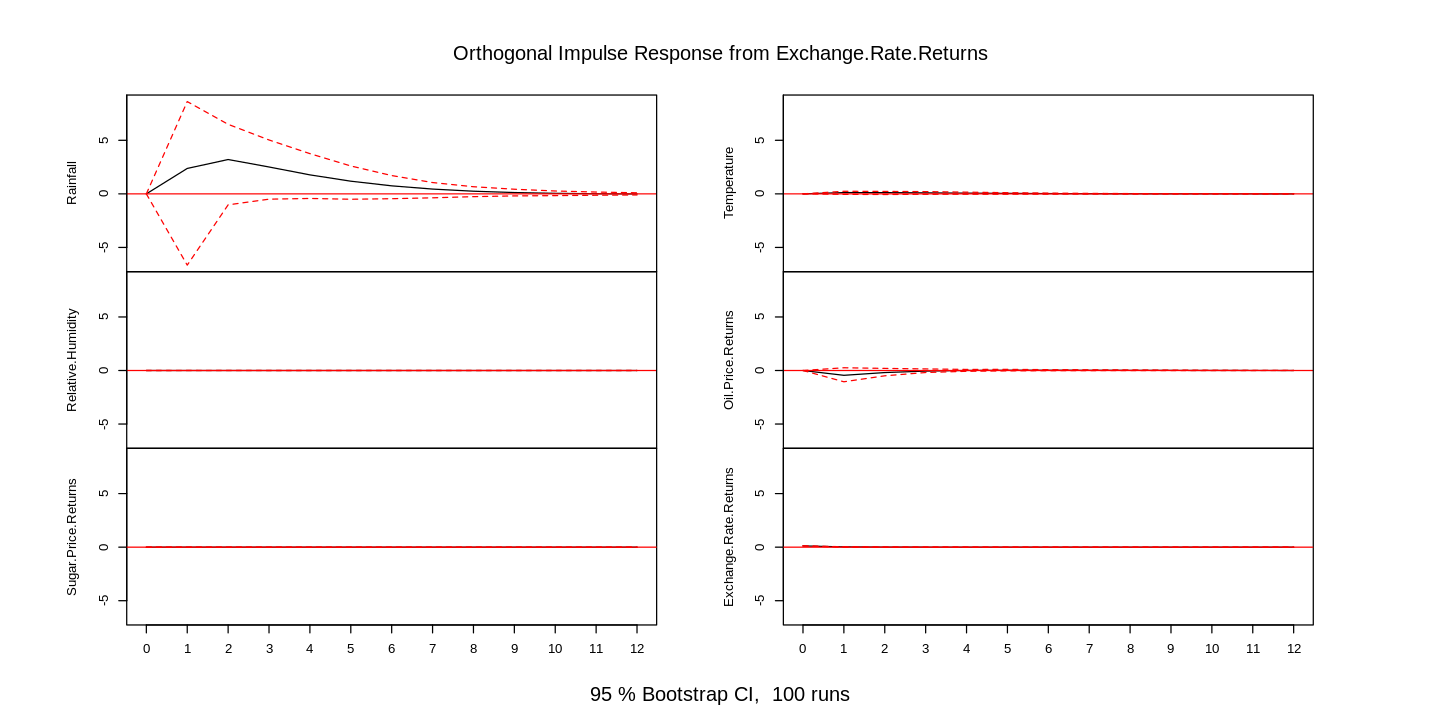

In [56]:
# Ajustement de la taille du graphique
options(repr.plot.width = 12, repr.plot.height = 6)

var.1lag <-VAR(y = df_stationary_data[,c("Rainfall", "Temperature", "Relative Humidity", "Oil Price Returns", "Sugar Price Returns", "Exchange Rate Returns")],type="const",lag.max = 1)

irf<-irf(var.1lag,n.ahead = 12,ortho = TRUE,ci=0.95)
plot(irf)

**1. Impact d'un choc sur `Rainfall`**

 - Aucun impact signicatif.

---

**2. Impact d'un choc sur `Temperature`**
- **Effet immédiat** :
  - Un choc sur la température provoque une augmentation  et significative de `Rainfall`.
- **Effets persistants** :
  - L'effet sur `Rainfall` reste affecté longtemps mais mais revient progressivement à son niveau initial.
- **Impact sur les variables économiques** :
  - Pas d'effet significatif sur `Oil.Price.Returns`, `Exchange.Rate.Returns`, ou `Sugar.Price.Returns`.

---

**3. Impact d'un choc sur `Relative.Humidity`**
- **Effet immédiat** :
  - Une augmentation de l'humidité relative n'a pas d'effet significatif immédiat sur `Rainfall` ou `Temperature`.
- **Effets persistants** :
  - Les réponses des variables climatiques sont faibles mais mesurable pour `Rainfall`.
- **Impact sur les variables économiques** :
  - Aucun impact notable sur `Oil.Price.Returns`, `Exchange.Rate.Returns`, ou `Sugar.Price.Returns`.

---

**4. Impact d'un choc sur `Oil.Price.Returns`**
- **Effet immédiat** :
  - Aucun impact significatif immédiat sur les variables climatiques mise a part pour `Rainfall`. Cela n'a pas beaucoup de sens.
- **Effets persistants** :
  - Les réponses des variables climatiques sont faibles ou insignifiantes.

---

**5. Impact d'un choc sur `Sugar.Price.Returns`**
- **Effet immédiat** :
  - Aucun effet immédiat sur les variables climatiques ou économiques.
- **Effets persistants** :
  - Les réponses des autres variables restent faibles mais perceptible sur `Rainfall` et `Oil.Price.Return`.

---

**6. Impact d'un choc sur `Exchange.Rate.Returns`**
- **Effet immédiat** :
  - Aucun effet significatif immédiat sur les variables climatiques ou sur les prix du pétrole.
- **Effets persistants** :
  - Les effets sur les autres variables sont visible sur `Rainfall` et `Oil.Price.Return`.

---



**Conclusion Globale**
- Les **variables climatiques** (**Temperature**, **Rainfall**, **Relative.Humidity**) montrent une forte interaction entre elles, avec des réponses transitoires mais significatives.
- Les **variables économiques** (**Oil.Price.Returns**, **Exchange.Rate.Returns**, **Sugar.Price.Returns**) ont un impact limité sur les variables climatiques et entre elles.
- Les **performances des prix du sucre** n'exercent pas d'influence notable sur les autres variables, corroborant les conclusions des tests de causalité et des analyses de cointégration.


#### 3.3.2 &emsp; Estimation des IRF par la méthode des projections locales

La méthode des projections locales permet de traiter les non-linéarités dans les relations économiques et d'obtenir des réponses plus robustes aux chocs, particulièrement lorsque le modèle VAR pourrait être limité dans sa capacité à capturer des phénomènes complexes.

[[1]]
NULL


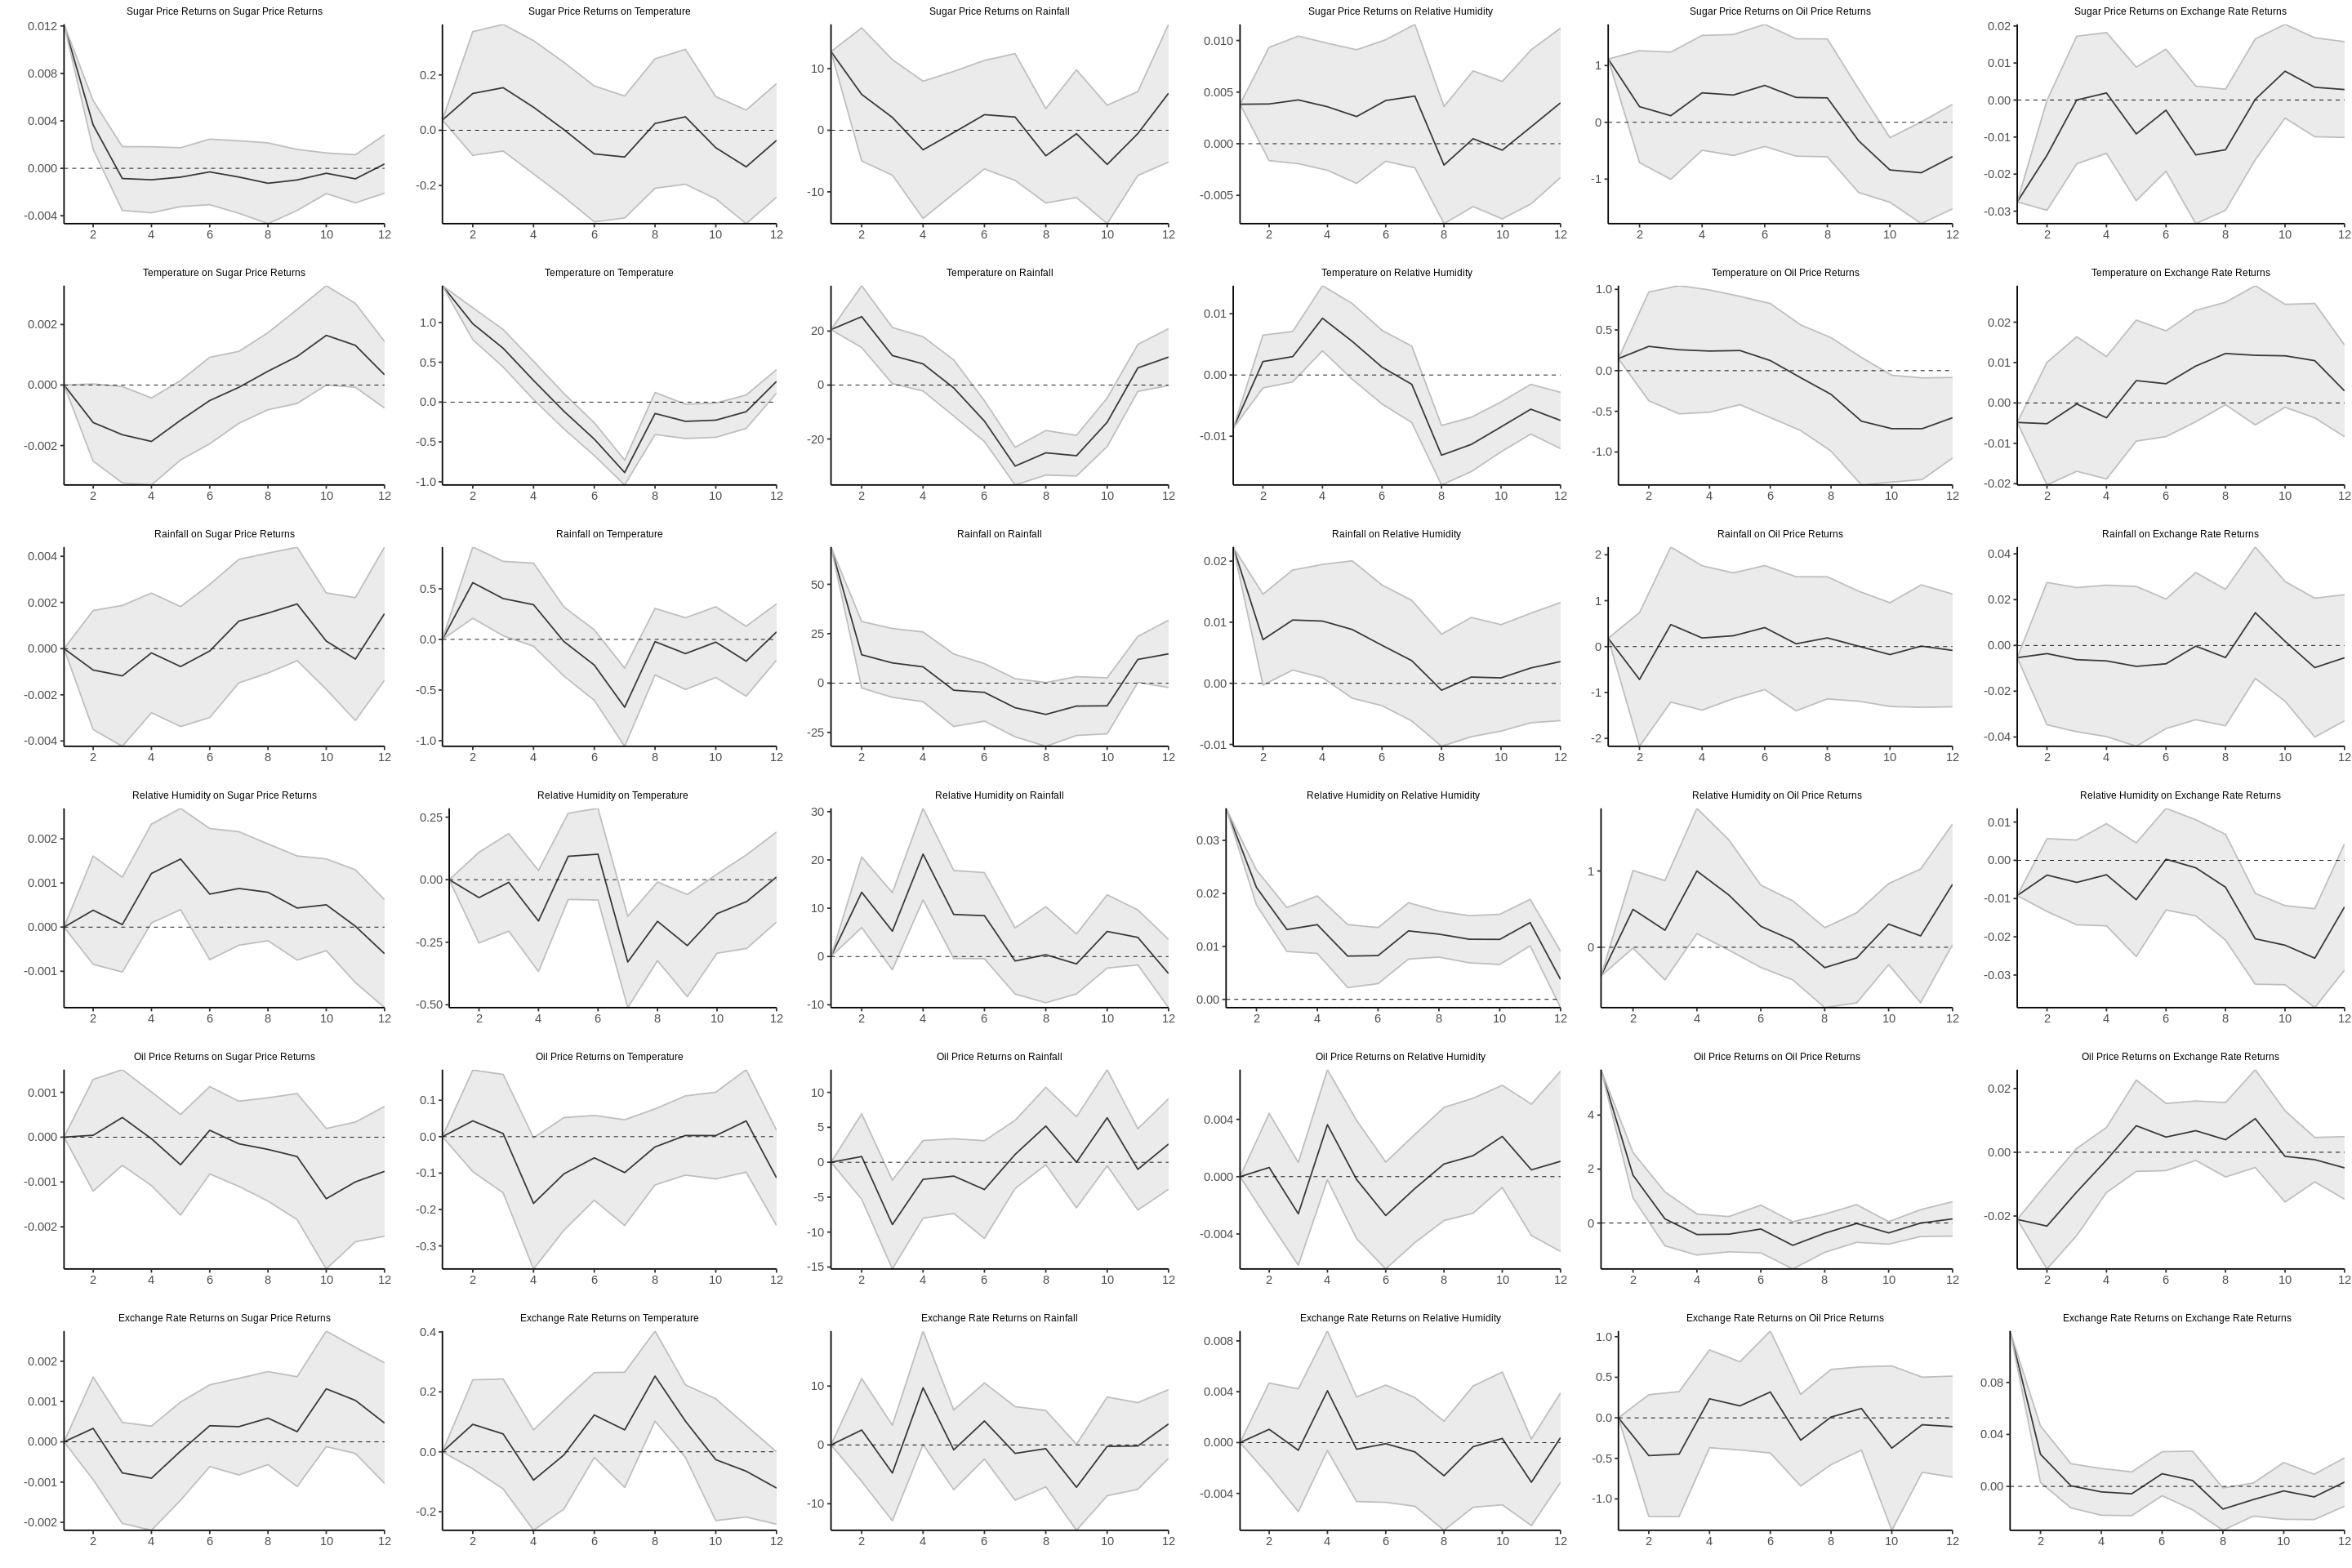

In [57]:
# Ajustement de la taille du graphique
options(repr.plot.width = 24, repr.plot.height = 16)

irf_LP <- lp_lin(
    endog_data = df_stationary_data[, c(2, 3, 4, 5, 6, 7)],
    lags_endog_lin = NaN,
    lags_criterion = 'BIC',
    max_lags = 8,
    trend = 0,
    shock_type = 0,
    confint = 1.96,
    hor = 12,
    adjust_se = TRUE
)
plot(irf_LP)

Chaque ligne correspond à une variable source de choc, et chaque colonne représente une variable cible affectée par le choc.

**Effet des chocs sur les variations des prix du sucre**

Les chocs climatiques (température, précipitations, humidité relative) affectent significativement les variations des prix du sucre, avec des impacts marqués à court terme et une dissipation rapide. Cela souligne la sensibilité des produits agricoles aux conditions climatiques, confirmant leur rôle central dans l’offre.

**Effet des chocs climatiques (température, précipitations et humidité relative)**

Les variables climatiques influencent les autres variables d'une manière significative mais transitoire. Par exemple :
- Un choc de température a un impact immédiat sur les retours des prix du sucre, mais cet effet diminue après quelques périodes.
- Les précipitations affectent davantage les variables directement liées au climat, comme l'humidité relative, avec des fluctuations persistantes sur les premiers horizons.
  
Cela correspond aux attentes : des conditions climatiques extrêmes modifient l'offre agricole à court terme, mais l'effet est amorti à moyen terme en raison de mécanismes d'adaptation.

**Effet des variations du prix du pétrole**

Les chocs sur les variations des prix du pétrole montrent des effets modérés mais significatifs sur certaines variables économiques, comme les variations des taux de change et, dans une moindre mesure, sur les variations des prix du sucre. Cela peut être interprété comme une transmission partielle des chocs pétroliers via des canaux de coûts de production (transport et énergie). Cependant, ces effets semblent se dissiper rapidement, suggérant que d'autres facteurs économiques compensent cette influence initiale.

**Effet des taux de change**

Les chocs sur les taux de change affectent faiblement les variables climatiques, mais modifient notablement les prix du pétrole, montrant l’interconnexion des marchés internationaux.

**Analyse générale des incertitudes**

Les intervalles de confiance (zones grises autour des courbes) permettent d’évaluer la robustesse des estimations. Les réponses des variables sont significatives lorsque ces intervalles ne recouvrent pas la ligne horizontale (zéro). Dans plusieurs cas, notamment pour les chocs climatiques et pétroliers, l'incertitude est limitée aux premiers horizons, ce qui renforce la fiabilité des conclusions à court terme.

**Conclusion partielle**

Ces graphiques IRF nous permettent de mieux mettre en lumière les interactions entre les variables climatiques, économiques et les marchés de matières premières. Les facteurs climatiques exercent une influence prédominante sur les prix du sucre, tandis que les interactions économiques, comme celles entre le pétrole et les taux de change, jouent un rôle secondaire.

### 3.4 &emsp; Test de Cointégration de Johansen

Après avoir étudié les fonctions impulsion-réponse issues des chocs, estimées à travers les approches VAR et des projections locales, il est essentiel d’examiner les relations de long terme entre les variables économiques et climatiques utilisées dans notre analyse. En effet, si les IRF permettent de capturer la dynamique des interactions à court et moyen terme, les tests de cointégration nous permettent d'analyser les relations structurelles qui lient ces variables sur un horizon long.

Pour identifier la présence de relations d’équilibre de long terme entre nos séries temporelles d'ordre 1 (Sugar Price, Oil price, Echange rate), nous procédons un test de cointégration de Johansen. Une relation de cointégration suggérerait que, malgré les fluctuations quotidiennes ou saisonnières, ces variables partagent une trajectoire commune.

#### 3.4.1 &emsp; Test de la trace

$$
\begin{align*}
\text{Hypothèses : }& \left\{
\begin{array}{ll}
H_0(0): & rang(\Pi) \leq 0 \\
H_1(0): & rang(\Pi) > 0
\end{array}
\right. \\
\\
\text{Statistique de test : }& \quad Q(0) = -T\sum^3_{i=1}ln(1-\hat{\lambda}_i)
\end{align*}
$$

In [58]:
df_temp <- df[, c("Date", "Sugar Price ($ per pound)", "Europe Brent Spot Price FOB ($ per Barrel)" , "Exchange Rate (BRL/USD)") ]
colnames(df_temp) <- c('date', 'sugar_price', 'Oil_Price', 'Exchange_Rat' )
df_stationary.vecm<-ca.jo(df_temp[, c(2, 3, 4)],ecdet = "none",spec = "transitory",type = 'trace',K=2)
summary(df_stationary.vecm)


###################### 
# Johansen-Procedure # 
###################### 

Test type: trace statistic , with linear trend 

Eigenvalues (lambda):
[1] 0.0721969843 0.0226849148 0.0003454698

Values of teststatistic and critical values of test:

          test 10pct  5pct  1pct
r <= 2 |  0.10  6.50  8.18 11.65
r <= 1 |  6.85 15.66 17.95 23.52
r = 0  | 28.88 28.71 31.52 37.22

Eigenvectors, normalised to first column:
(These are the cointegration relations)

                sugar_price.l1 Oil_Price.l1 Exchange_Rat.l1
sugar_price.l1     1.000000000  1.000000000      1.00000000
Oil_Price.l1      -0.002032375  0.002151042      0.01292675
Exchange_Rat.l1   -0.007147813 -0.019088262      1.54249519

Weights W:
(This is the loading matrix)

               sugar_price.l1 Oil_Price.l1 Exchange_Rat.l1
sugar_price.d      -0.0338972  -0.01427544    1.906382e-05
Oil_Price.d        26.8464201  -4.78469734    2.041701e-04
Exchange_Rat.d     -0.1073320   0.02387028   -1.155341e-03


### Test de Cointégration : Résultats du Test de Trace


### Résultats du Test de Cointégration de Johansen

| **Hypothèse nulle (\(H_0\))** | **Statistique de Test** | **Valeur Critique (5%)** | **Conclusion**                  |
|-------------------------------|--------------------------|---------------------------|----------------------------------|
| \ r ≤ 2                 | 0.10                    | 8.18                      | r ≤ 2  , accepté          |
| \r ≤ 1                 | 6.85                    | 17.95                     | r ≤ 1  , accepté          |
| \( r = 0 \)                   | 28.88                   | 31.52                   |  r ≤ 0 , accepté |

---

### Interprétation des Hypothèses

1. r ≤ 2   : Pas de relation de cointégration supplémentaire (accepté car \( 0.10 < 8.18 \)).
2. r ≤ 1   : Pas de deuxième relation de cointégration (accepté car \( 6.85 < 17.95 \)).
3. r ≤ 0   : Pas de relation de cointégration (marge étroite avec \( 28.88 > 28.71 \)).

---

### Conclusion Globale

- **Il n'y a pas de relation de cointégration significative au seuil de 5%.**
- Cela signifie que, selon ces résultats, les séries temporelles **n'ont pas de relation à long terme** qui les lies de manière stationnaire.

Dans notre cas, cela implique que le modèle VAR qui capture les dynamiques à court terme est suffisant pour expliquer les ajustements à long terme entre nos differentes variables.

En synthétisant les conclusions issues de notre modèle VAR, il apparaît clairement que les rendements du prix du sucre sont avant tout déterminés par leurs propres dynamiques passées. Les variables externes, telles que les conditions climatiques, les fluctuations des prix du pétrole ou les variations des taux de change, semblent jouer un rôle limité dans l'explication directe des variations des rendements à court terme.

Notre analyse a révélé la complexité des interactions économiques et environnementales. Ces relations, qui peuvent paraître intuitives à première vue, dissimulent en réalité des mécanismes bien plus sophistiqués. Pour mieux appréhender les dynamiques des prix du sucre, il pourrait être pertinent d'explorer d'autres approches méthodologiques, telles que des modèles non linéaires, des analyses de rupture structurelle ou des modèles intégrant des horizons temporels plus longs.




## Annexe

### A &emsp; Présentation des autres données

#### A.1 &emsp; Les facteurs climatiques

En raison de leur influence directe sur les rendements de la canne à sucre, principale matière première utilisée pour la production de canne à sucre, il convient d'analyser les facteurs climatiques.

Pour cette analyse, nous avons choisi d'étudier la température, les précipitations, et l'humidité. Les données climatiques proviennent de [Bloomberg](https://www.bloomberg.com/) et de [OpenWeather](https://openweathermap.org/). Elles sont tirées de stations météorologiques situées à Sao Paulo dans le sud-est du Brésil où la production agricole de canne à sucre est la plus importante.

La température agit sur le métabolisme des plantes pouvant réduire les rendements. Les précipitations, quant à elles, conditionnent l’irrigation des cultures, tandis que l'humidité affecte le développement des maladies végétales et donc la qualité de la récolte.

Ces variables permettent ainsi de capturer l'impact des variations climatiques et des événements extrêmes sur la production agricole.

La variable `Temperature` représente la valeur moyenne de la température pour chaque mois en degrés Celsius.
\
La variable `Rainfall` représente le cumul des précipitations pour chaque mois en millimètres.
\
La variable `Relative Humidity` indique le degré de saturation en vapeur d'eau de l'air mensuelle moyen.


-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
                                                                              Temperature 
-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
        

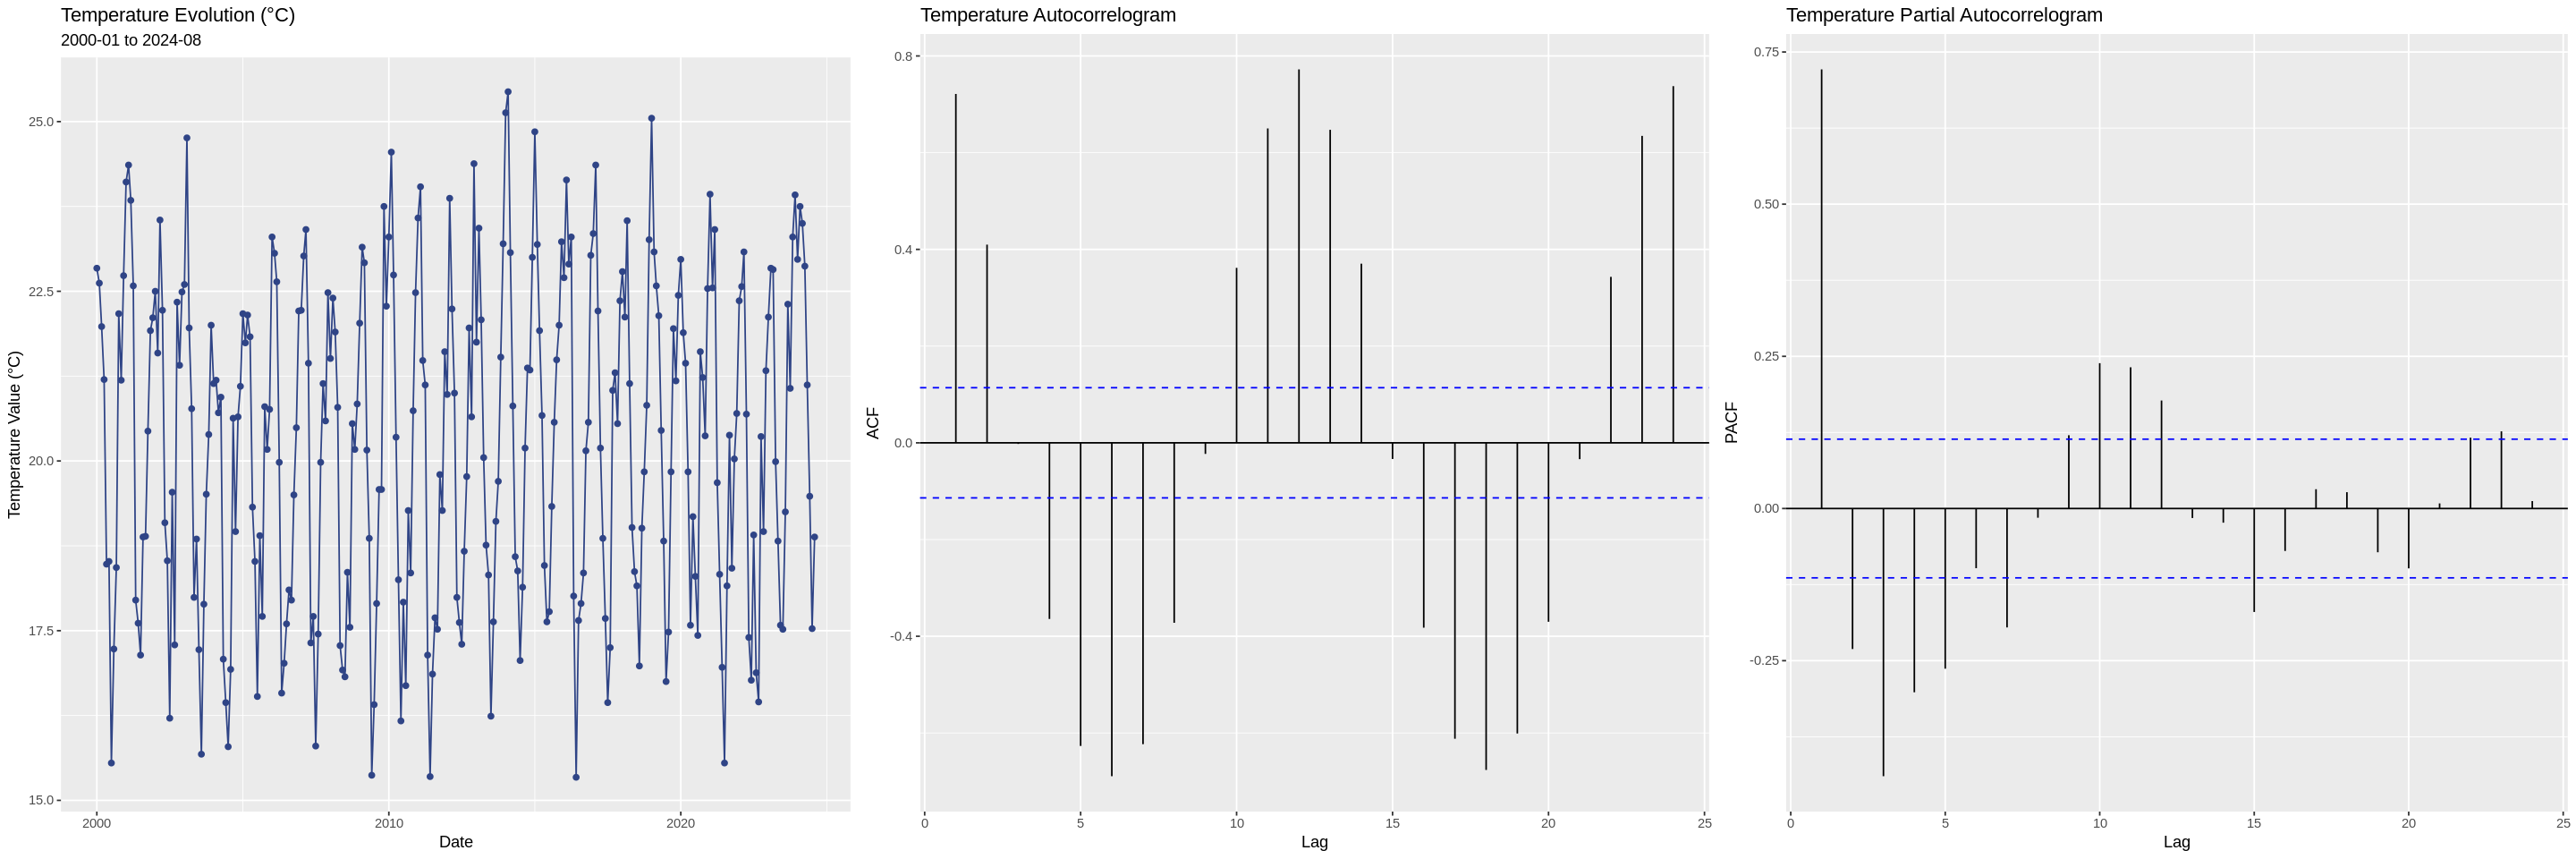


-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
                                                                              Rainfall 
-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
        

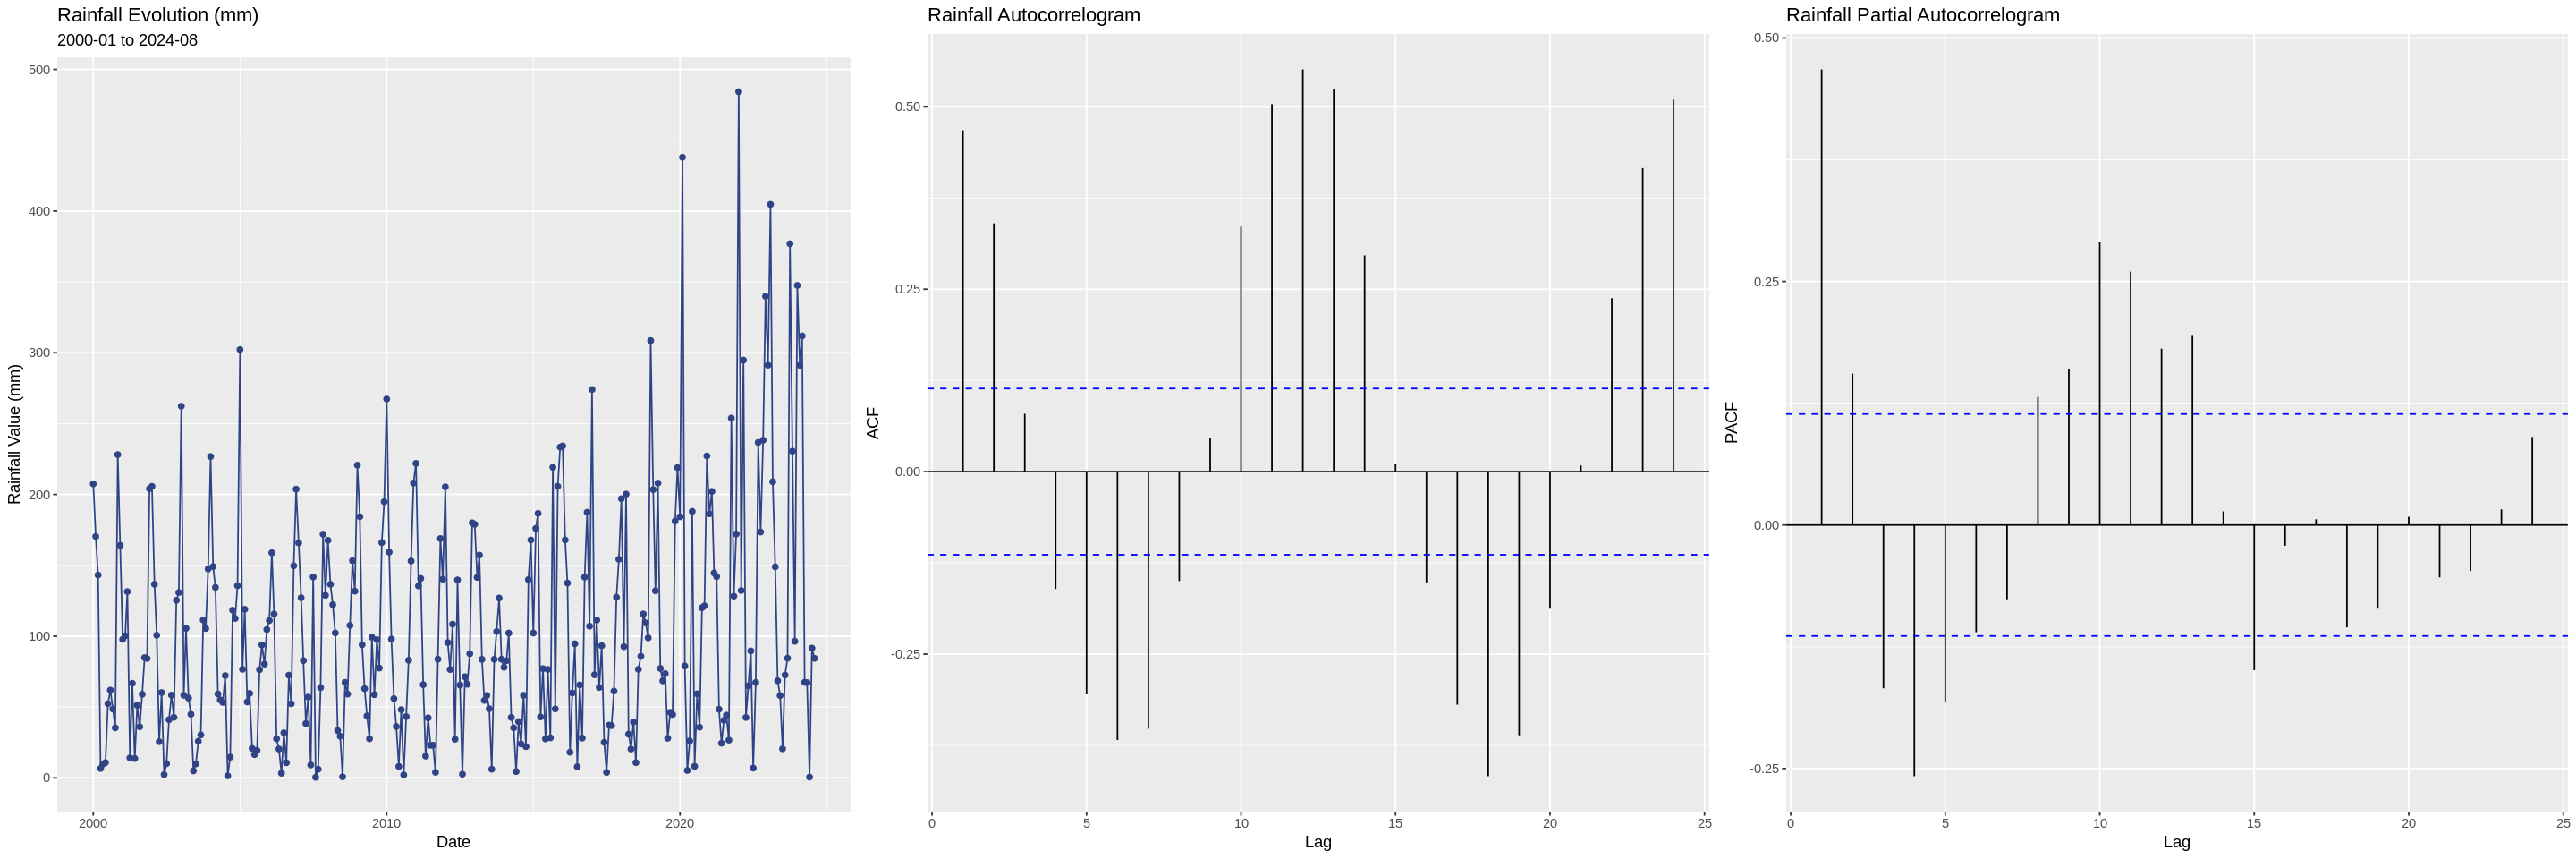


-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
                                                                              Relative Humidity 
-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
        

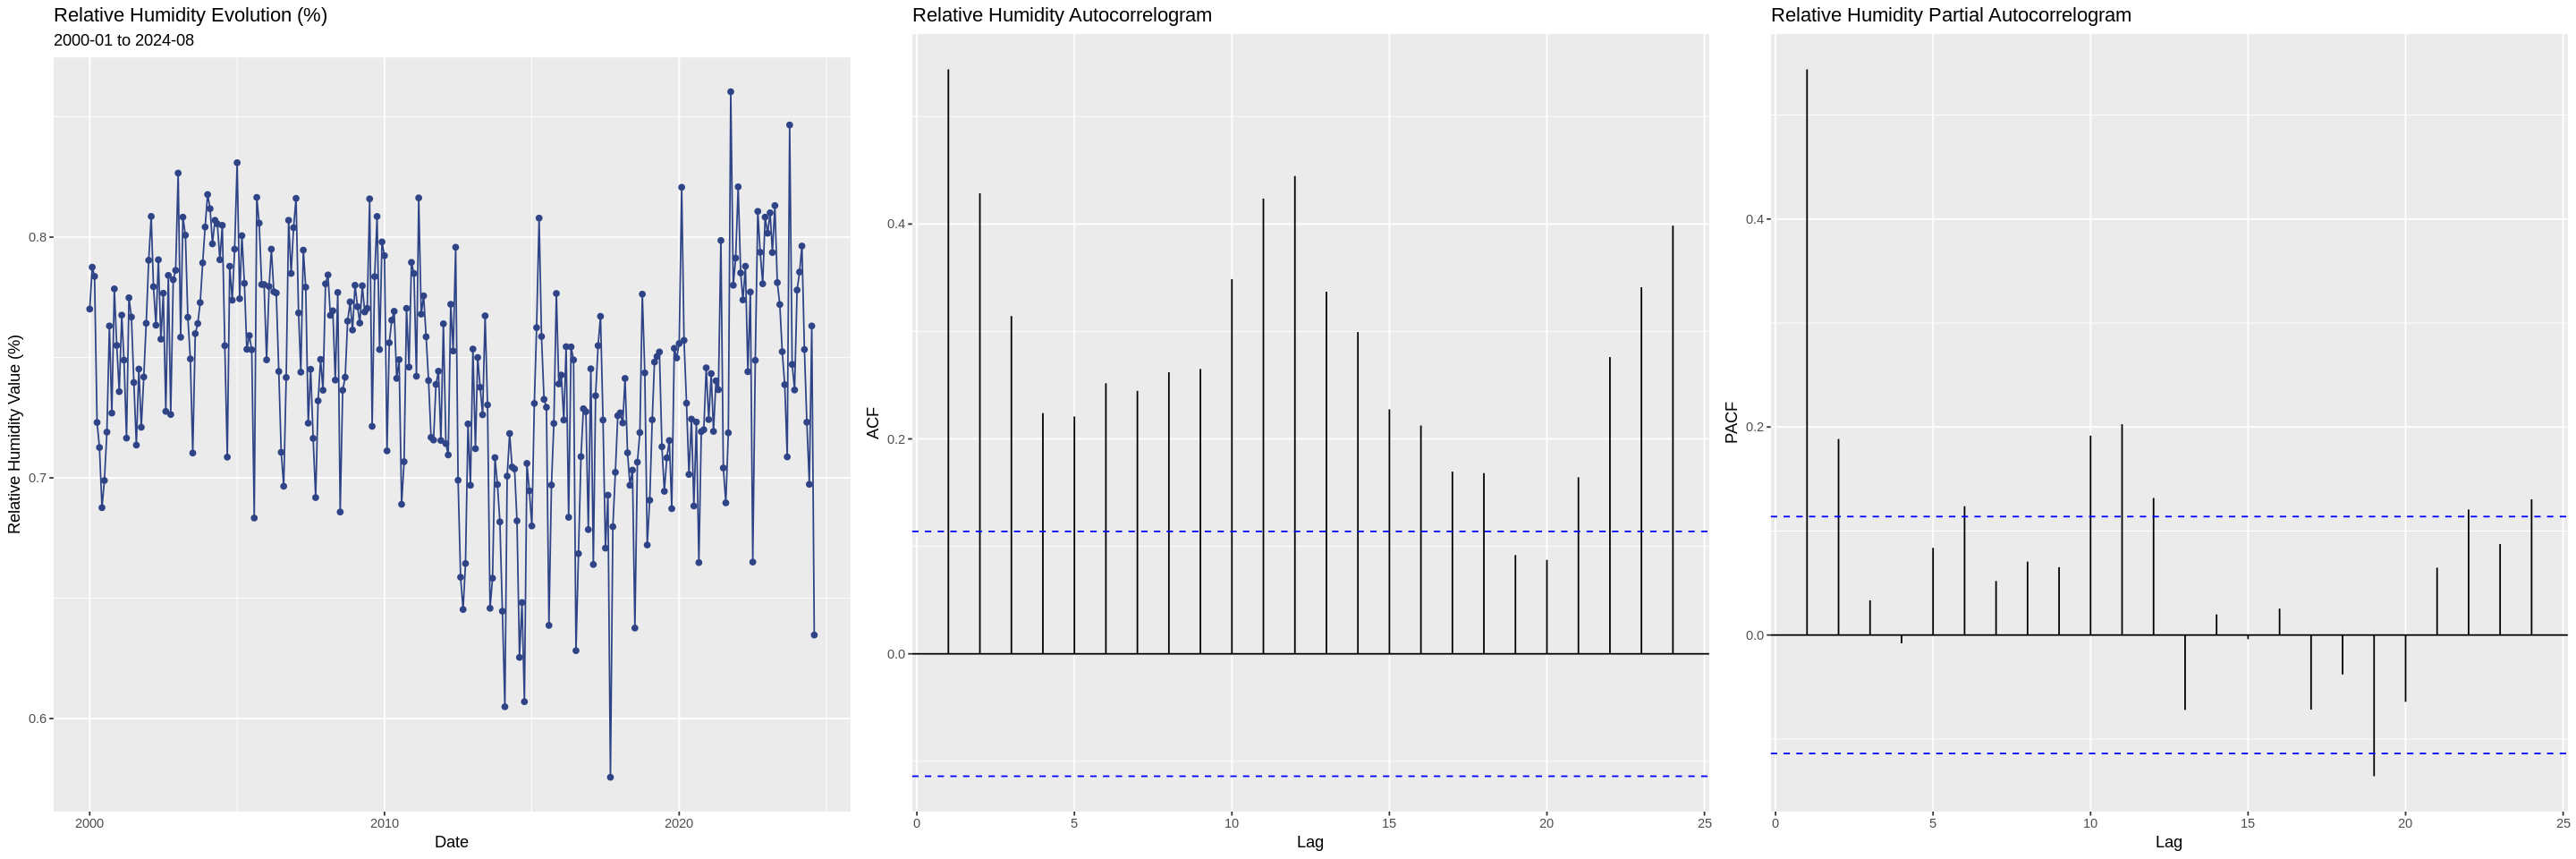

In [59]:
# Ajuster la taille des graphiques dans le Notebook
options(repr.plot.width = 24, repr.plot.height = 8)

# Parcourir toutes les colonnes à partir de la deuxième
for (col in colnames(df)[3:5]) {
  # Extraire le nom de la variable et l'unité à partir du nom de la colonne
  parts <- unlist(strsplit(col, " \\(")) # Séparer par espace suivi de parenthèse ouvrante
  variable_name <- parts[1] # Partie avant la parenthèse
  unit <- ifelse(length(parts) > 1, gsub("\\)", "", parts[2]), "") # Supprimer la parenthèse fermante

  # Créer un DataFrame temporaire avec la date et la colonne courante
  df_temp <- df[, c("Date", col)]
  colnames(df_temp) <- c("date", "value")


  # Créer le graphique avec ggplot2
  p <- ggplot(data=df_temp, aes(x=date, y=value)) +
    geom_point(color='#2F4486') +
    geom_line(color='#2F4486') +
    xlab('Date') +
    ylab(paste(variable_name, "Value", paste("(",unit,")",sep=""))) +
    labs(title=paste(variable_name, "Evolution", paste("(",unit,")",sep="")),
         subtitle="2000-01 to 2024-08")

  # ACF
  #acf_plot <- acf(df_temp$value, main = paste(variable_name, "Autocorrelogram - January 2000 to August 2024"), na.action = na.pass)
  acf_plot <- autoplot(acf(df_temp$value, plot = FALSE)) +
    ggtitle(paste(variable_name, "Autocorrelogram"))

  #PACF
  #pacf_plot <- pacf(df_temp$value, main = paste(variable_name, "Partial Autocorrelogram - January 2000 to August 2024"), na.action = na.pass)
  pacf_plot <- autoplot(pacf(df_temp$value, plot = FALSE)) +
    ggtitle(paste(variable_name, "Partial Autocorrelogram"))

  # Afficher les graphiques
  combined_plot <- grid.arrange(p, acf_plot, pacf_plot,
                                ncol=3,
                                widths = c(1, 1, 1), # Garde la même largeur relative
                                heights = c(1),       # Garde la hauteur égale
                                padding = unit(1, "cm") # Ajuste l'espacement
                                )

  cat(paste("\n-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------\n",
            "                                                                            ",
            variable_name,
            "\n-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------\n        "))
}

#### A.2 &emsp; Les variables macroéconomiques

En raison des dynamiques d'offre et de demande ainsi que les coûts de production, il est nécessaire d'étudier l'influence des variables macroéconomiques afin d'expliquer les prix du sucre.

Nous avons alors décidé d'analyser le prix du pétrole (présenté dans le corps du projet) et le taux de change BRL/USD. Les données sont issues de la [FRED](https://fred.stlouisfed.org/).

Le taux de change BRL/USD influence les prix du sucre. Les variations du taux de change ne sont pas seulement des fluctuations monétaires abstraites : elles influencent directement les décisions des producteurs brésiliens et les dynamiques de marché.

En effet, une dépréciation du real brésilien par rapport au dollar rendrait les exportations brésiliennes plus compétitives sur le marché international. Cela encouragerait une hausse des volumes exportés. À terme, cet excédent d'offre sur le marché international peut exercer une pression à la baisse sur les prix mondiaux du sucre.

A l'inverse, une appréciation du real brésilien par rapport au dollar réduit la compétitivité des exportations sur le marché international, car elles deviennent plus coûteuses pour les acheteurs étrangers. Cette diminution de la compétitivité peut entraîner une réduction des volumes exportés. Par conséquent, une offre restreinte sur le marché mondial pourrait exercer une pression à la hausse sur les prix internationaux du sucre.

La variable `Exchange Rate` représente le taux de change moyen entre le réal brésilien et le dollar américain.


-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
                                                                              Exchange Rate 
-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
        

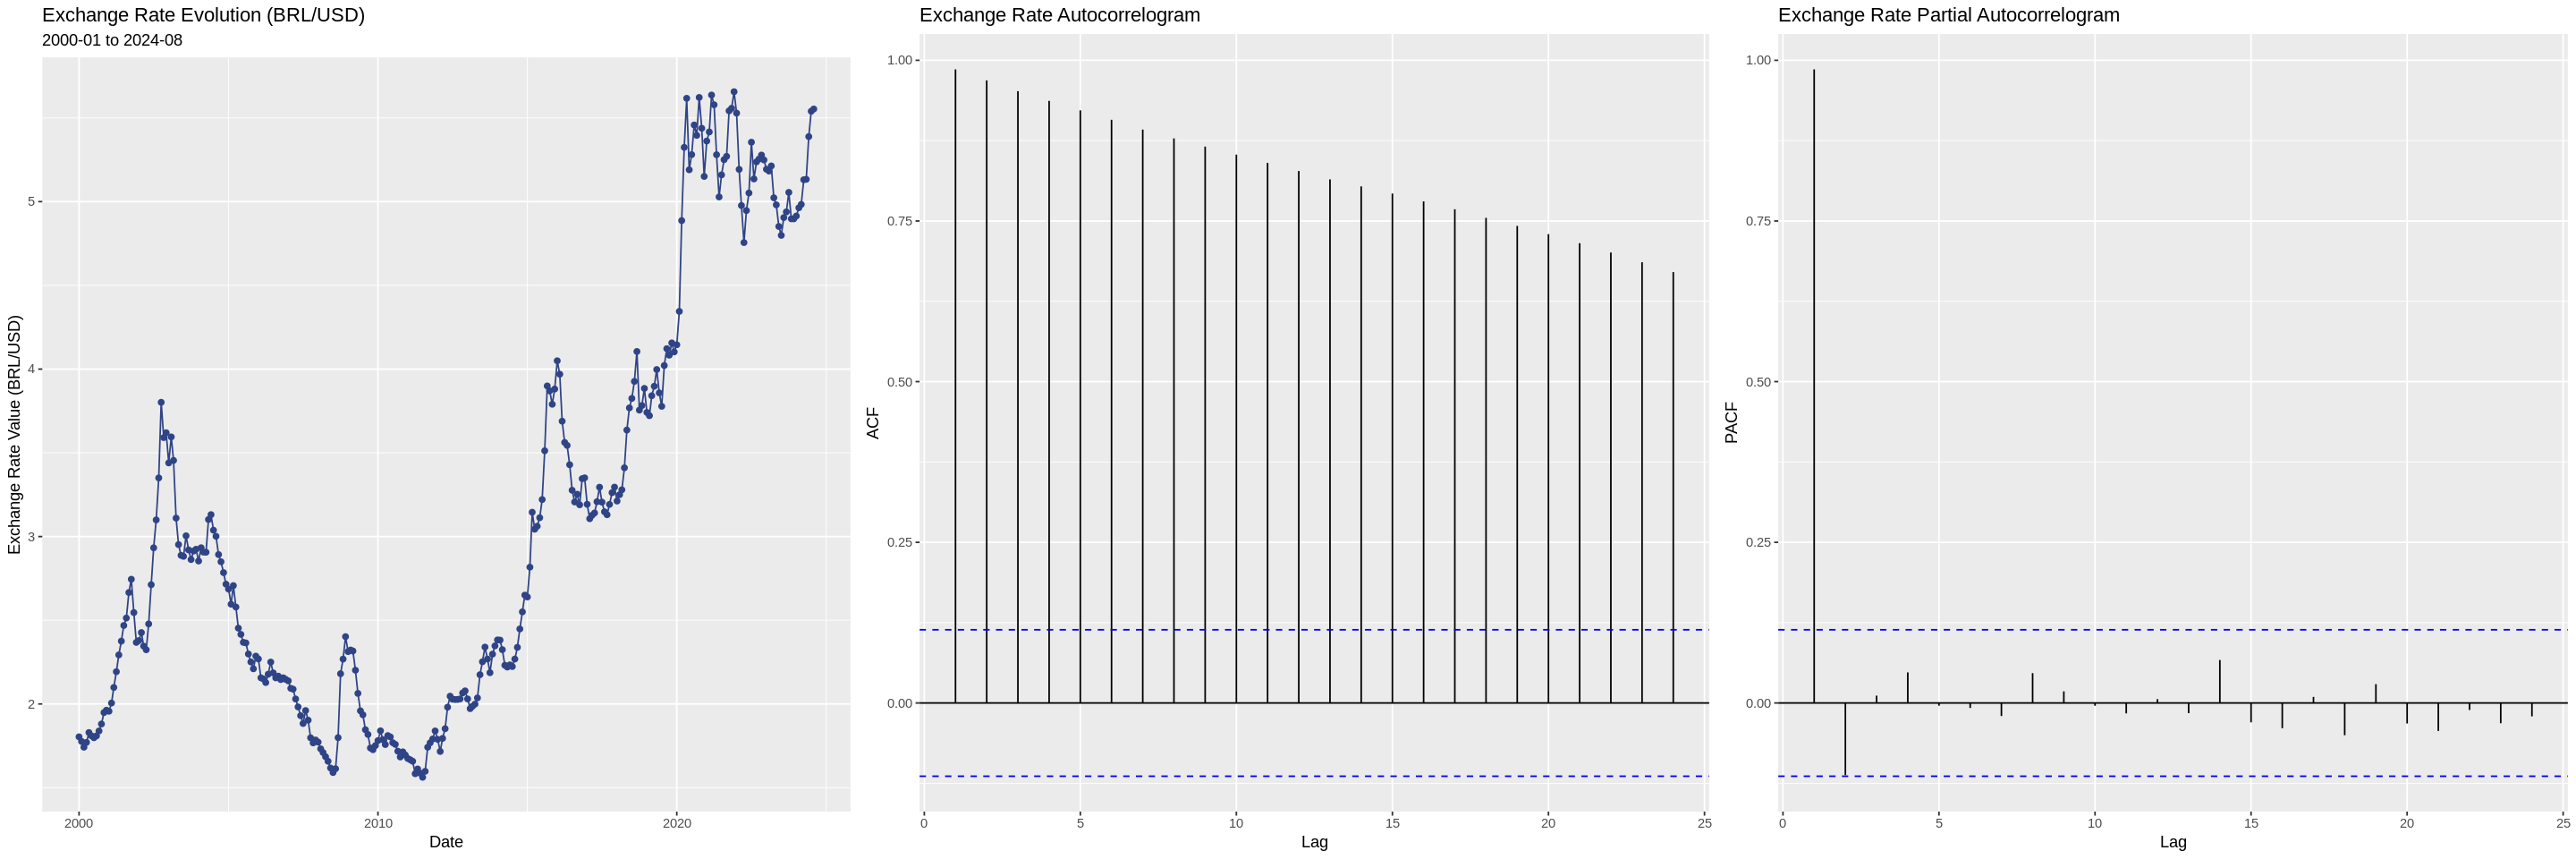

In [60]:
# Ajuster la taille des graphiques dans le Notebook
options(repr.plot.width = 24, repr.plot.height = 8)

# Parcourir toutes les colonnes à partir de la deuxième
for (col in colnames(df)[9]) {

  # Extraire le nom de la variable et l'unité à partir du nom de la colonne
  parts <- unlist(strsplit(col, " \\(")) # Séparer par espace suivi de parenthèse ouvrante
  variable_name <- parts[1] # Partie avant la parenthèse
  unit <- ifelse(length(parts) > 1, gsub("\\)", "", parts[2]), "") # Supprimer la parenthèse fermante

  # Créer un DataFrame temporaire avec la date et la colonne courante
  df_temp <- df[, c("Date", col)]
  colnames(df_temp) <- c("date", "value")


  # Créer le graphique avec ggplot2
  p <- ggplot(data=df_temp, aes(x=date, y=value)) +
    geom_point(color='#2F4486') +
    geom_line(color='#2F4486') +
    xlab('Date') +
    ylab(paste(variable_name, "Value", paste("(",unit,")",sep=""))) +
    labs(title=paste(variable_name, "Evolution", paste("(",unit,")",sep="")),
         subtitle="2000-01 to 2024-08")

  # ACF
  #acf_plot <- acf(df_temp$value, main = paste(variable_name, "Autocorrelogram - January 2000 to August 2024"), na.action = na.pass)
  acf_plot <- autoplot(acf(df_temp$value, plot = FALSE)) +
    ggtitle(paste(variable_name, "Autocorrelogram"))

  #PACF
  #pacf_plot <- pacf(df_temp$value, main = paste(variable_name, "Partial Autocorrelogram - January 2000 to August 2024"), na.action = na.pass)
  pacf_plot <- autoplot(pacf(df_temp$value, plot = FALSE)) +
    ggtitle(paste(variable_name, "Partial Autocorrelogram"))

  # Afficher les graphiques
  combined_plot <- grid.arrange(p, acf_plot, pacf_plot,
                                ncol=3,
                                widths = c(1, 1, 1), # Garde la même largeur relative
                                heights = c(1),       # Garde la hauteur égale
                                padding = unit(1, "cm") # Ajuste l'espacement
                                )

  cat(paste("\n-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------\n",
            "                                                                            ",
            variable_name,
            "\n-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------\n        "))
}

### B &emsp; Stationnarisation des autres données

#### B.1 Tests de stationnarité

##### ***Test de Dickey-Fuller augmenté***

$$
\text{Hypothèses : } \left\{
\begin{array}{ll}
H_0: & \rho = 0 →x_t & \text{non stationnaire} \\
H_1: & \rho < 0 → x_t & \text{stationnaire}
\end{array}
\right. \\
\\
\text{Statistique de test : } \quad t_{\hat{\rho}}=\frac{\hat{\rho}}{\hat{\sigma}}_{\hat{\rho}} = \frac{\hat{\phi}_1 - 1}{\hat{\sigma}_{\hat{\phi}_1}}
$$

###### Test ADF avec constante et tendance déterministe

In [61]:
# Création d'une liste pour récupérer les séries ayant besoin d'un test de coefficient de la tendance
trend_test <- list()
c <- 2
k <- 1

# Parcourir toutes les colonnes à partir de la troisième
for (col in colnames(df)[c(3:5,9)]) {

  if (c==5){
    c <- 9
  } else{
    c <- c + 1
  }
  # Extraire le nom de la variable et l'unité à partir du nom de la colonne
  parts <- unlist(strsplit(col, " \\(")) # Séparer par espace suivi de parenthèse ouvrante
  variable_name <- parts[1] # Partie avant la parenthèse
  unit <- ifelse(length(parts) > 1, gsub("\\)", "", parts[2]), "") # Supprimer la parenthèse fermante


  # Créer un DataFrame temporaire avec la date et la colonne courante
  df_temp <- df[, c("Date", col)]
  colnames(df_temp) <- c("date", "value")

  # Effectuer le test ADF (Augmented Dickey-Fuller) sur la variable
  adf_temp <- ur.df(y = df_temp$value, type = "trend", lag = 8, selectlags = "AIC")

  # Afficher les résultats du test ADF
  cat(paste("\n----------------------------------------------------------------------------------------------------------------------------------\n",
    "                                 ",
    "Test ADF avec constante et tendance déterministe pour :", variable_name,
    "\n----------------------------------------------------------------------------------------------------------------------------------\n"))
  #print(summary(adf_temp))

  # Récupération de la p-value du z-lag 1
  p_value <- adf_temp@teststat[1]
  crit <- adf_temp@cval[1,2]

  if (p_value < crit){
    trend_test[k] <- c
    k <- k + 1
    print(paste0(p_value," < ", crit))
    print("On rejette H0. On procède à un test de significativé du coefficient de la tendance.")
    print(summary(adf_temp))
  }  else {
    print(paste0(p_value," > ",crit))
    print("On ne rejette pas H0. On procède à un test ADF avec constante.")
  }
}


----------------------------------------------------------------------------------------------------------------------------------
                                   Test ADF avec constante et tendance déterministe pour : Temperature 
----------------------------------------------------------------------------------------------------------------------------------
[1] "-7.53744935896593 < -3.42"
[1] "On rejette H0. On procède à un test de significativé du coefficient de la tendance."

############################################### 
# Augmented Dickey-Fuller Test Unit Root Test # 
############################################### 

Test regression trend 


Call:
lm(formula = z.diff ~ z.lag.1 + 1 + tt + z.diff.lag)

Residuals:
    Min      1Q  Median      3Q     Max 
-3.0070 -0.8250 -0.0146  0.8524  3.1767 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) 20.229056   2.689016   7.523 7.58e-13 ***
z.lag.1     -1.009940   0.133990  -7.537 6.91e-13 ***
tt     

***Test de significativité du coefficient de la tendance***

---
**Température**

On procède à un test de significativité du coefficient de la tendance.
$$
\text{Hypothèses : } \left\{
\begin{array}{ll}
H_0: & b = 0 \\
H_1: & b \neq 0
\end{array}
\right. \\
\\
\text{Statistique de test : } \quad t_{\hat{b}}=\frac{\hat{b}}{\hat{\sigma}}_{\hat{b}}
\\
\text{Règle de décision : }\quad |t_b|=1.786 < 1,96
$$

On ne rejette pas l'hypothèse nulle de non significativité de la tendance déterministe au seuil de 5%. Cependant, la valeur de la statistique est significative au seuil 1% et est proche du seuil 5%. Notre série est stationnaire avec constante et tendance déterministe. On effectue des tests KPSS pour confirmer ce résultat.

---

**Précipitations**

On procède à un test de significativité du coefficient de la tendance.
$$
\text{Hypothèses : } \left\{
\begin{array}{ll}
H_0: & b = 0 \\
H_1: & b \neq 0
\end{array}
\right. \\
\\
\text{Statistique de test : } \quad t_{\hat{b}}=\frac{\hat{b}}{\hat{\sigma}}_{\hat{b}}
\\
\text{Règle de décision : }\quad |t_b|=6.205 > 1,96
$$

On rejette l'hypothèse nulle de non significativité de la tendance déterministe. Notre série est stationnaire avec constante et tendance déterministe. On effectue des tests KPSS pour confirmer ce résultat.

---

**Humidité relative**

On procède à un test de significativité du coefficient de la tendance.
$$
\text{Hypothèses : } \left\{
\begin{array}{ll}
H_0: & b = 0 \\
H_1: & b \neq 0
\end{array}
\right. \\
\\
\text{Statistique de test : } \quad t_{\hat{b}}=\frac{\hat{b}}{\hat{\sigma}}_{\hat{b}}
\\
\text{Règle de décision : }\quad |t_b|=2.063 > 1,96
$$

On rejette l'hypothèse nulle de non significativité de la tendance déterministe. Notre série est stationnaire avec constante et tendance déterministe. On effectue des tests KPSS pour confirmer ce résultat.

###### Test ADF avec constante

In [62]:
# Parcourir toutes les colonnes à partir de la deuxième
for (col in colnames(df)[9]) {

  # Extraire le nom de la variable et l'unité à partir du nom de la colonne
  parts <- unlist(strsplit(col, " \\(")) # Séparer par espace suivi de parenthèse ouvrante
  variable_name <- parts[1] # Partie avant la parenthèse
  unit <- ifelse(length(parts) > 1, gsub("\\)", "", parts[2]), "") # Supprimer la parenthèse fermante


  # Créer un DataFrame temporaire avec la date et la colonne courante
  df_temp <- df[, c("Date", col)]
  colnames(df_temp) <- c("date", "value")

  # Effectuer le test ADF (Augmented Dickey-Fuller) sur la variable
  adf_temp <- ur.df(y = df_temp$value, type = "drift", lag = 8, selectlags = "AIC")

  # Afficher les résultats du test ADF
  cat(paste("\n----------------------------------------------------------------------------------------------------------------------------------\n",
    "                                 ",
    "Test ADF avec constante pour :", variable_name,
    "\n----------------------------------------------------------------------------------------------------------------------------------\n"))
  print(summary(adf_temp))


  # Récupération de la p-value du z-lag 1
  p_value <- adf_temp@teststat[1]
  crit <- adf_temp@cval[1,2]

  if (p_value < crit){
    print(paste0(p_value," < ",crit))
    print("On rejette H0. On procède à un test de significativé de la constante.")
    print(summary(adf_temp))
  }  else {
    print(paste0(p_value," > ",crit))
    print("On ne rejette pas H0. On procède à un test ADF sans constante ni tendance déterministe.")
  }
}


----------------------------------------------------------------------------------------------------------------------------------
                                   Test ADF avec constante pour : Exchange Rate 
----------------------------------------------------------------------------------------------------------------------------------

############################################### 
# Augmented Dickey-Fuller Test Unit Root Test # 
############################################### 

Test regression drift 


Call:
lm(formula = z.diff ~ z.lag.1 + 1 + z.diff.lag)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.50841 -0.05740 -0.00596  0.05631  0.48245 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept)  0.018816   0.019818   0.949    0.343    
z.lag.1     -0.003064   0.006015  -0.509    0.611    
z.diff.lag   0.272696   0.057419   4.749 3.24e-06 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 

###### Test ADF sans constante ni tendance déterministe

In [63]:
# Parcourir toutes les colonnes à partir de la deuxième
for (col in colnames(df)[9]) {

  # Extraire le nom de la variable et l'unité à partir du nom de la colonne
  parts <- unlist(strsplit(col, " \\(")) # Séparer par espace suivi de parenthèse ouvrante
  variable_name <- parts[1] # Partie avant la parenthèse
  unit <- ifelse(length(parts) > 1, gsub("\\)", "", parts[2]), "") # Supprimer la parenthèse fermante


  # Créer un DataFrame temporaire avec la date et la colonne courante
  df_temp <- df[, c("Date", col)]
  colnames(df_temp) <- c("date", "value")

  # Effectuer le test ADF (Augmented Dickey-Fuller) sur la variable
  adf_temp <- ur.df(y = df_temp$value, type = "none", lag = 8, selectlags = "AIC")

  # Afficher les résultats du test ADF
  cat(paste("\n----------------------------------------------------------------------------------------------------------------------------------\n",
    "                                 ",
    "Test ADF pour :", variable_name,
    "\n----------------------------------------------------------------------------------------------------------------------------------\n"))
  print(summary(adf_temp))

  # Récupération de la p-value du z-lag 1
  p_value <- adf_temp@teststat[1]
  crit <- adf_temp@cval[1,2]

  if (p_value < crit){
    print(paste0(p_value," < ", crit))
    print("On rejette H0. Notre série est stationnaire. On procède aux tests KPSS pour confirmer ce résultat")
    print(summary(adf_temp))
  }  else {
    print(paste0(p_value," > ",crit))
    print("On ne rejette pas H0. On procède aux tests KPSS pour confirmer ce résultat")
  }
}


----------------------------------------------------------------------------------------------------------------------------------
                                   Test ADF pour : Exchange Rate 
----------------------------------------------------------------------------------------------------------------------------------

############################################### 
# Augmented Dickey-Fuller Test Unit Root Test # 
############################################### 

Test regression none 


Call:
lm(formula = z.diff ~ z.lag.1 - 1 + z.diff.lag)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.51846 -0.05498 -0.00211  0.05966  0.47884 

Coefficients:
           Estimate Std. Error t value Pr(>|t|)    
z.lag.1    0.002243   0.002223   1.009    0.314    
z.diff.lag 0.269501   0.057310   4.702 4.01e-06 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.1234 on 285 degrees of freedom
Multiple R-squared:  0.0801,	Adjusted R-squ

##### ***Test de stationnarité de Kwiatkowski-Phillips-Schmidt-Shin***

$$
\text{Hypothèses : } \left\{
\begin{array}{ll}
H_0: & \sigma_{\varepsilon} = 0 →x_t & \text{stationnaire} \\
H_1: & \sigma_{\varepsilon} > 0 → x_t & \text{non stationnaire}
\end{array}
\right. \\
\\
\text{Statistique de test : } \quad LM_{stat}=\frac{1}{s²} \frac{\Sigma^{T}_t S^2_t}{T}
$$

(NB: Malgré que les tests KPSS, pour les variables Rainfall et Relative Humidity rejettent l'hypothèse de stationnarité au seuil 5%, au seuil 1%, les tests montrent qu'ils sont stationnaires. On gardera ce résultat pour le reste de l'étude.)

###### Test de stationnarité autour d'une tendance déterministe

In [64]:
# Parcourir toutes les colonnes à partir de la deuxième
for (col in colnames(df)[c(3:5,9)]) {

  # Extraire le nom de la variable et l'unité à partir du nom de la colonne
  parts <- unlist(strsplit(col, " \\(")) # Séparer par espace suivi de parenthèse ouvrante
  variable_name <- parts[1] # Partie avant la parenthèse
  unit <- ifelse(length(parts) > 1, gsub("\\)", "", parts[2]), "") # Supprimer la parenthèse fermante


  # Créer un DataFrame temporaire avec la date et la colonne courante
  df_temp <- df[, c("Date", col)]
  colnames(df_temp) <- c("date", "value")

  # Effectuer le test ADF (Augmented Dickey-Fuller) sur la variable
  kpss_temp <- ur.kpss(y = df_temp$value, type = "tau", lag = "long")

  # Afficher les résultats du test ADF
  cat(paste("\n----------------------------------------------------------------------------------------------------------------------------------\n",
    "                                 ",
    "Test KPSS autour d'une tendance déterministe pour :", variable_name,
    "\n----------------------------------------------------------------------------------------------------------------------------------\n"))
  print(summary(kpss_temp))


  # Récupération de la p-value du z-lag 1
  p_value <- kpss_temp@teststat
  crit <- kpss_temp@cval[1,2]

  if (abs(p_value)>abs(crit)){
    trend_test[k] <- c
    k <- k + 1
    print(paste0(abs(p_value)," > ",abs(crit)))
    print("On rejette H0 au seuil 5%. On rejette l'hypothèse de stationnarité autour d'une tendance déterministe.")
  }  else {
    print(paste0(abs(p_value)," < ",abs(crit)))
    print("On ne rejette pas H0 au seuil 5%. On ne rejette pas l'hypothèse de stationnarité autour d'une tendance déterministe.")
  }
}


----------------------------------------------------------------------------------------------------------------------------------
                                   Test KPSS autour d'une tendance déterministe pour : Temperature 
----------------------------------------------------------------------------------------------------------------------------------

####################### 
# KPSS Unit Root Test # 
####################### 

Test is of type: tau with 15 lags. 

Value of test-statistic is: 0.0564 

Critical value for a significance level of: 
                10pct  5pct 2.5pct  1pct
critical values 0.119 0.146  0.176 0.216

[1] "0.0564468181563812 < 0.146"
[1] "On ne rejette pas H0 au seuil 5%. On ne rejette pas l'hypothèse de stationnarité autour d'une tendance déterministe."

----------------------------------------------------------------------------------------------------------------------------------
                                   Test KPSS autour d'une tendance dét

###### Test de stationnarité autour d'une constante

In [65]:
# Parcourir toutes les colonnes à partir de la deuxième
for (col in colnames(df)[c(3:5,9)]) {

  # Extraire le nom de la variable et l'unité à partir du nom de la colonne
  parts <- unlist(strsplit(col, " \\(")) # Séparer par espace suivi de parenthèse ouvrante
  variable_name <- parts[1] # Partie avant la parenthèse
  unit <- ifelse(length(parts) > 1, gsub("\\)", "", parts[2]), "") # Supprimer la parenthèse fermante


  # Créer un DataFrame temporaire avec la date et la colonne courante
  df_temp <- df[, c("Date", col)]
  colnames(df_temp) <- c("date", "value")

  # Effectuer le test ADF (Augmented Dickey-Fuller) sur la variable
  kpss_temp <- ur.kpss(y = df_temp$value, type = "mu", lag = "long")

  # Afficher les résultats du test ADF
  cat(paste("\n----------------------------------------------------------------------------------------------------------------------------------\n",
    "                                 ",
    "Test KPSS autour d'une constante pour :", variable_name,
    "\n----------------------------------------------------------------------------------------------------------------------------------\n"))
  print(summary(kpss_temp))


  # Récupération de la p-value du z-lag 1
  p_value <- kpss_temp@teststat
  crit <- kpss_temp@cval[1,2]

  if (abs(p_value)>abs(crit)){
    trend_test[k] <- c
    k <- k + 1
    print(paste0(abs(p_value)," > ",abs(crit)))
    print("On rejette H0 au seuil 5%. On rejette l'hypothèse de stationnarité autour d'une constante.")
  }  else {
    print(paste0(abs(p_value)," < ",abs(crit)))
    print("On ne rejette pas H0 au seuil 5%. On ne rejette pas l'hypothèse de stationnarité autour d'une constante.")
  }
}


----------------------------------------------------------------------------------------------------------------------------------
                                   Test KPSS autour d'une constante pour : Temperature 
----------------------------------------------------------------------------------------------------------------------------------

####################### 
# KPSS Unit Root Test # 
####################### 

Test is of type: mu with 15 lags. 

Value of test-statistic is: 0.1548 

Critical value for a significance level of: 
                10pct  5pct 2.5pct  1pct
critical values 0.347 0.463  0.574 0.739

[1] "0.154829911765182 < 0.463"
[1] "On ne rejette pas H0 au seuil 5%. On ne rejette pas l'hypothèse de stationnarité autour d'une constante."

----------------------------------------------------------------------------------------------------------------------------------
                                   Test KPSS autour d'une constante pour : Rainfall 
-----------

La statistique de test est égale à $LM_{KPSS} = 1.2858$.

La statistique de test est supérieure aux seuils 10%, 5% et 1%.
On rejette l'hypothèse de stationnarité autour d'une tendance déterministe.

#### B.2 Stationnarisation des séries

##### Transformation des séries

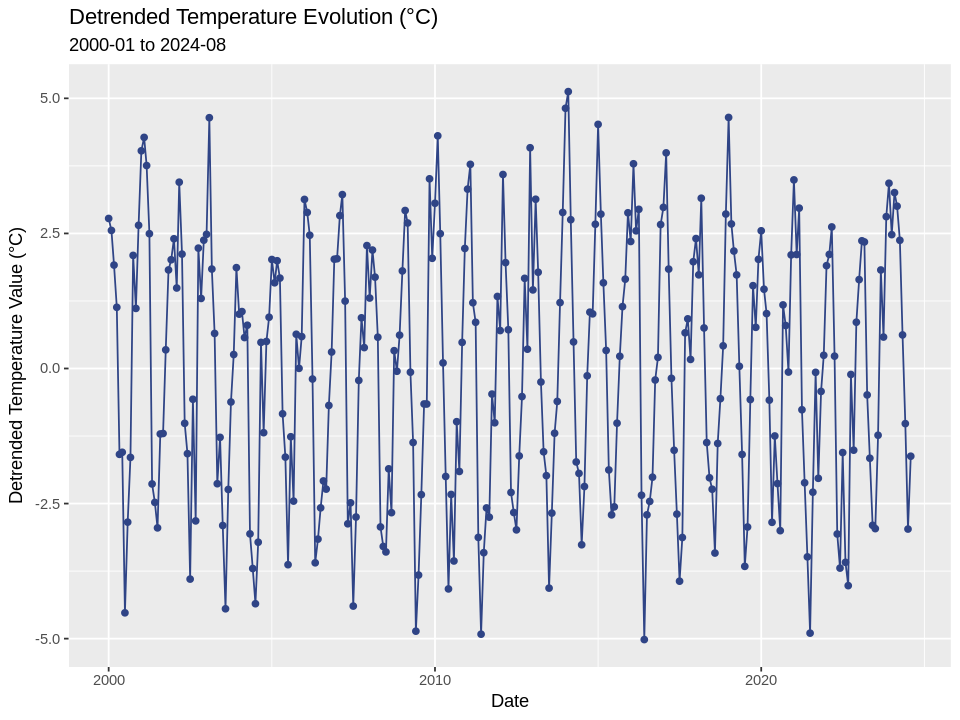

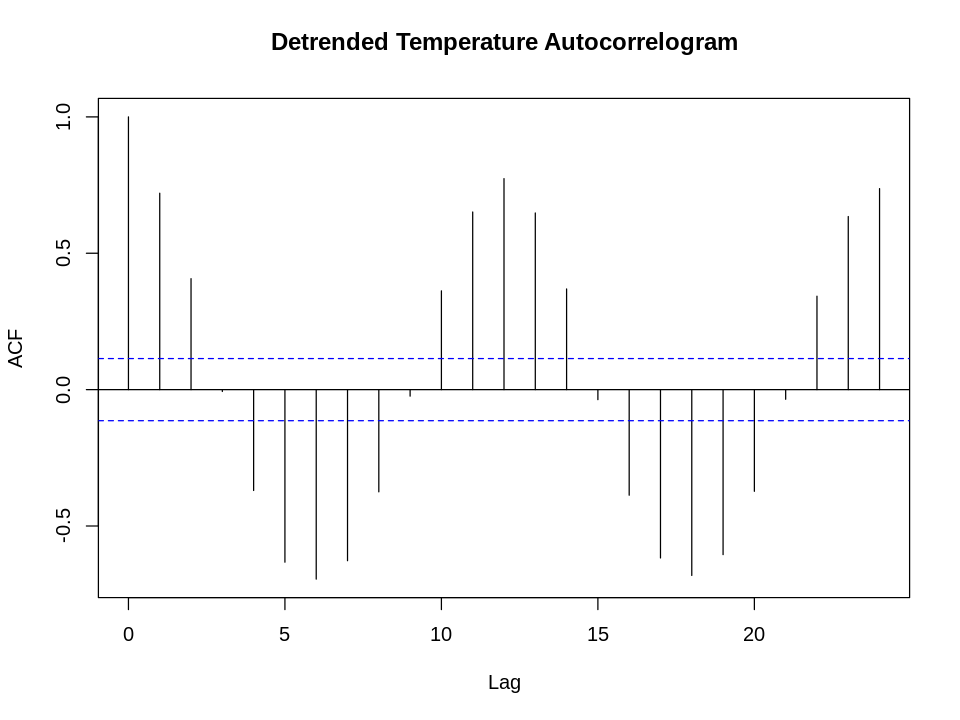

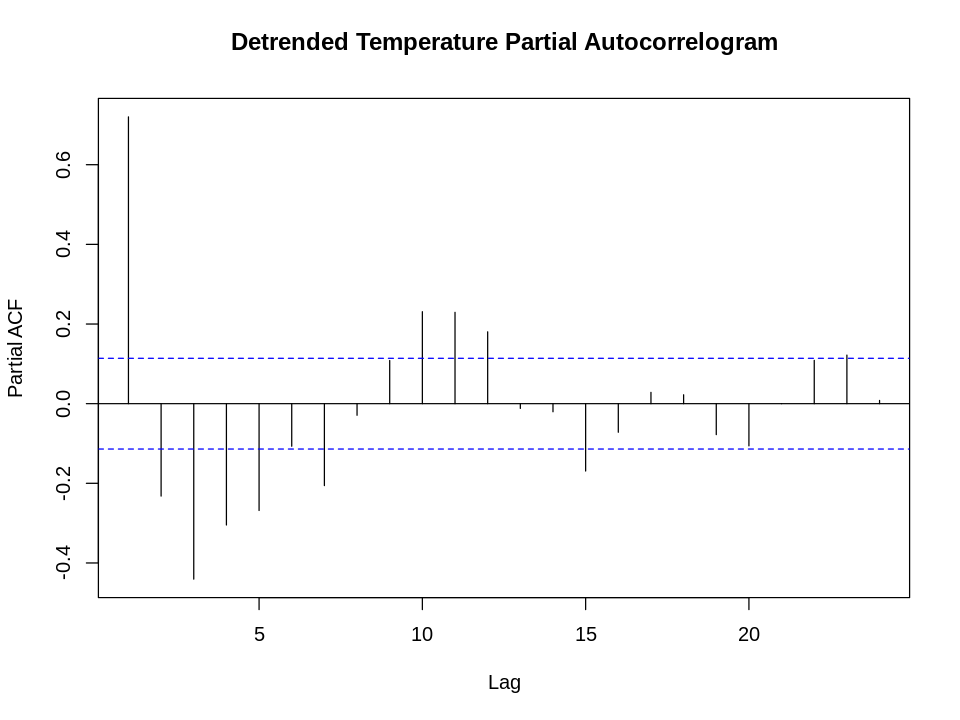

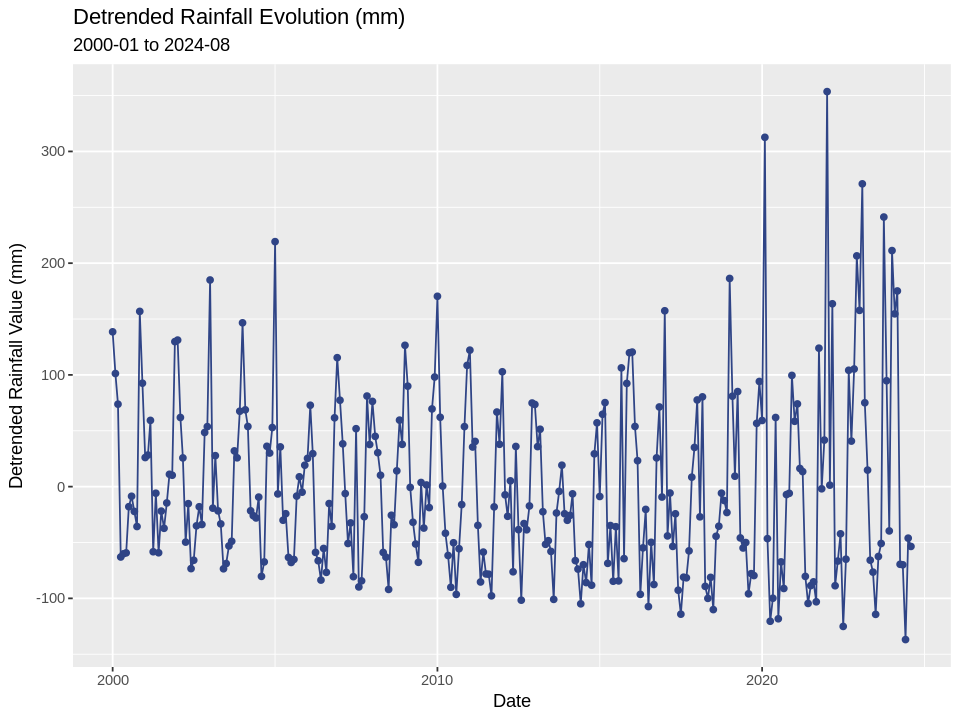

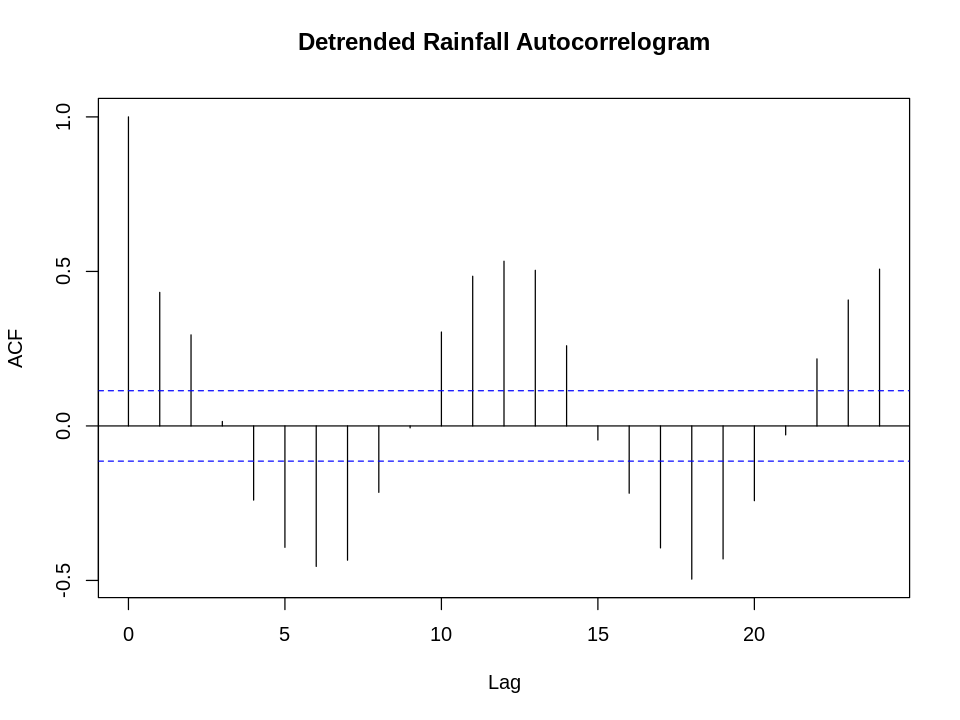

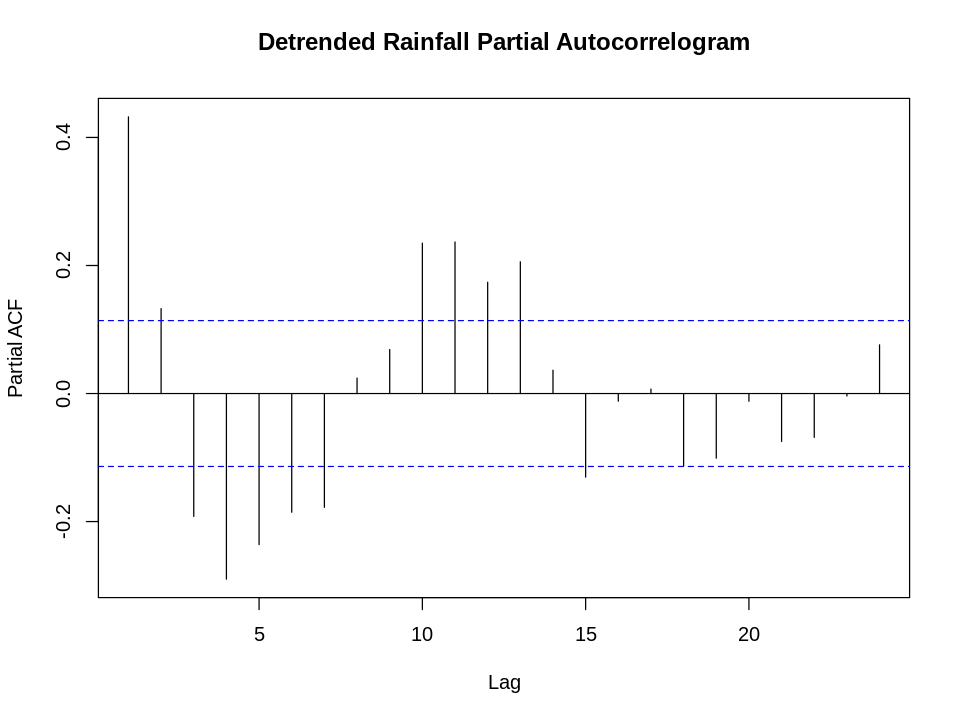

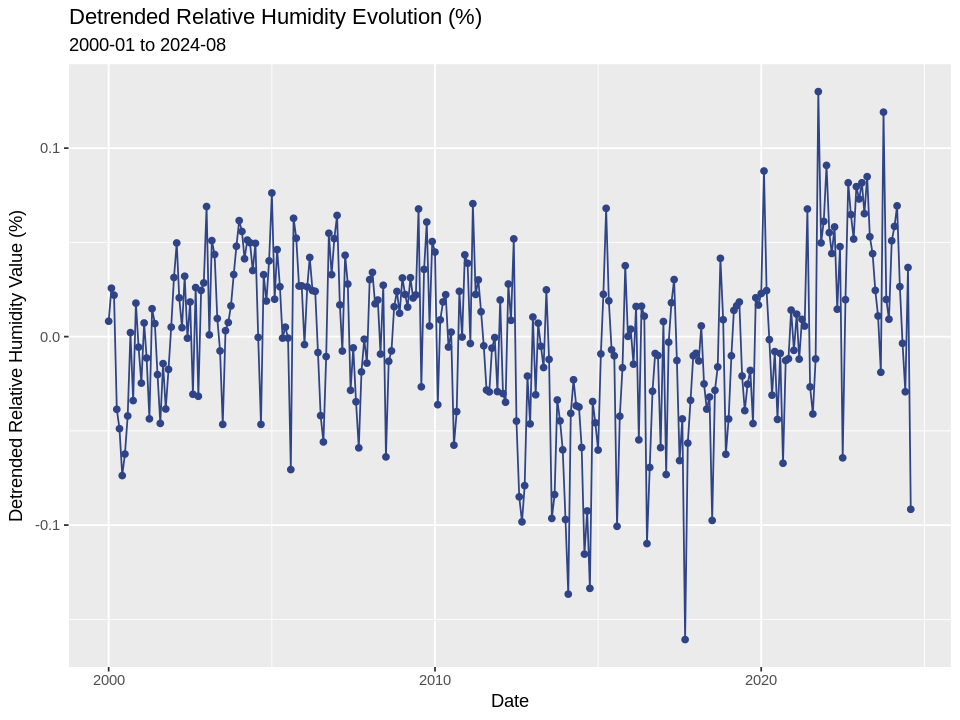

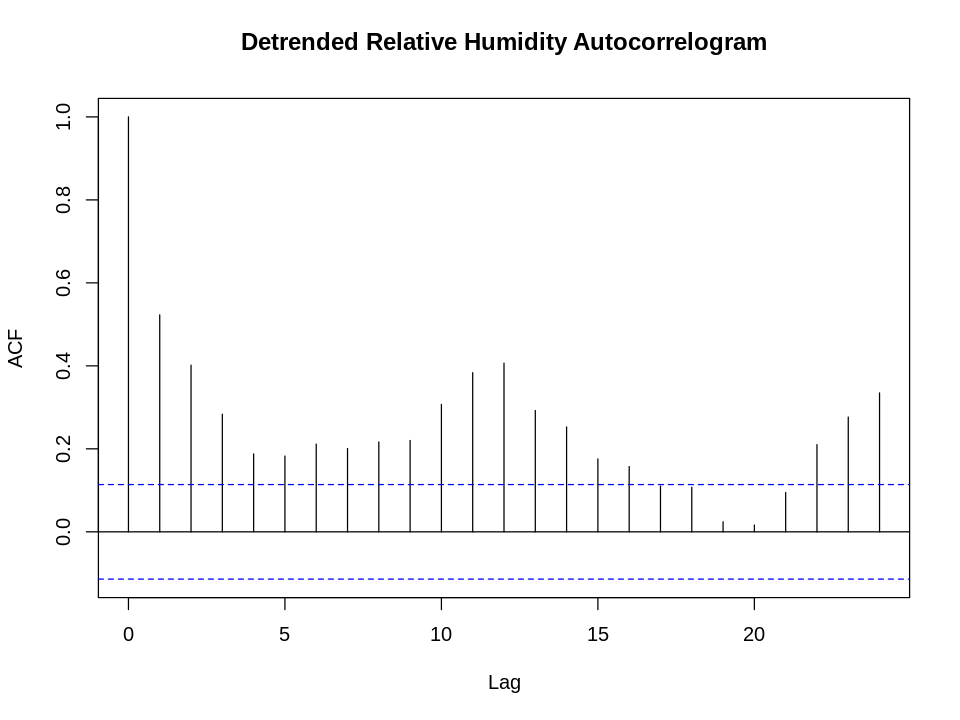

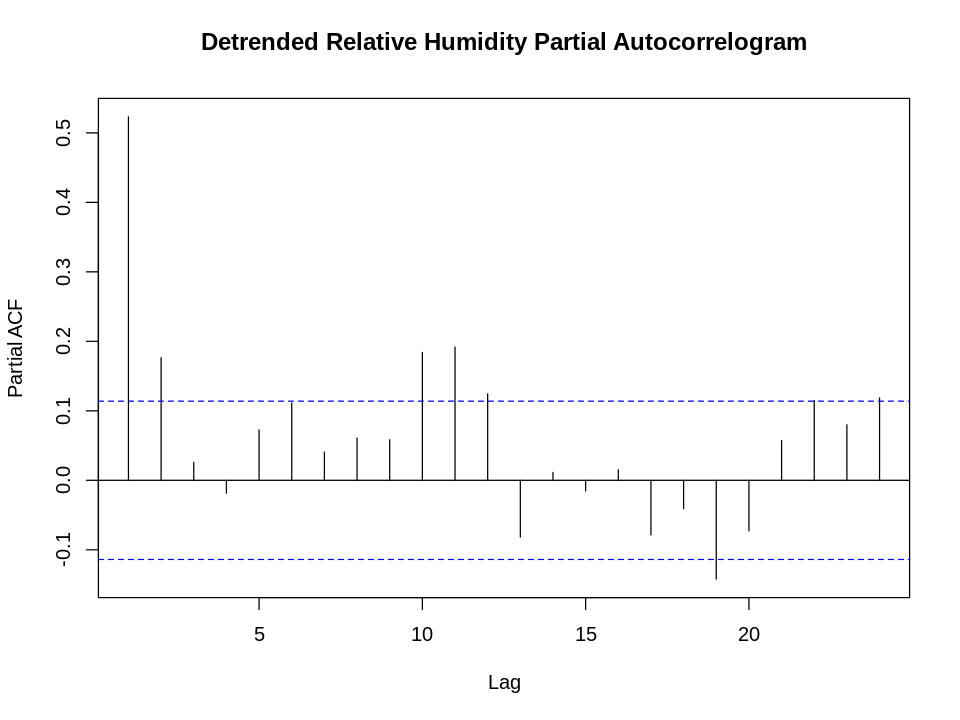

In [66]:
### Detrending par régression linéaire
# Ajuster la taille des graphiques dans le Notebook
options(repr.plot.width = 8, repr.plot.height = 6)

# Parcourir toutes les colonnes à partir de la troisième
for (col in colnames(df)[c(3:5)]) {

  # Extraire le nom de la variable et l'unité à partir du nom de la colonne
  parts <- unlist(strsplit(col, " \\(")) # Séparer par espace suivi de parenthèse ouvrante
  variable_name <- parts[1] # Partie avant la parenthèse
  unit <- ifelse(length(parts) > 1, gsub("\\)", "", parts[2]), "") # Supprimer la parenthèse fermante

  # Créer un DataFrame temporaire avec la date et la colonne courante
  df_temp <- df[, c("Date", col)]
  colnames(df_temp) <- c("date", "value")

  # Ajustement d'une régression pour retirer la tendance
  model_temp <- lm(df_temp$value ~ df_temp$date)

  # Extraction des résidus
  stationary_serie <- resid(model_temp)

  # Remplacement des valeurs dans le DataFrame
  df_temp$value	<- stationary_serie

  # Créer le graphique avec ggplot2
  p <- ggplot(data=df_temp, aes(x=date, y=value)) +
    geom_point(color='#2F4486') +
    geom_line(color='#2F4486') +
    xlab('Date') +
    ylab(paste("Detrended", variable_name, "Value", paste("(",unit,")",sep=""))) +
    labs(title=paste("Detrended", variable_name, "Evolution", paste("(",unit,")",sep="")),
         subtitle="2000-01 to 2024-08")
  # Affichage du graphique
  print(p)
  # Création de la représentation graphique de l'ACF
  acf_plot <- acf(df_temp$value, main = paste0('Detrended ', variable_name,' Autocorrelogram'))

  # Création de la représentation graphique du PACF
  pacf_plot <- pacf(df_temp$value, main = paste0('Detrended ', variable_name,' Partial Autocorrelogram'))
}

In [67]:
### Detrending par régression linéaire
# Ajuster la taille des graphiques dans le Notebook
options(repr.plot.width = 8, repr.plot.height = 6)

# Parcourir toutes les colonnes à partir de la troisième
for (col in colnames(df)[c(3:5)]) {

  # Extraire le nom de la variable et l'unité à partir du nom de la colonne
  parts <- unlist(strsplit(col, " \\(")) # Séparer par espace suivi de parenthèse ouvrante
  variable_name <- parts[1] # Partie avant la parenthèse
  unit <- ifelse(length(parts) > 1, gsub("\\)", "", parts[2]), "") # Supprimer la parenthèse fermante

  # Créer un DataFrame temporaire avec la date et la colonne courante
  df_temp <- df[, c("Date", col)]
  colnames(df_temp) <- c("date", "value")

  # Ajustement d'une régression pour retirer la tendance
  model_temp <- lm(df_temp$value ~ df_temp$date)

  # Extraction des résidus
  stationary_serie <- resid(model_temp)

  # Remplacement des valeurs dans le DataFrame
  df_temp$value	<- stationary_serie

  # Effectuer le test ADF (Augmented Dickey-Fuller) sur la variable
  adf_temp <- ur.df(y = df_temp$value, type = "trend", lag = 8, selectlags = "AIC")

  # Afficher les résultats du test ADF
  cat(paste("\n----------------------------------------------------------------------------------------------------------------------------------\n",
    "                                 ",
    "Test ADF avec constante et tendance déterministe pour : Detrended", variable_name,
    "\n----------------------------------------------------------------------------------------------------------------------------------\n"))
  #print(summary(adf_temp))

  # Récupération de la p-value du z-lag 1
  p_value <- adf_temp@teststat[1]
  crit <- adf_temp@cval[1,2]

  if (p_value < crit){
    print(paste0(p_value," < ",crit))
    print("On rejette H0. On procède à un test de significativé de la constante.")
    print(summary(adf_temp))
  }  else {
    print(paste0(p_value," > ",crit))
    print("On ne rejette pas H0. On procède à un test ADF avec constante.")
  }
}


----------------------------------------------------------------------------------------------------------------------------------
                                   Test ADF avec constante et tendance déterministe pour : Detrended Temperature 
----------------------------------------------------------------------------------------------------------------------------------
[1] "-7.53742019014387 < -3.42"
[1] "On rejette H0. On procède à un test de significativé de la constante."

############################################### 
# Augmented Dickey-Fuller Test Unit Root Test # 
############################################### 

Test regression trend 


Call:
lm(formula = z.diff ~ z.lag.1 + 1 + tt + z.diff.lag)

Residuals:
    Min      1Q  Median      3Q     Max 
-3.0070 -0.8250 -0.0146  0.8525  3.1768 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept) -0.0303551  0.1590263  -0.191 0.848759    
z.lag.1     -1.0099358  0.1339896  -7.537 6.91e-13 ***
tt      

***Test de significativité du coefficient de la tendance***

---
**Température**

On procède à un test de significativité du coefficient de la tendance.
$$
\text{Hypothèses : } \left\{
\begin{array}{ll}
H_0: & b = 0 \\
H_1: & b \neq 0
\end{array}
\right. \\
\\
\text{Statistique de test : } \quad t_{\hat{b}}=\frac{\hat{b}}{\hat{\sigma}}_{\hat{b}}
\\
\text{Règle de décision : }\quad |t_b|=0.191 < 1,96
$$

On ne rejette pas l'hypothèse nulle de non significativité de la tendance déterministe au seuil de 5%. On procède à un test ADF avec constante.

---

**Précipitations**

On procède à un test de significativité du coefficient de la tendance.
$$
\text{Hypothèses : } \left\{
\begin{array}{ll}
H_0: & b = 0 \\
H_1: & b \neq 0
\end{array}
\right. \\
\\
\text{Statistique de test : } \quad t_{\hat{b}}=\frac{\hat{b}}{\hat{\sigma}}_{\hat{b}}
\\
\text{Règle de décision : }\quad |t_b|=0.570 < 1,96
$$

On ne rejette pas l'hypothèse nulle de non significativité de la tendance déterministe au seuil de 5%. On procède à un test ADF avec constante.

---

**Humidité relative**

On procède à un test de significativité du coefficient de la tendance.
$$
\text{Hypothèses : } \left\{
\begin{array}{ll}
H_0: & b = 0 \\
H_1: & b \neq 0
\end{array}
\right. \\
\\
\text{Statistique de test : } \quad t_{\hat{b}}=\frac{\hat{b}}{\hat{\sigma}}_{\hat{b}}
\\
\text{Règle de décision : }\quad |t_b|=0.378 < 1,96
$$

On ne rejette pas l'hypothèse nulle de non significativité de la tendance déterministe au seuil de 5%. On procède à un test ADF avec constante.

In [68]:
### Detrending par régression linéaire
# Ajuster la taille des graphiques dans le Notebook
options(repr.plot.width = 8, repr.plot.height = 6)

# Parcourir toutes les colonnes à partir de la troisième
for (col in colnames(df)[c(3:5)]) {

  # Extraire le nom de la variable et l'unité à partir du nom de la colonne
  parts <- unlist(strsplit(col, " \\(")) # Séparer par espace suivi de parenthèse ouvrante
  variable_name <- parts[1] # Partie avant la parenthèse
  unit <- ifelse(length(parts) > 1, gsub("\\)", "", parts[2]), "") # Supprimer la parenthèse fermante

  # Créer un DataFrame temporaire avec la date et la colonne courante
  df_temp <- df[, c("Date", col)]
  colnames(df_temp) <- c("date", "value")

  # Ajustement d'une régression pour retirer la tendance
  model_temp <- lm(df_temp$value ~ df_temp$date)

  # Extraction des résidus
  stationary_serie <- resid(model_temp)

  # Remplacement des valeurs dans le DataFrame
  df_temp$value	<- stationary_serie

  # Effectuer le test ADF (Augmented Dickey-Fuller) sur la variable
  adf_temp <- ur.df(y = df_temp$value, type = "drift", lag = 8, selectlags = "AIC")

  # Afficher les résultats du test ADF
  cat(paste("\n----------------------------------------------------------------------------------------------------------------------------------\n",
    "                                 ",
    "Test ADF avec constante pour : Detrended", variable_name,
    "\n----------------------------------------------------------------------------------------------------------------------------------\n"))
  #print(summary(adf_temp))

  # Récupération de la p-value du z-lag 1
  p_value <- adf_temp@teststat[1]
  crit <- adf_temp@cval[1,2]

  if (p_value < crit){
    print(paste0(p_value," < ",crit))
    print("On rejette H0. On procède à un test de significativé du coefficient de la tendance.")
    print(summary(adf_temp))
  }  else {
    print(paste0(p_value," > ",crit))
    print("On ne rejette pas H0. On procède à un test ADF sans constante ni tendance déterministe.")
  }
}


----------------------------------------------------------------------------------------------------------------------------------
                                   Test ADF avec constante pour : Detrended Temperature 
----------------------------------------------------------------------------------------------------------------------------------
[1] "-7.54908865896762 < -2.87"
[1] "On rejette H0. On procède à un test de significativé du coefficient de la tendance."

############################################### 
# Augmented Dickey-Fuller Test Unit Root Test # 
############################################### 

Test regression drift 


Call:
lm(formula = z.diff ~ z.lag.1 + 1 + z.diff.lag)

Residuals:
     Min       1Q   Median       3Q      Max 
-2.98701 -0.83662 -0.02306  0.84326  3.15653 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) -0.003718   0.075953  -0.049 0.960992    
z.lag.1     -1.009693   0.133750  -7.549 6.36e-13 ***
z.diff.lag1  0.51

***Test de significativité de la constante***

---
**Température**

On procède à un test de significativité de la constante.
$$
\text{Hypothèses : } \left\{
\begin{array}{ll}
H_0: & c = 0 \\
H_1: & c \neq 0
\end{array}
\right. \\
\\
\text{Statistique de test : } \quad t_{\hat{c}}=\frac{\hat{c}}{\hat{\sigma}}_{\hat{c}}
\\
\text{Règle de décision : }\quad |t_c|=0.049 < 1,96
$$

On ne rejette pas l'hypothèse nulle de non significativité de la constante au seuil de 5%. On procède à un test ADF sans constante ni tendance déterministe.

---

**Précipitations**

On procède à un test de significativité de la constante.
$$
\text{Hypothèses : } \left\{
\begin{array}{ll}
H_0: & c = 0 \\
H_1: & c \neq 0
\end{array}
\right. \\
\\
\text{Statistique de test : } \quad t_{\hat{c}}=\frac{\hat{c}}{\hat{\sigma}}_{\hat{c}}
\\
\text{Règle de décision : }\quad |t_c|=0.077 < 1,96
$$

On ne rejette pas l'hypothèse nulle de non significativité de la constante au seuil de 5%. On procède à un test ADF sans constante ni tendance déterministe.

---

**Humidité relative**

On procède à un test de significativité de la constante.
$$
\text{Hypothèses : } \left\{
\begin{array}{ll}
H_0: & c = 0 \\
H_1: & c \neq 0
\end{array}
\right. \\
\\
\text{Statistique de test : } \quad t_{\hat{c}}=\frac{\hat{c}}{\hat{\sigma}}_{\hat{c}}
\\
\text{Règle de décision : }\quad |t_c|=0.060 < 1,96
$$

On ne rejette pas l'hypothèse nulle de non significativité de la constante au seuil de 5%. On procède à un test ADF sans constante ni tendance déterministe.

In [69]:
# Detrending par régression linéaire
# Ajuster la taille des graphiques dans le Notebook
options(repr.plot.width = 8, repr.plot.height = 6)

# Parcourir toutes les colonnes à partir de la troisième
for (col in colnames(df)[c(3:5)]) {

  # Extraire le nom de la variable et l'unité à partir du nom de la colonne
  parts <- unlist(strsplit(col, " \\(")) # Séparer par espace suivi de parenthèse ouvrante
  variable_name <- parts[1] # Partie avant la parenthèse
  unit <- ifelse(length(parts) > 1, gsub("\\)", "", parts[2]), "") # Supprimer la parenthèse fermante

  # Créer un DataFrame temporaire avec la date et la colonne courante
  df_temp <- df[, c("Date", col)]
  colnames(df_temp) <- c("date", "value")

  # Ajustement d'une régression pour retirer la tendance
  model_temp <- lm(df_temp$value ~ df_temp$date)

  # Extraction des résidus
  stationary_serie <- resid(model_temp)

  # Remplacement des valeurs dans le DataFrame
  df_temp$value	<- stationary_serie

  # Effectuer le test ADF (Augmented Dickey-Fuller) sur la variable
  adf_temp <- ur.df(y = df_temp$value, type = "none", lag = 8, selectlags = "AIC")

  # Afficher les résultats du test ADF
  cat(paste("\n----------------------------------------------------------------------------------------------------------------------------------\n",
    "                                 ",
    "Test ADF sans constante ni tendance déterministe pour : Detrended", variable_name,
    "\n----------------------------------------------------------------------------------------------------------------------------------\n"))
  #print(summary(adf_temp))

  # Récupération de la p-value du z-lag 1
  p_value <- adf_temp@teststat[1]
  crit <- adf_temp@cval[1,2]

  if (p_value < crit){
    print(paste0(p_value," < ",crit))
    print("On rejette H0. On ne rejette pas l'hypothèse de stationnarité. On confirme ce résultat avec des tests KPSS.")
    print(summary(adf_temp))
  }  else {
    print(paste0(p_value," > ",crit))
    print("On ne rejette pas H0. On rejette l'hypothèse de stationnarité. On confirme ce résultat avec des tests KPSS.")
  }
}


----------------------------------------------------------------------------------------------------------------------------------
                                   Test ADF sans constante ni tendance déterministe pour : Detrended Temperature 
----------------------------------------------------------------------------------------------------------------------------------
[1] "-7.56332972879605 < -1.95"
[1] "On rejette H0. On ne rejette pas l'hypothèse de stationnarité. On confirme ce résultat avec des tests KPSS."

############################################### 
# Augmented Dickey-Fuller Test Unit Root Test # 
############################################### 

Test regression none 


Call:
lm(formula = z.diff ~ z.lag.1 - 1 + z.diff.lag)

Residuals:
     Min       1Q   Median       3Q      Max 
-2.99077 -0.84043 -0.02676  0.83953  3.15280 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
z.lag.1     -1.00955    0.13348  -7.563 5.76e-13 ***
z.diff.lag1  0.51425    0

In [70]:
### Detrending par régression linéaire
# Ajuster la taille des graphiques dans le Notebook
options(repr.plot.width = 8, repr.plot.height = 6)

# Parcourir toutes les colonnes à partir de la troisième
for (col in colnames(df)[c(3:5)]) {

  # Extraire le nom de la variable et l'unité à partir du nom de la colonne
  parts <- unlist(strsplit(col, " \\(")) # Séparer par espace suivi de parenthèse ouvrante
  variable_name <- parts[1] # Partie avant la parenthèse
  unit <- ifelse(length(parts) > 1, gsub("\\)", "", parts[2]), "") # Supprimer la parenthèse fermante

  # Créer un DataFrame temporaire avec la date et la colonne courante
  df_temp <- df[, c("Date", col)]
  colnames(df_temp) <- c("date", "value")

  # Ajustement d'une régression pour retirer la tendance
  model_temp <- lm(df_temp$value ~ df_temp$date)

  # Extraction des résidus
  stationary_serie <- resid(model_temp)

  # Remplacement des valeurs dans le DataFrame
  df_temp$value	<- stationary_serie

  # Effectuer le test ADF (Augmented Dickey-Fuller) sur la variable
  kpss_temp <- ur.kpss(y = df_temp$value, type = "tau", lag = "long")

  # Afficher les résultats du test ADF
  cat(paste("\n-------------------------------------------------------------------------------------\n",
    "                                 ",
    variable_name,
    "\n-------------------------------------------------------------------------------------\n"))
  cat(paste("\n#######################\n",
  "Autour d'une tendance déterministe",
  "\n#######################\n"))
  print(summary(kpss_temp))



  # Récupération de la p-value du z-lag 1
  p_value <- kpss_temp@teststat
  crit <- kpss_temp@cval[4]

  if (p_value > crit){
    print(paste0(p_value," > ",crit))
    print("On rejette H0 au seuil 1%. On rejette l'hypothèse de stationnarité autour d'une tendance déterministe.")
  }  else {
    print(paste0(p_value," < ",crit))
    print("On ne rejette pas H0 au seuil 1%. On ne rejette pas l'hypothèse de stationnarité autour d'une tendance déterministe.")
  }


  # Effectuer le test ADF (Augmented Dickey-Fuller) sur la variable
  kpss_temp <- ur.kpss(y = df_temp$value, type = "tau", lag = "long")
  cat(paste("\n#######################\n",
  "Autour d'une constante",
  "\n#######################\n"))
  print(summary(kpss_temp))
  # Récupération de la p-value du z-lag 1
  p_value <- kpss_temp@teststat
  crit <- kpss_temp@cval[4]

  if (p_value > crit){
    print(paste0(p_value," > ",crit))
    print("On rejette H0 au seuil 1%. On rejette l'hypothèse de stationnarité autour d'une constante.")
  }  else {
    print(paste0(p_value," < ",crit))
    print("On ne rejette pas H0 au seuil 1%. On ne rejette pas l'hypothèse de stationnarité autour d'une constante.")
  }
}


-------------------------------------------------------------------------------------
                                   Temperature 
-------------------------------------------------------------------------------------

#######################
 Autour d'une tendance déterministe 
#######################

####################### 
# KPSS Unit Root Test # 
####################### 

Test is of type: tau with 15 lags. 

Value of test-statistic is: 0.0564 

Critical value for a significance level of: 
                10pct  5pct 2.5pct  1pct
critical values 0.119 0.146  0.176 0.216

[1] "0.0564467289675421 < 0.216"
[1] "On ne rejette pas H0 au seuil 1%. On ne rejette pas l'hypothèse de stationnarité autour d'une tendance déterministe."

#######################
 Autour d'une constante 
#######################

####################### 
# KPSS Unit Root Test # 
####################### 

Test is of type: tau with 15 lags. 

Value of test-statistic is: 0.0564 

Critical value for a significance

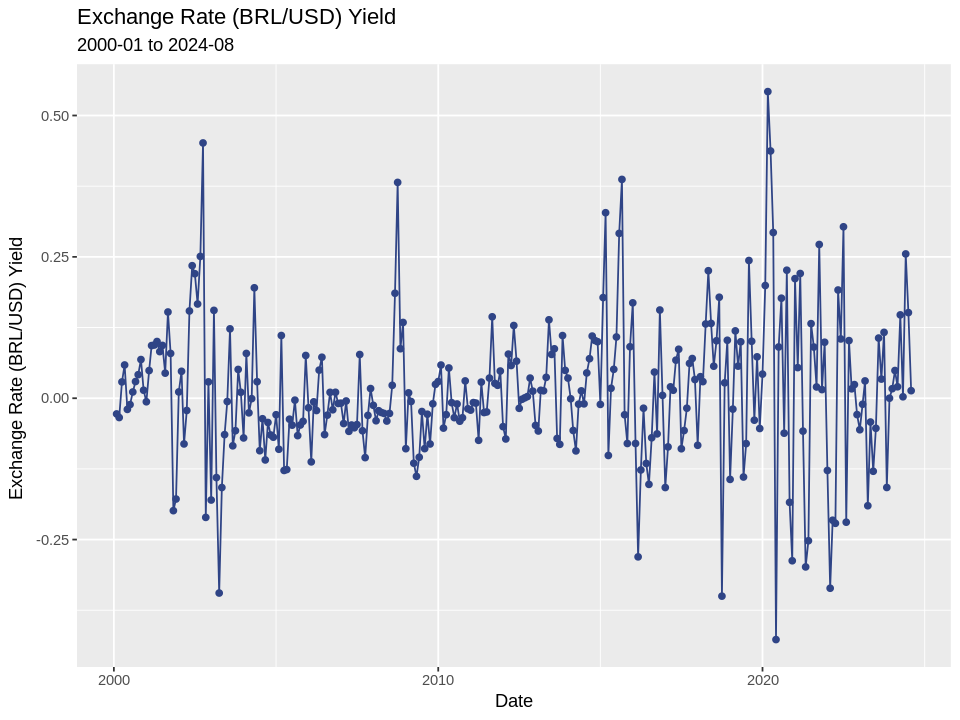

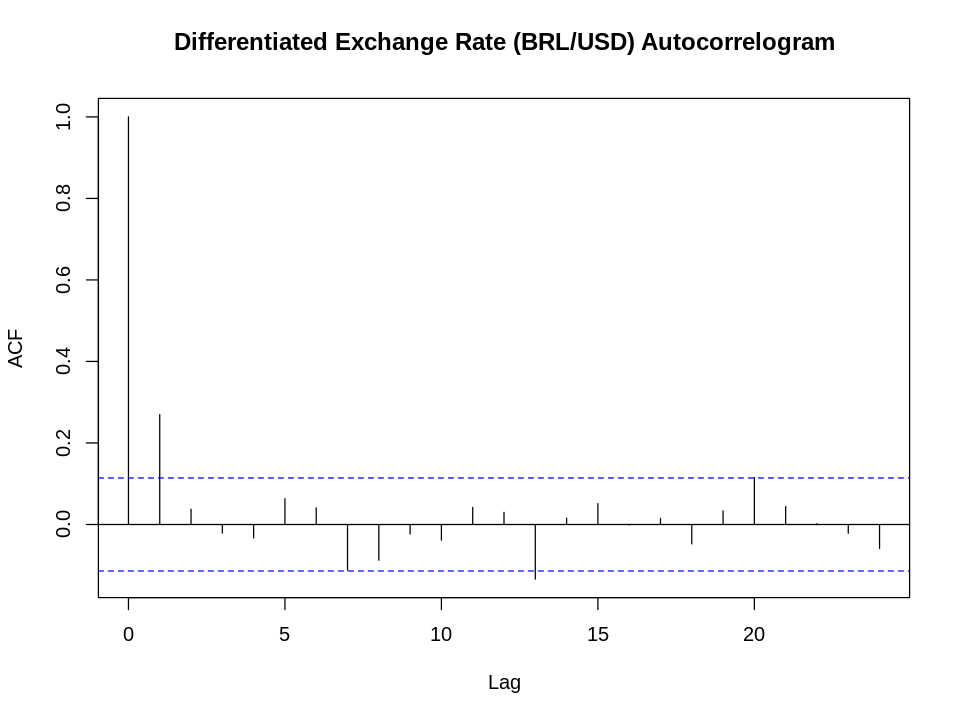

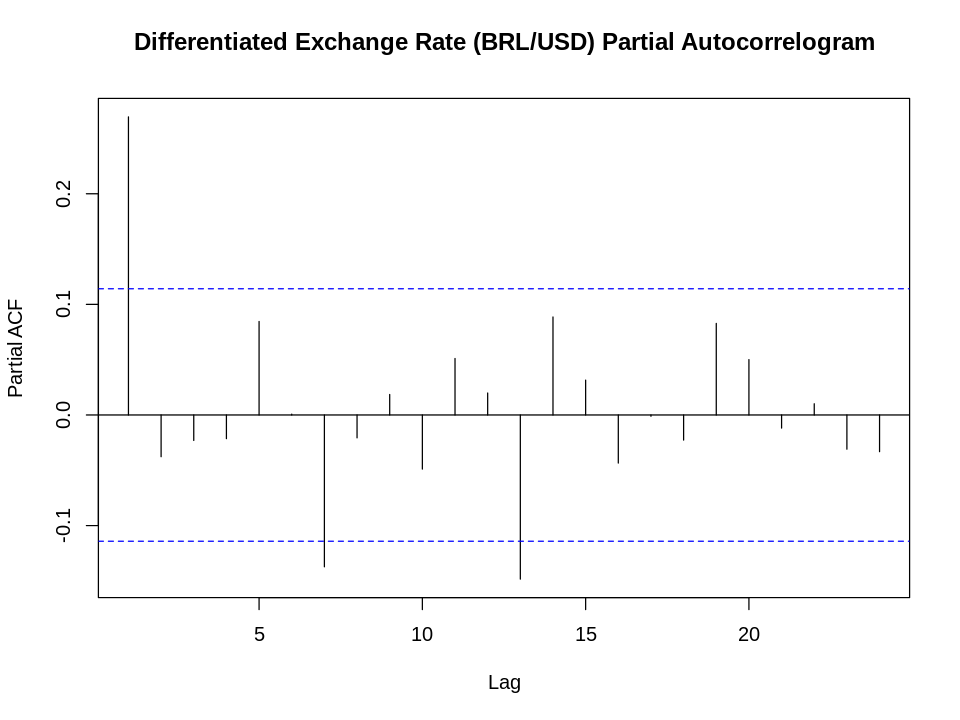

In [71]:
### Differentiation
# Création d'un DataFrame avec la date et les variations du taux de change
df_exchange_diff <- data.frame(date = df$"Date"[-1], exchange_yield = diff(df$"Exchange Rate (BRL/USD)"))

# Ajustement de la taille du graphique
options(repr.plot.width = 8, repr.plot.height = 6)

# Création du graphique avec ggplot2
p_exchange_diff <- ggplot(data=df_exchange_diff, aes(x=date, y=exchange_yield)) +
  geom_point(color='#2F4486') +
  geom_line(color='#2F4486') +
  xlab('Date') +
  ylab("Exchange Rate (BRL/USD) Yield ") +
  labs(title=paste("Exchange Rate (BRL/USD) Yield"),
        subtitle="2000-01 to 2024-08")

# Affichage du graphique
p_exchange_diff

# Ajustement de la taille du graphique
options(repr.plot.width = 8, repr.plot.height = 6)

# Création des graphiques ACF et PACF
acf(df_exchange_diff$exchange_yield, main = 'Differentiated Exchange Rate (BRL/USD) Autocorrelogram')
pacf(df_exchange_diff$exchange_yield, main = 'Differentiated Exchange Rate (BRL/USD) Partial Autocorrelogram')

##### Tests de stationnarité

In [72]:
adf_exchange_diff <- ur.df(y = df_exchange_diff$exchange_yield, type = c("trend"), lag = 8, selectlags = c('AIC'))
summary(adf_exchange_diff)

# Récupération de la p-value du z-lag 1
p_value <- adf_exchange_diff@teststat[1]
crit <- adf_exchange_diff@cval[1,2]

if (p_value < crit){
  print(paste0(p_value," < ", crit))
  print("On rejette H0 au seuil 5%. On ne rejette pas l'hypothèse de stationnarité avec constante et tendance déterministe. On procède à un test de significativité du coefficient de tendance déterministe.")
}  else {
  print(paste0(p_value," > ",crit))
  print("On ne rejette pas H0 au seuil 5%. On rejette l'hypothèse de stationnarité avec constante et tendance déterministe. On procède à un test ADF avec constante.")
}


############################################### 
# Augmented Dickey-Fuller Test Unit Root Test # 
############################################### 

Test regression trend 


Call:
lm(formula = z.diff ~ z.lag.1 + 1 + tt + z.diff.lag)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.50757 -0.05683 -0.00728  0.05826  0.47262 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept) -9.663e-04  1.529e-02  -0.063    0.950    
z.lag.1     -7.612e-01  7.206e-02 -10.563   <2e-16 ***
tt           7.064e-05  8.880e-05   0.795    0.427    
z.diff.lag   3.853e-02  5.961e-02   0.646    0.519    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.1237 on 282 degrees of freedom
Multiple R-squared:  0.3675,	Adjusted R-squared:  0.3608 
F-statistic: 54.62 on 3 and 282 DF,  p-value: < 2.2e-16


Value of test-statistic is: -10.563 37.1942 55.7913 

Critical values for test statistics: 
      1pct  5pct 10pct
tau3 -3.98 -3.42

[1] "-10.5630464846496 < -3.42"
[1] "On rejette H0 au seuil 5%. On ne rejette pas l'hypothèse de stationnarité avec constante et tendance déterministe. On procède à un test de significativité du coefficient de tendance déterministe."


On procède à un test de significativité du coefficient de la tendance.
$$
\text{Hypothèses : } \left\{
\begin{array}{ll}
H_0: & b = 0 \\
H_1: & b \neq 0
\end{array}
\right. \\
\\
\text{Statistique de test : } \quad t_{\hat{b}}=\frac{\hat{b}}{\hat{\sigma}}_{\hat{b}}
\\
\text{Règle de décision : }\quad |t_b|=0.795 < 1,96
$$

On ne rejette pas l'hypothèse nulle de non significativité de la tendance déterministe au seuil de 5%. On procède à un test ADF avec constante.

In [73]:
adf_exchange_diff <- ur.df(y = df_exchange_diff$exchange_yield, type = c("drift"), lag = 8, selectlags = c('AIC'))
summary(adf_exchange_diff)

# Récupération de la p-value du z-lag 1
p_value <- adf_exchange_diff@teststat[1]
crit <- adf_exchange_diff@cval[1,2]

if (p_value < crit){
  print(paste0(p_value," < ",crit))
  print("On rejette H0 au seuil 5%. On ne rejette pas l'hypothèse de stationnarité avec constante. On procède à un test de significativité de la constante.")
}  else {
  print(paste0(p_value," > ",crit))
  print("On ne rejette pas H0 au seuil 5%. On rejette l'hypothèse de stationnarité avec constante. On procède à un test ADF sans constante ni tendance déterministe.")
}


############################################### 
# Augmented Dickey-Fuller Test Unit Root Test # 
############################################### 

Test regression drift 


Call:
lm(formula = z.diff ~ z.lag.1 + 1 + z.diff.lag)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.50240 -0.05910 -0.00702  0.05467  0.47848 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept)  0.009685   0.007366   1.315    0.190    
z.lag.1     -0.757266   0.071846 -10.540   <2e-16 ***
z.diff.lag   0.036777   0.059530   0.618    0.537    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.1236 on 283 degrees of freedom
Multiple R-squared:  0.3661,	Adjusted R-squared:  0.3616 
F-statistic: 81.72 on 2 and 283 DF,  p-value: < 2.2e-16


Value of test-statistic is: -10.5401 55.5471 

Critical values for test statistics: 
      1pct  5pct 10pct
tau2 -3.44 -2.87 -2.57
phi1  6.47  4.61  3.79


[1] "-10.5401182549561 < -2.87"
[1] "On rejette H0 au seuil 5%. On ne rejette pas l'hypothèse de stationnarité avec constante. On procède à un test de significativité de la constante."


On procède à un test de significativité de la constante.
$$
\text{Hypothèses : } \left\{
\begin{array}{ll}
H_0: & c = 0 \\
H_1: & c \neq 0
\end{array}
\right. \\
\\
\text{Statistique de test : } \quad t_{\hat{c}}=\frac{\hat{c}}{\hat{\sigma}}_{\hat{c}}
\\
\text{Règle de décision : }\quad |t_c|=1.315 < 1,96
$$

On ne rejette pas l'hypothèse nulle de non significativité de la tendance déterministe au seuil de 5%. On procède à un test ADF sans constante ni tendance déterministe.

In [74]:
adf_exchange_diff <- ur.df(y = df_exchange_diff$exchange_yield, type = c("none"), lag = 8, selectlags = c('AIC'))
summary(adf_exchange_diff)

# Récupération de la p-value du z-lag 1
p_value <- adf_exchange_diff@teststat[1]
crit <- adf_exchange_diff@cval[1,2]

if (p_value < crit){
  print(paste0(p_value," < ",crit))
  print("On rejette H0 au seuil 5%. On ne rejette pas l'hypothèse de stationnarité. On effectue des tests KPSS pour confirmer ce résultat.")
}  else {
  print(paste0(p_value," > ",crit))
  print("On ne rejette pas H0 au seuil 5%. On rejette l'hypothèse de stationnarité. On effectue des tests KPSS pour confirmer ce résultat.")
}


############################################### 
# Augmented Dickey-Fuller Test Unit Root Test # 
############################################### 

Test regression none 


Call:
lm(formula = z.diff ~ z.lag.1 - 1 + z.diff.lag)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.49697 -0.04864  0.00277  0.06483  0.48672 

Coefficients:
           Estimate Std. Error t value Pr(>|t|)    
z.lag.1    -0.74554    0.07138 -10.444   <2e-16 ***
z.diff.lag  0.03107    0.05945   0.523    0.602    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.1238 on 284 degrees of freedom
Multiple R-squared:  0.3622,	Adjusted R-squared:  0.3577 
F-statistic: 80.65 on 2 and 284 DF,  p-value: < 2.2e-16


Value of test-statistic is: -10.4444 

Critical values for test statistics: 
      1pct  5pct 10pct
tau1 -2.58 -1.95 -1.62


[1] "-10.4444151810834 < -1.95"
[1] "On rejette H0 au seuil 5%. On ne rejette pas l'hypothèse de stationnarité. On effectue des tests KPSS pour confirmer ce résultat."


In [75]:
kpss_exchange_diff <- ur.kpss(y = df_exchange_diff$exchange_yield, type = "tau", lags = "long")
summary(kpss_exchange_diff)

# Récupération de la p-value du z-lag 1
p_value <- kpss_exchange_diff@teststat
crit <- kpss_exchange_diff@cval[1,2]

if (p_value > crit){
  print(paste0(p_value," > ",crit))
  print("On rejette H0 au seuil 5%. On rejette l'hypothèse de stationnarité autour d'une tendance déterministe.")
}  else {
  print(paste0(p_value," < ", crit))
  print("On ne rejette pas H0 au seuil 5%. On ne rejette pas l'hypothèse de stationnarité autour d'une tendance déterministe.")
}


####################### 
# KPSS Unit Root Test # 
####################### 

Test is of type: tau with 15 lags. 

Value of test-statistic is: 0.069 

Critical value for a significance level of: 
                10pct  5pct 2.5pct  1pct
critical values 0.119 0.146  0.176 0.216


[1] "0.0689927120635644 < 0.146"
[1] "On ne rejette pas H0 au seuil 5%. On ne rejette pas l'hypothèse de stationnarité autour d'une tendance déterministe."


In [76]:
kpss_exchange_diff <- ur.kpss(y = df_exchange_diff$exchange_yield, type = "mu", lags = "long")
summary(kpss_exchange_diff)

# Récupération de la p-value du z-lag 1
p_value <- kpss_exchange_diff@teststat
crit <- kpss_exchange_diff@cval[1,2]

if (p_value > crit){
  print(paste0(p_value," > ",crit))
  print("On rejette H0 au seuil 5%. On rejette l'hypothèse de stationnarité autour d'une constante.")
}  else {
  print(paste0(p_value," < ",crit))
  print("On ne rejette pas H0 au seuil 5%. On ne rejette pas l'hypothèse de stationnarité autour d'une constante.")
}


####################### 
# KPSS Unit Root Test # 
####################### 

Test is of type: mu with 15 lags. 

Value of test-statistic is: 0.1728 

Critical value for a significance level of: 
                10pct  5pct 2.5pct  1pct
critical values 0.347 0.463  0.574 0.739


[1] "0.172833526144744 < 0.463"
[1] "On ne rejette pas H0 au seuil 5%. On ne rejette pas l'hypothèse de stationnarité autour d'une constante."


#### B.3 Conclusion de la stationnarité
*   Température : stationnaire avec constante et tendance déterministe <= detrending
*   Précipitations : stationnaire avec constante et tendance déterministe <= detrending
*   Humidité : stationnaire avec constante et tendance déterministe <= detrending
*   Taux de change : DS sans constante ni tendance déterministe <= differentiated






### C &emsp; Comparaison avec un autre modèle

Pour évaluer les performances du modèle obtenu en 2.3, on propose de le comparer avec le modèle qui minimise l'AIC.

In [49]:
### Fonction pour calculer l'AIC d'un modèle ARIMA
calcul_AIC <- function(p, q, data) {
  model <- Arima(y = data, order = c(p, 0, q))
  return(AIC(model))
}

# Plage de valeurs pour p et q
p_values <- 0:5
q_values <- 0:5

# Initialisation d'un tableau pour stocker les résultats
results <- data.frame(p = numeric(), q = numeric(), AIC = numeric())

# Double boucle pour tester toutes les combinaisons de p et q
for (p in p_values) {
  for (q in q_values) {
    AIC_value <- calcul_AIC(p, q, df_sugar_price_diff$sugar_price_yield[1:292])
    results <- rbind(results, data.frame(p = p, q = q, AIC = AIC_value))
  }
}

# Trouver le modèle avec le plus petit AIC
best_model <- results[which.min(results$AIC),]
print(best_model)

### Estimation du modèle minimisant l'AIC
arima_aic_model <- Arima(y = df_sugar_price_diff$sugar_price_yield[1:292], order = c(1, 0, 2))

# Affichage de l'estimation
summary(arima_aic_model)

# Test de siginificativité des coefficients
coeftest(arima_aic_model)

# Calcul des prévisions
forecast_arima_aic_model<-forecast(arima_aic_model,h=3,level=95)
forecast_arima_aic_model

  p q       AIC
9 1 2 -1740.947


Series: df_sugar_price_diff$sugar_price_yield[1:292] 
ARIMA(1,0,2) with non-zero mean 

Coefficients:
         ar1      ma1      ma2   mean
      0.9466  -0.5973  -0.4027  4e-04
s.e.  0.0206   0.0557   0.0548  2e-04

sigma^2 = 0.0001465:  log likelihood = 875.47
AIC=-1740.95   AICc=-1740.74   BIC=-1722.56

Training set error measures:
                       ME       RMSE        MAE      MPE     MAPE     MASE
Training set 0.0002844206 0.01202036 0.00848181 106.8169 145.1613 0.796093
                    ACF1
Training set 0.003910187


z test of coefficients:

             Estimate  Std. Error  z value  Pr(>|z|)    
ar1        0.94658256  0.02059857  45.9538 < 2.2e-16 ***
ma1       -0.59733420  0.05573562 -10.7173 < 2.2e-16 ***
ma2       -0.40266524  0.05481562  -7.3458 2.045e-13 ***
intercept  0.00040338  0.00019248   2.0957   0.03611 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


    Point Forecast       Lo 95      Hi 95
293   -0.005195666 -0.02895420 0.01856287
294    0.001533707 -0.02365584 0.02672325
295    0.001473328 -0.02376776 0.02671442

##### ***Analyse des racines***
On représente les inverses des racines dans le cercle unitaire. La condition de stationnarité impose que ces inverses doivent être de module strictement inférieur à 1, c'est-à-dire dans le cercle unitaire.

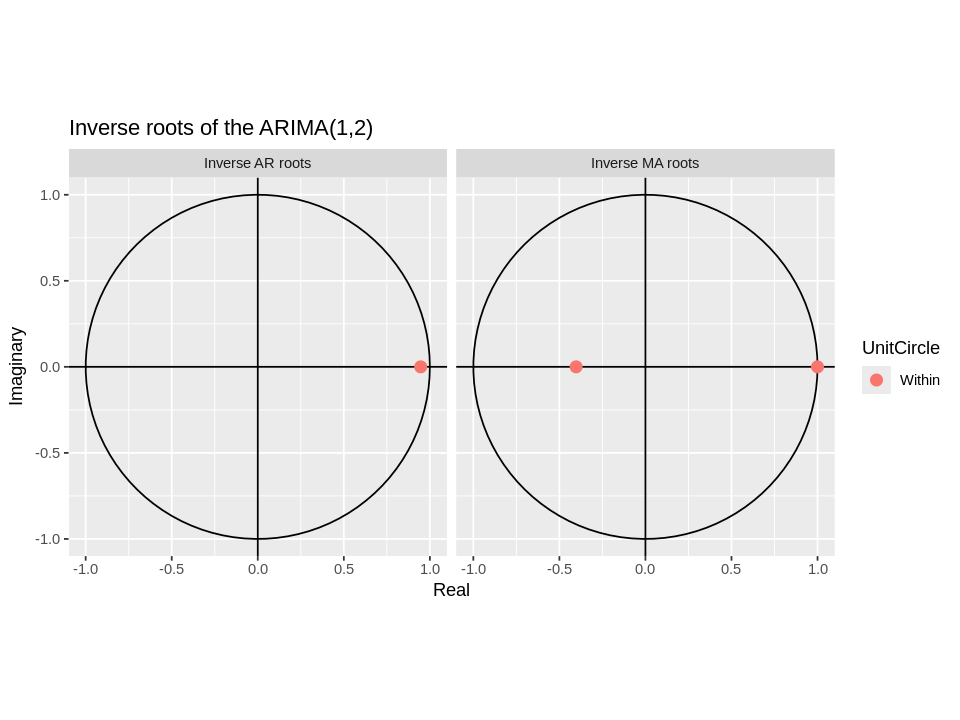

In [78]:
# Ajustement de la taille du graphique
options(repr.plot.width = 8, repr.plot.height = 6)

# Visualisation des racines dans le cercle unitaire
autoplot(arima_aic_model,main="Inverse roots of the ARIMA(1,2)")

 La condition de stationnarité est donc satisfaite.

##### **Test sur les résidus**

###### *Test d'absence d'autocorrélation*

On teste l'absence d'autocorrélation des résidus jusqu'à l'ordre 10.
$$
\begin{align*}
\text{Hypothèses : }& \left\{
\begin{array}{ll}
H_0: & \rho(1) = \rho(2) = \cdots = \rho(10) = 0 \\
H_1: & \exists i \in \{1, \cdots, 10\} \text{ tel que } \rho(i) \neq 0
\end{array}
\right.
\\
\text{Statistique de test : }& \quad Q^*(10) ∼ \chi²(7)
\\
\text{Règle de décision : }&
\quad Q^*(10) = 3.9414 < 14.067 = Q^*(10)_{0.95}
\end{align*}
$$

$Q^*(10) = 3.9414$  est inférieure au seuil critique de 5%. On ne rejette pas l'hypothèse nulle d'absence d'autocorrélation des résidus.


	Ljung-Box test

data:  Residuals from ARIMA(1,0,2) with non-zero mean
Q* = 3.9414, df = 7, p-value = 0.7865

Model df: 3.   Total lags used: 10



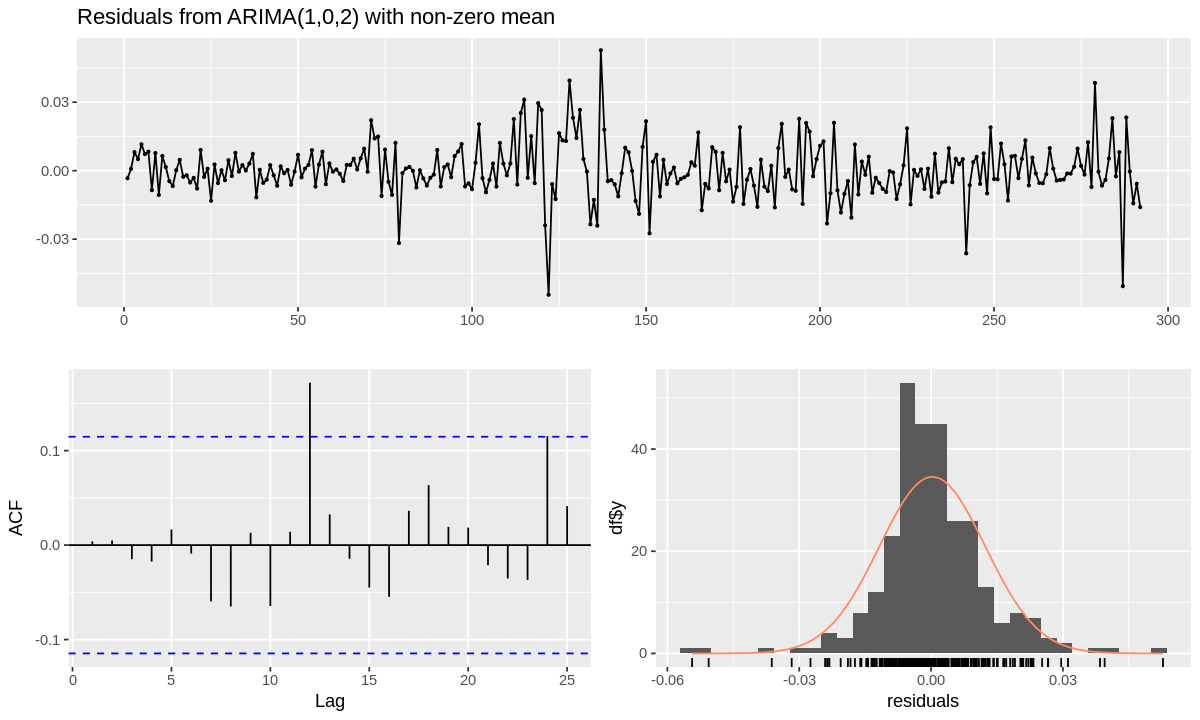

In [79]:
# Ajustement de la taille du graphique
options(repr.plot.width = 10, repr.plot.height = 6)

test_resarima_aic_model<-checkresiduals(arima_aic_model,lag = 10)

###### *Test de l'hypothèse de normalité des résidus : Test de Jarque & Bera*
$$
\begin{align*}
\text{Hypothèses : }& \left\{
\begin{array}{ll}
H_0 : S(X) = 0 \ \text{et} \ K(X) = 3 \\
H_1 : S(X) \neq 0 \ \text{ou} \ K(X) \neq 3
\end{array}
\right.
\\
\text{Statistique de test : }& \quad JB_{stat} ∼ \chi²(2)
\end{align*}
$$

In [80]:
which(arima_aic_model$residuals==min(arima_aic_model$residuals))
which(arima_aic_model$residuals==max(arima_aic_model$residuals))

[1] 122

[1] 137

[1] "Skewness des residus : -0.249463"

[1] "kurtosis des residus : 6.179375"

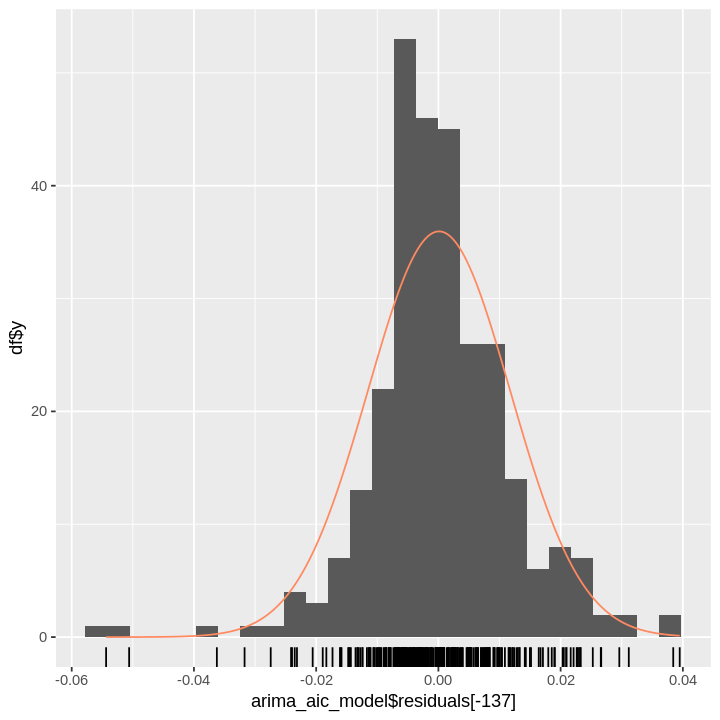

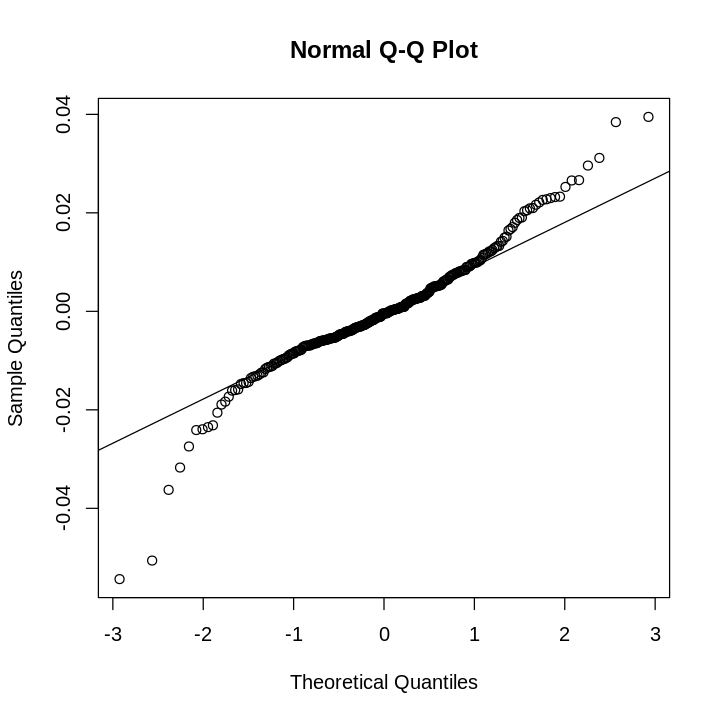

In [81]:
# Ajustement de la taille du graphique
options(repr.plot.width = 6, repr.plot.height = 6)

gghistogram(arima_aic_model$residuals[-137], add.normal = TRUE)
sprintf("Skewness des residus : %f",skewness(arima_aic_model$residuals[-137]))
sprintf("kurtosis des residus : %f",kurtosis(arima_aic_model$residuals[-137]))
qqnorm(arima_aic_model$residuals[-137])
qqline(arima_aic_model$residuals[-137])

Le skewness mesure l'asymétrie d'une distribution. Ici, le skewness négatif indique que la distribution est plus étirée vers la gauche qu'une loi normale, en d'autres termes, il y a plus de valeurs extrêmes négatives.

Le kurtosis mesure l'aplatissement d'une distribution par rapport à une distribution normale. La valeur du kurtosis pour une distribution normale est de 3. Le kurtosis des résidus est de 6.179375 ce qui est bien supérieure à la valeur du kurtosis pour une distribution normale. Cela veut dire que notre distribution est plus pointue qu'une distribution normale.

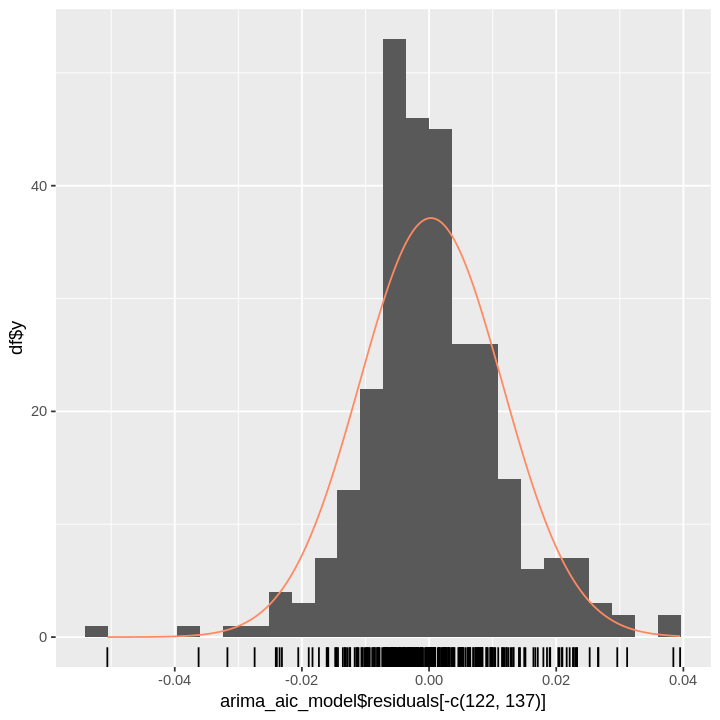

In [82]:
gghistogram(arima_aic_model$residuals[-c(122,137)], add.normal = TRUE)

On constate quelques différences entre les deux histogrammes ce qui permet de supposer que les résidus ne suivent pas une loi normale. On vérifie cette hypothèse par un test de Jarque Bera.

In [83]:
jarque.bera.test(arima_aic_model$residuals[-c(137)])


	Jarque Bera Test

data:  arima_aic_model$residuals[-c(137)]
X-squared = 125.58, df = 2, p-value < 2.2e-16


$$
\text{Règle de décision : } \quad JB_{stat} = 125.58 >\chi^2_{0.95}(2) = 5,99
$$

La statistique du test de Jarque et Bera est supérieure au seuil critique de 5%. De ce fait, on rejette l’hypothèse nulle d’une distribution normale des résidus. La distribution des résidus ne suit pas une loi normale.

###### *Test d'absence d'effet ARCH*
On teste l'hypothèse d'absence d'effet ARCH avec quatre retards. La régression estimée est :
$$
\hat{\epsilon}_{t}^{2}= \gamma_{0} + \gamma_{1} \hat{\epsilon}_{t-1}^{2} +\gamma_{2} \hat{\epsilon}_{t-2}^{2} +\gamma_{3} \hat{\epsilon}_{t-3}^{2} +\gamma_{4} \hat{\epsilon}_{t-4}^{2} + v_{t} \\
$$

$$
\begin{align*}
\text{Hypothèses : }& \left\{
\begin{array}{ll}
H_{0} : \gamma_{1}=...=\gamma_{4}=0 \rightarrow \text{pas d'effet ARCH}\\
H_{a} : \gamma_{1}\neq 0 \space \text{ou} \,... \gamma_{4} \neq 0 \rightarrow \text{effet ARCH}
\end{array}
\right.
\\
\text{Statistique de test : }& \quad ARCH_{LM} ∼ \chi²(2)
\end{align*}
$$

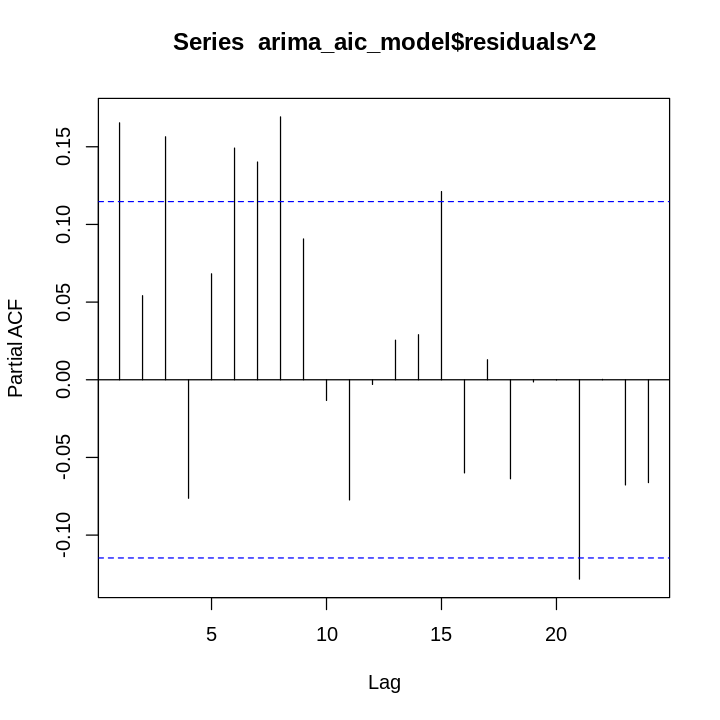

In [84]:
pacf(arima_aic_model$residuals^2)

In [85]:
ArchTest(arima_aic_model$residuals,lags=4,demean = FALSE)


	ARCH LM-test; Null hypothesis: no ARCH effects

data:  arima_aic_model$residuals
Chi-squared = 17.024, df = 4, p-value = 0.001912


$$
\text{Règle de décision : }
\quad ARCH_{LM} = 17.024 > 9,488 = \chi²^*(4)_{0.95}
$$

La statistique de test est supérieure au seuils critique de 5%. On rejette l'hypothèse nulle d'absence d'effet ARCH pour les résidus : il y a une  hétéroscédasticité conditionnelle dans les résidus.

Cela indique que la variance des résidus n'est pas constante, mais dépend des valeurs passées des résidus au carré.

##### Prévision

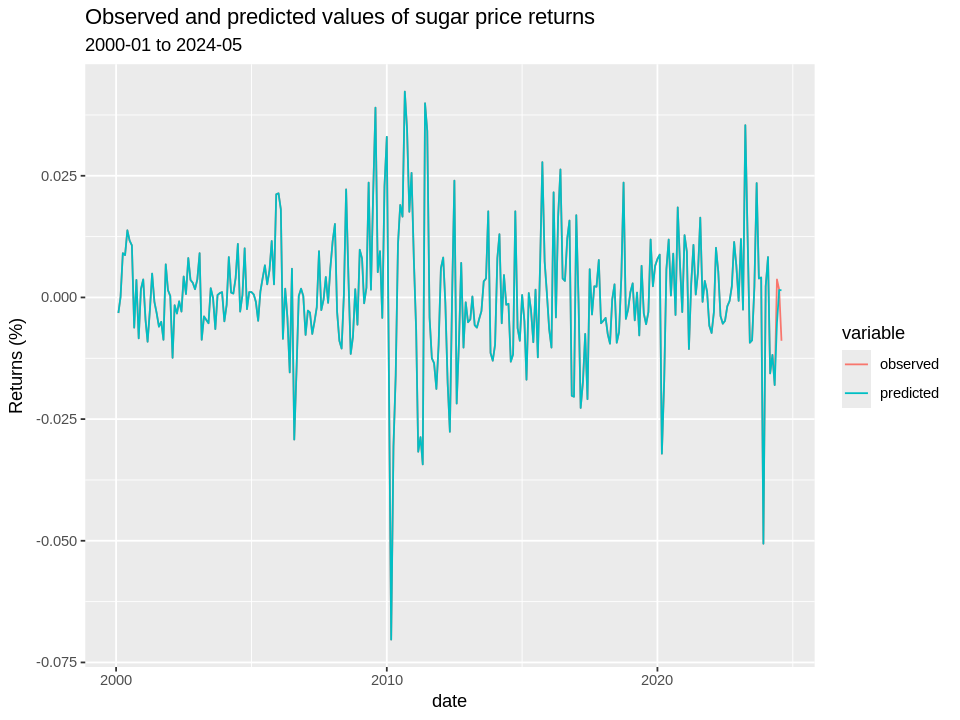

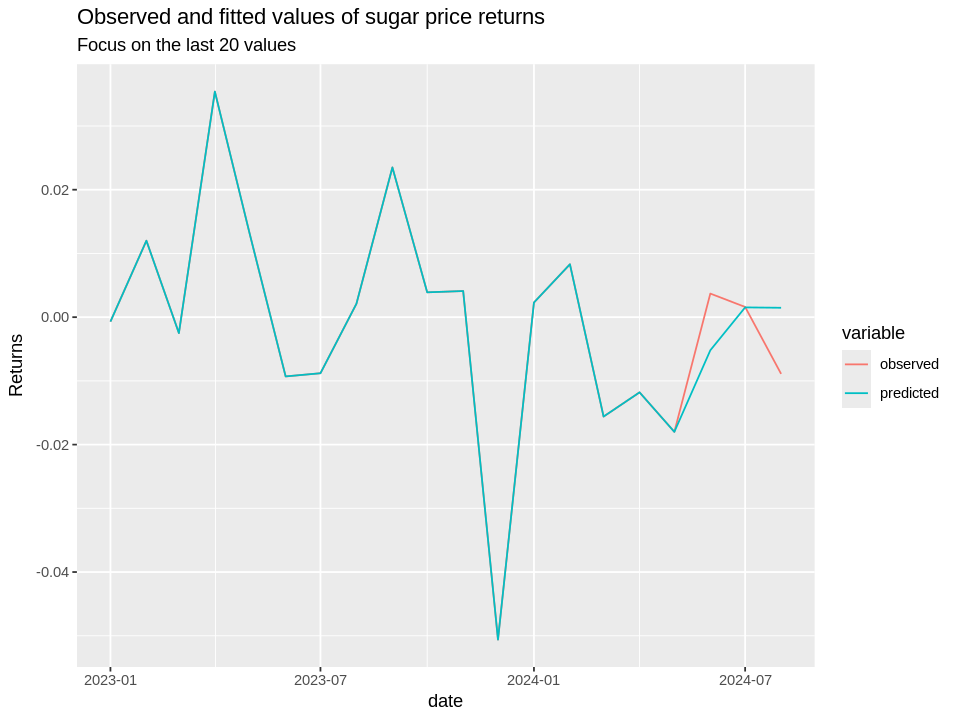

In [50]:
### Graphique principal
# Fusionner les données (date, rendement observé) avec les prévisions du modèle ARIMA
df_forecast <- cbind.data.frame(df_sugar_price_diff$date,df_sugar_price_diff$sugar_price_yield,c(df_sugar_price_diff$sugar_price_yield[1:292],as.matrix(forecast_arima_aic_model$mean)))

# Attribuer des noms de colonnes au dataframe fusionné
colnames(df_forecast)<-c("date","observed","predicted")

# Préparation des données pour ggplot
data_F_melt=melt(as.data.frame(df_forecast),id.vars = 1)

# Ajouter des labels au graphique
p_forecast <-ggplot(data=data_F_melt,aes(x=date))+geom_line(aes(x=date,y=value,color= variable))
p_forecast+labs(y="Returns (%)",title = "Observed and predicted values of sugar price returns",
            subtitle = "2000-01 to 2024-05")

### Graphique zoomé
# Garder uniquement les 20 dernières valeurs
df_forecast_last20 <- df_forecast [(nrow(df_forecast )-19):nrow(df_forecast ), ]

# Transformer pour ggplot
data_F_melt_last20 <- melt(as.data.frame(df_forecast_last20), id.vars = 1)

# Tracer les données zoomées
p_forecast_last20 <- ggplot(data = data_F_melt_last20, aes(x = date)) +
  geom_line(aes(y = value, color = variable)) +
  labs(
    y = "Returns",
    title = "Observed and fitted values of sugar price returns",
    subtitle = "Focus on the last 20 values"
  )

# Afficher le graphique
print(p_forecast_last20)

In [53]:
var.1lag <-VAR(y = df_stationary_data[,c(2, 3, 4, 5, 6, 7)],type="const",lag.max = 1)
summary(var.1lag) #Affichage des résultats avec summary


VAR Estimation Results:
Endogenous variables: Sugar.Price.Returns, Temperature, Rainfall, Relative.Humidity, Oil.Price.Returns, Exchange.Rate.Returns 
Deterministic variables: const 
Sample size: 294 
Log Likelihood: -1352.233 
Roots of the characteristic polynomial:
0.6571 0.6571 0.4079 0.3203 0.1811 0.03061
Call:
VAR(y = df_stationary_data[, c(2, 3, 4, 5, 6, 7)], type = "const", 
    lag.max = 1)


Estimation results for equation Sugar.Price.Returns: 
Sugar.Price.Returns = Sugar.Price.Returns.l1 + Temperature.l1 + Rainfall.l1 + Relative.Humidity.l1 + Oil.Price.Returns.l1 + Exchange.Rate.Returns.l1 + const 

                           Estimate Std. Error t value Pr(>|t|)    
Sugar.Price.Returns.l1    3.218e-01  5.837e-02   5.513 7.87e-08 ***
Temperature.l1           -5.337e-04  3.867e-04  -1.380    0.169    
Rainfall.l1              -1.702e-05  1.332e-05  -1.278    0.202    
Relative.Humidity.l1      1.151e-02  2.007e-02   0.574    0.567    
Oil.Price.Returns.l1      1.778e-05  1.231

##### **Résumé des résultats**

* **Équation pour `Sugar Price Returns`**
    * Le coefficient de `Sugar.Price.Returns.l1` est positif et significatif pour un risque de première espèce de 1\% : les variations des prix du sucre montrent une dépendance par rapport à leur valeur retardée.
    * Les coefficients des autres variables explicatives (Température, Précipitations, Humidité relative, Retours des prix du pétrole, Retours des taux de change) ne sont pas significatifs.
    * La constante n’est pas significative.
    * Le R² ajusté est égal à 11,43\%.

* **Équation pour `Temperature`**
    * Le coefficient de `Temperature.l1` est positif et significatif pour un risque de première espèce de 0,1\% : la température est fortement influencée par sa propre valeur retardée.
    * Le coefficient de `Rainfall.l1` est positif et significatif pour un risque de première espèce de 1\%, indiquant une corrélation directe entre les précipitations retardées et la température.
    * Le coefficient de `Relative.Humidity.l1` est négatif et significatif pour un risque de première espèce de 1\%, montrant une relation inverse avec l'humidité relative retardée.
    * Les autres variables explicatives ne sont pas significatives.
    * Le R² ajusté est égal à 61,52\%.

* **Équation pour `Rainfall`**
    * Le coefficient de `Sugar.Price.Returns.l1` est positif et significatif pour un risque de première espèce de 5\%, indiquant une relation entre les retours des prix du sucre et les précipitations.
    * Le coefficient de `Temperature.l1` est positif et significatif pour un risque de première espèce de 1\%.
    * Le coefficient de `Rainfall.l1` est significatif pour un risque de première espèce de 1\%, montrant une autocorrélation des précipitations.
    * Les autres variables explicatives ne sont pas significatives.
    * Le R² ajusté est égal à 24,80\%.

* **Équation pour `Relative.Humidity`**
    * Le coefficient de `Temperature.l1` est positif et significatif pour un risque de première espèce de 1\%.
    * Le coefficient de `Rainfall.l1` est négatif et significatif pour un risque de première espèce de 5\%, indiquant une relation inverse avec les précipitations retardées.
    * Le coefficient de `Relative.Humidity.l1` est positif et significatif pour un risque de première espèce de 1\%, montrant une forte autocorrélation.
    * Les autres variables explicatives ne sont pas significatives.
    * Le R² ajusté est égal à 33,65\%.

* **Équation pour `Oil.Price.Returns`**
    * Le coefficient de `Temperature.l1` est positif et significatif pour un risque de première espèce de 1\%.
    * Le coefficient de `Rainfall.l1` est négatif et significatif pour un risque de première espèce de 1\%.
    * Le coefficient de `Oil.Price.Returns.l1` est positif et significatif pour un risque de première espèce de 1\%, indiquant une forte dépendance vis-à-vis des retours passés des prix du pétrole.
    * Les autres variables explicatives ne sont pas significatives.
    * Le R² ajusté est égal à 11,95\%.

* **Équation pour `Exchange.Rate.Returns`**
    * Le coefficient de `Oil.Price.Returns.l1` est négatif et significatif pour un risque de première espèce de 1\%.
    * Le coefficient de `Exchange.Rate.Returns.l1` est positif et significatif pour un risque de première espèce de 1\%, montrant une dépendance des retours des taux de change vis-à-vis de leur valeur retardée.
    * Les autres variables explicatives ne sont pas significatives.
    * Le R² ajusté est égal à 8,48\%.

##### **Interprétation des résultats**

Ces résultats révèlent que le prix du sucre est fortement influencé par ses propres variations passées, ce qui est typique des séries temporelles de prix de matières premières qui suivent une dynamique de persistance. L'absence d'influence significative de certaines variables climatiques, telles que les précipitations et la température, pourrait suggérer que d'autres facteurs non inclus dans le modèle, comme les innovations technologiques ou les politiques agricoles, jouent un rôle plus important dans la détermination du prix du sucre.

Les relations entre les variables macroéconomiques, telles que le prix du pétrole et le taux de change, bien que présentes, semblent avoir un effet modéré sur les rendements agricoles du sucre, mais elles peuvent avoir un impact indirect sur les conditions économiques générales, ce qui mérite d'être exploré davantage. Par ailleurs, l'effet observé de la température sur la production de sucre et les précipitations montre l'importance de suivre de près les conditions climatiques dans la gestion des ressources agricoles, notamment dans les zones de production de sucre sensibles aux changements climatiques.

### Enregistrement des représentations graphiques


-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
                                                                              Sugar Price 
-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
        

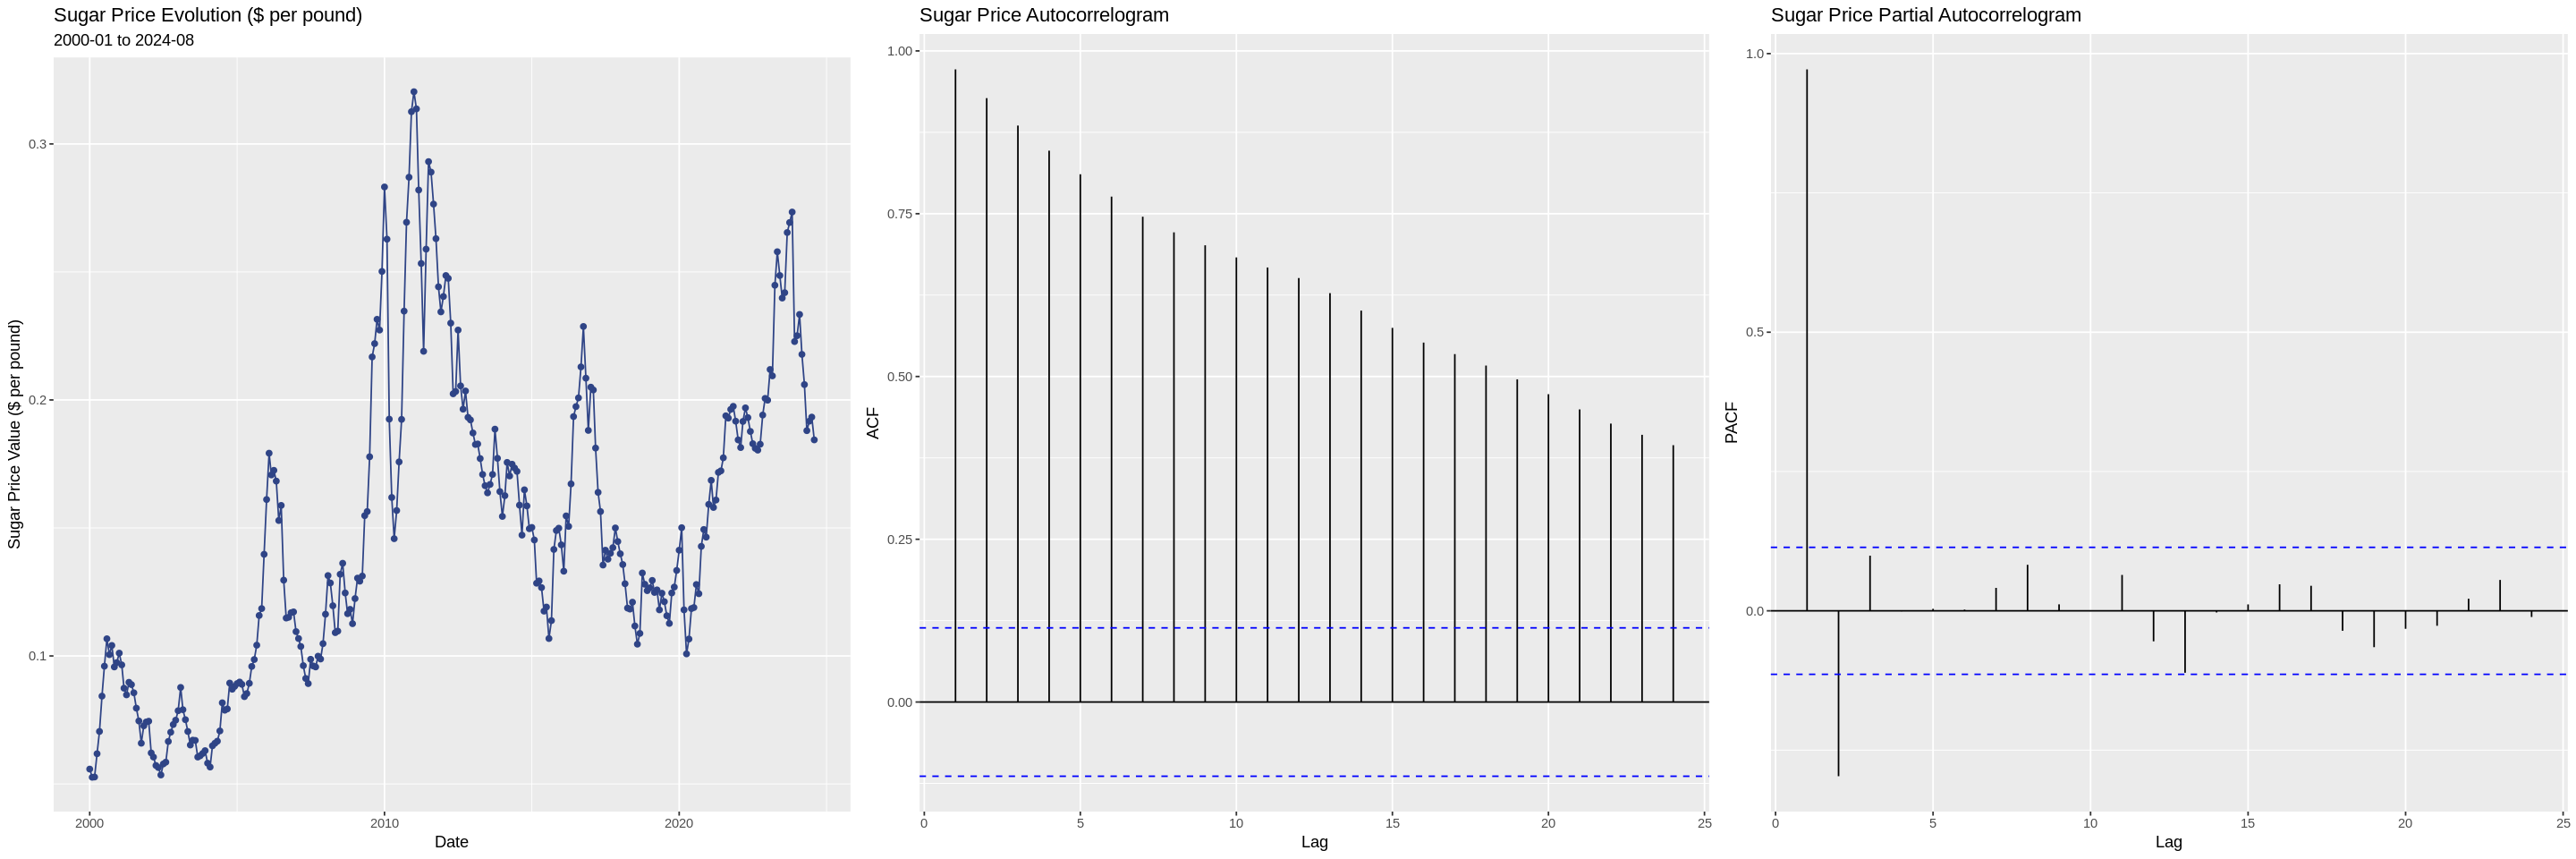


-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
                                                                              Temperature 
-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
        

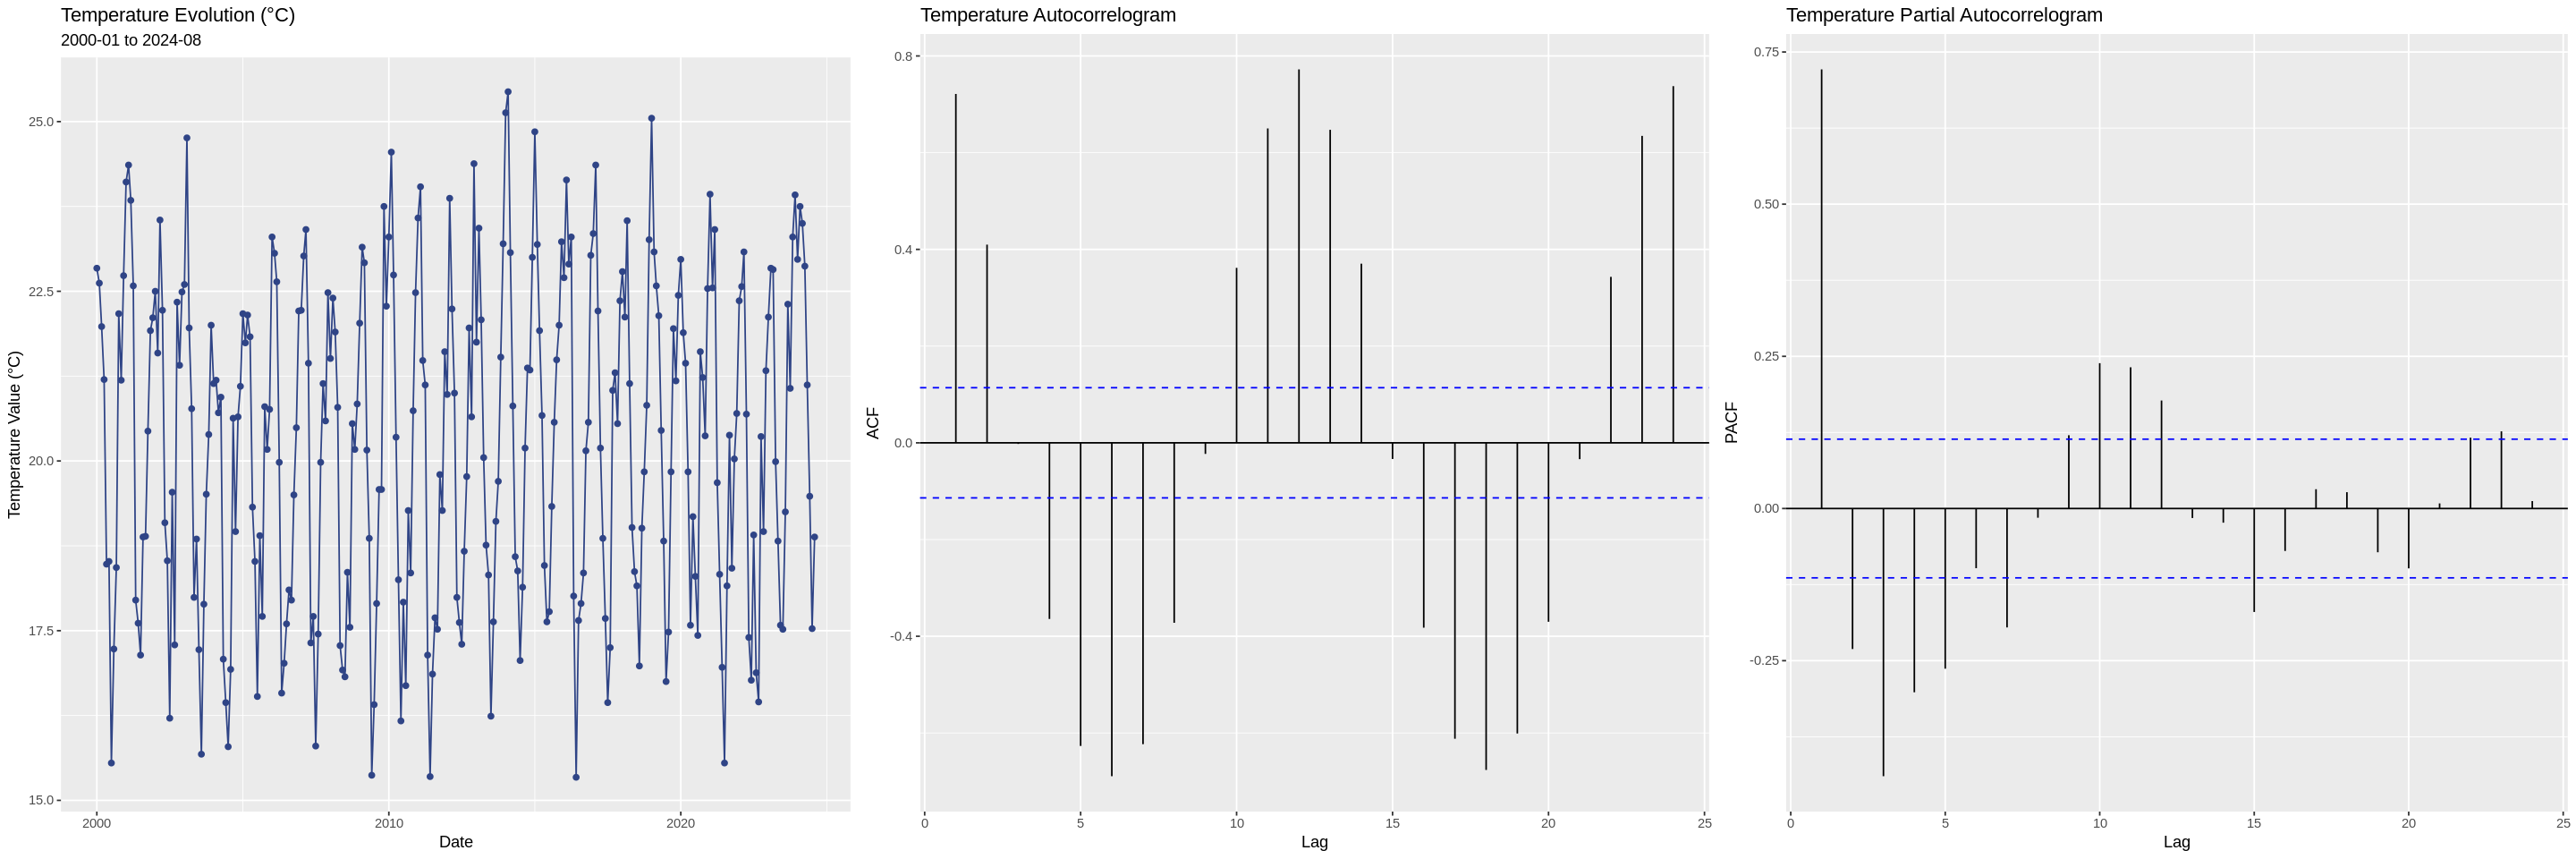


-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
                                                                              Rainfall 
-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
        

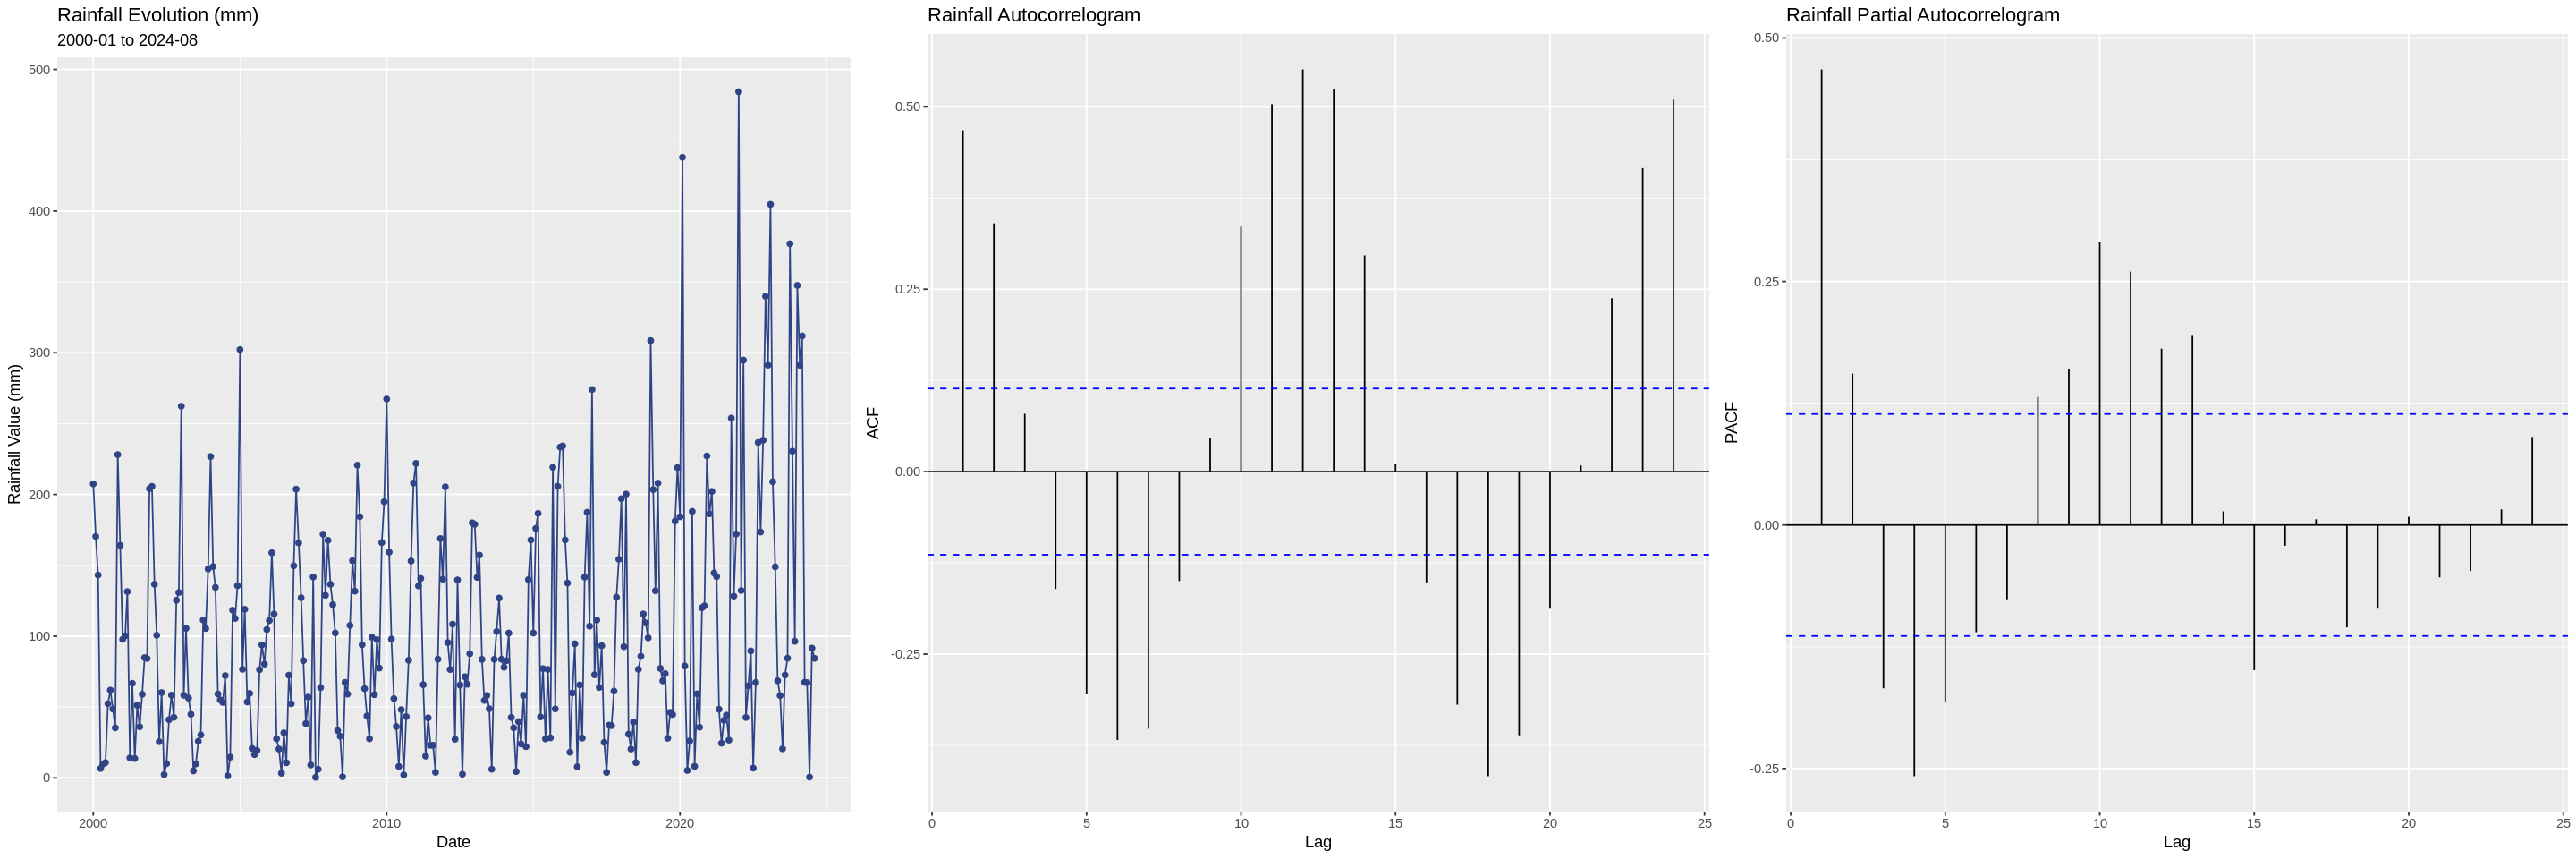


-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
                                                                              Relative Humidity 
-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
        

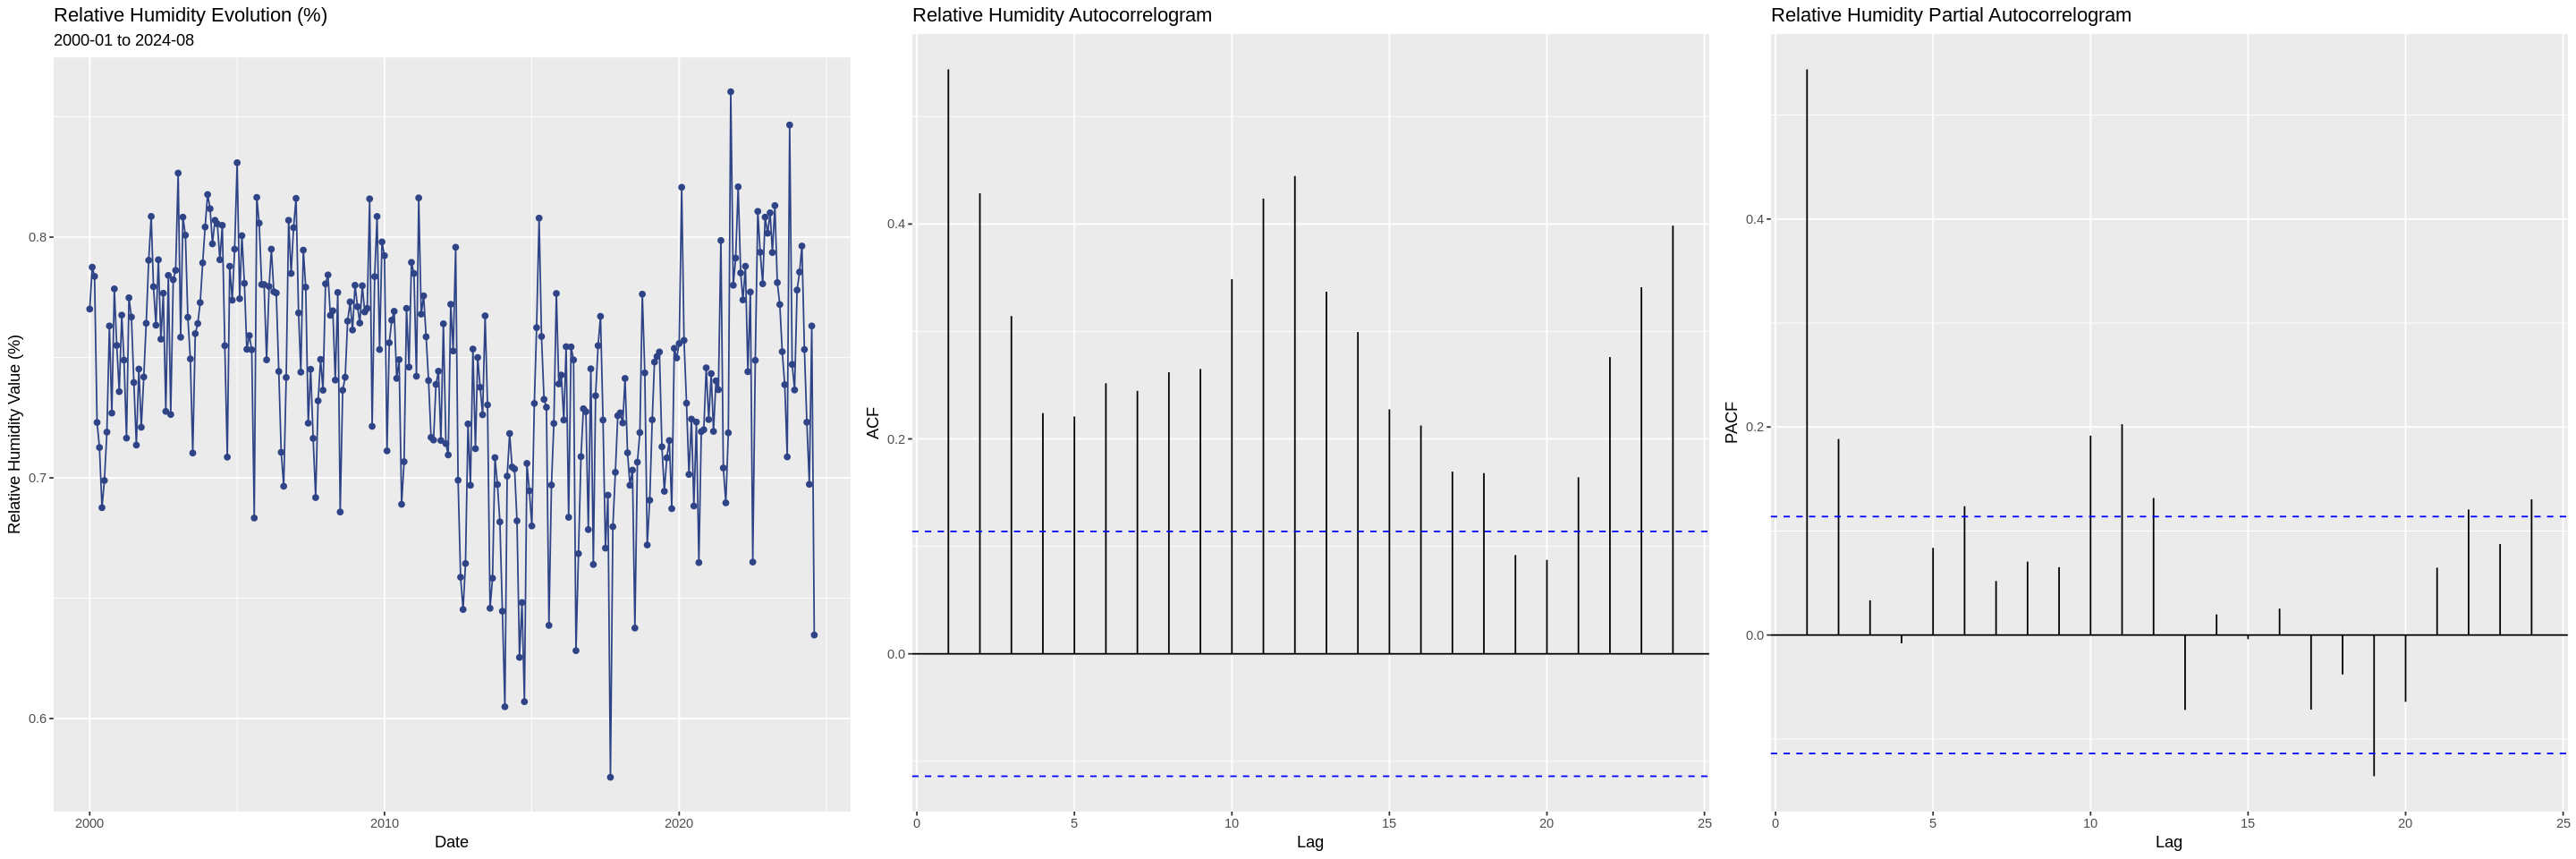


-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
                                                                              Wind Speed 
-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
        

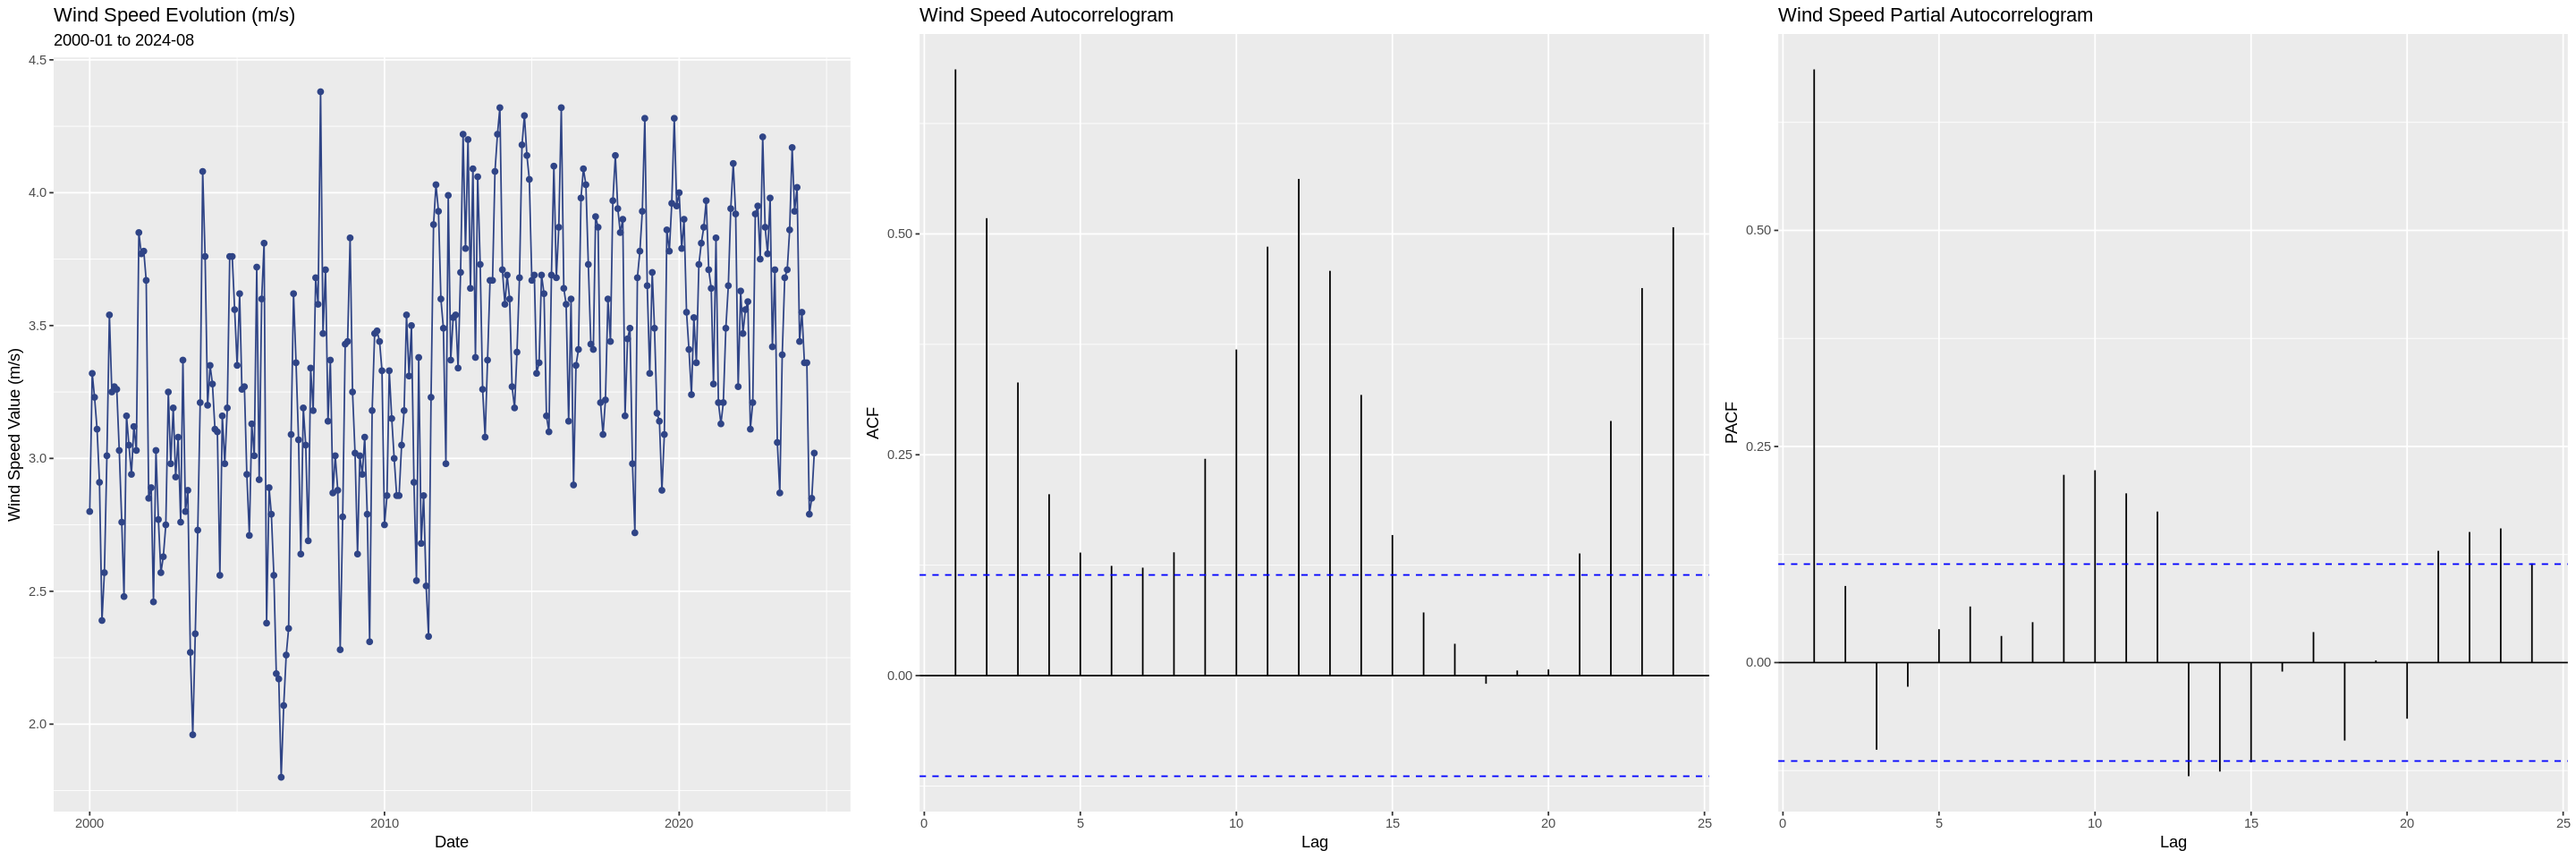


-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
                                                                              Cloud Cover 
-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
        

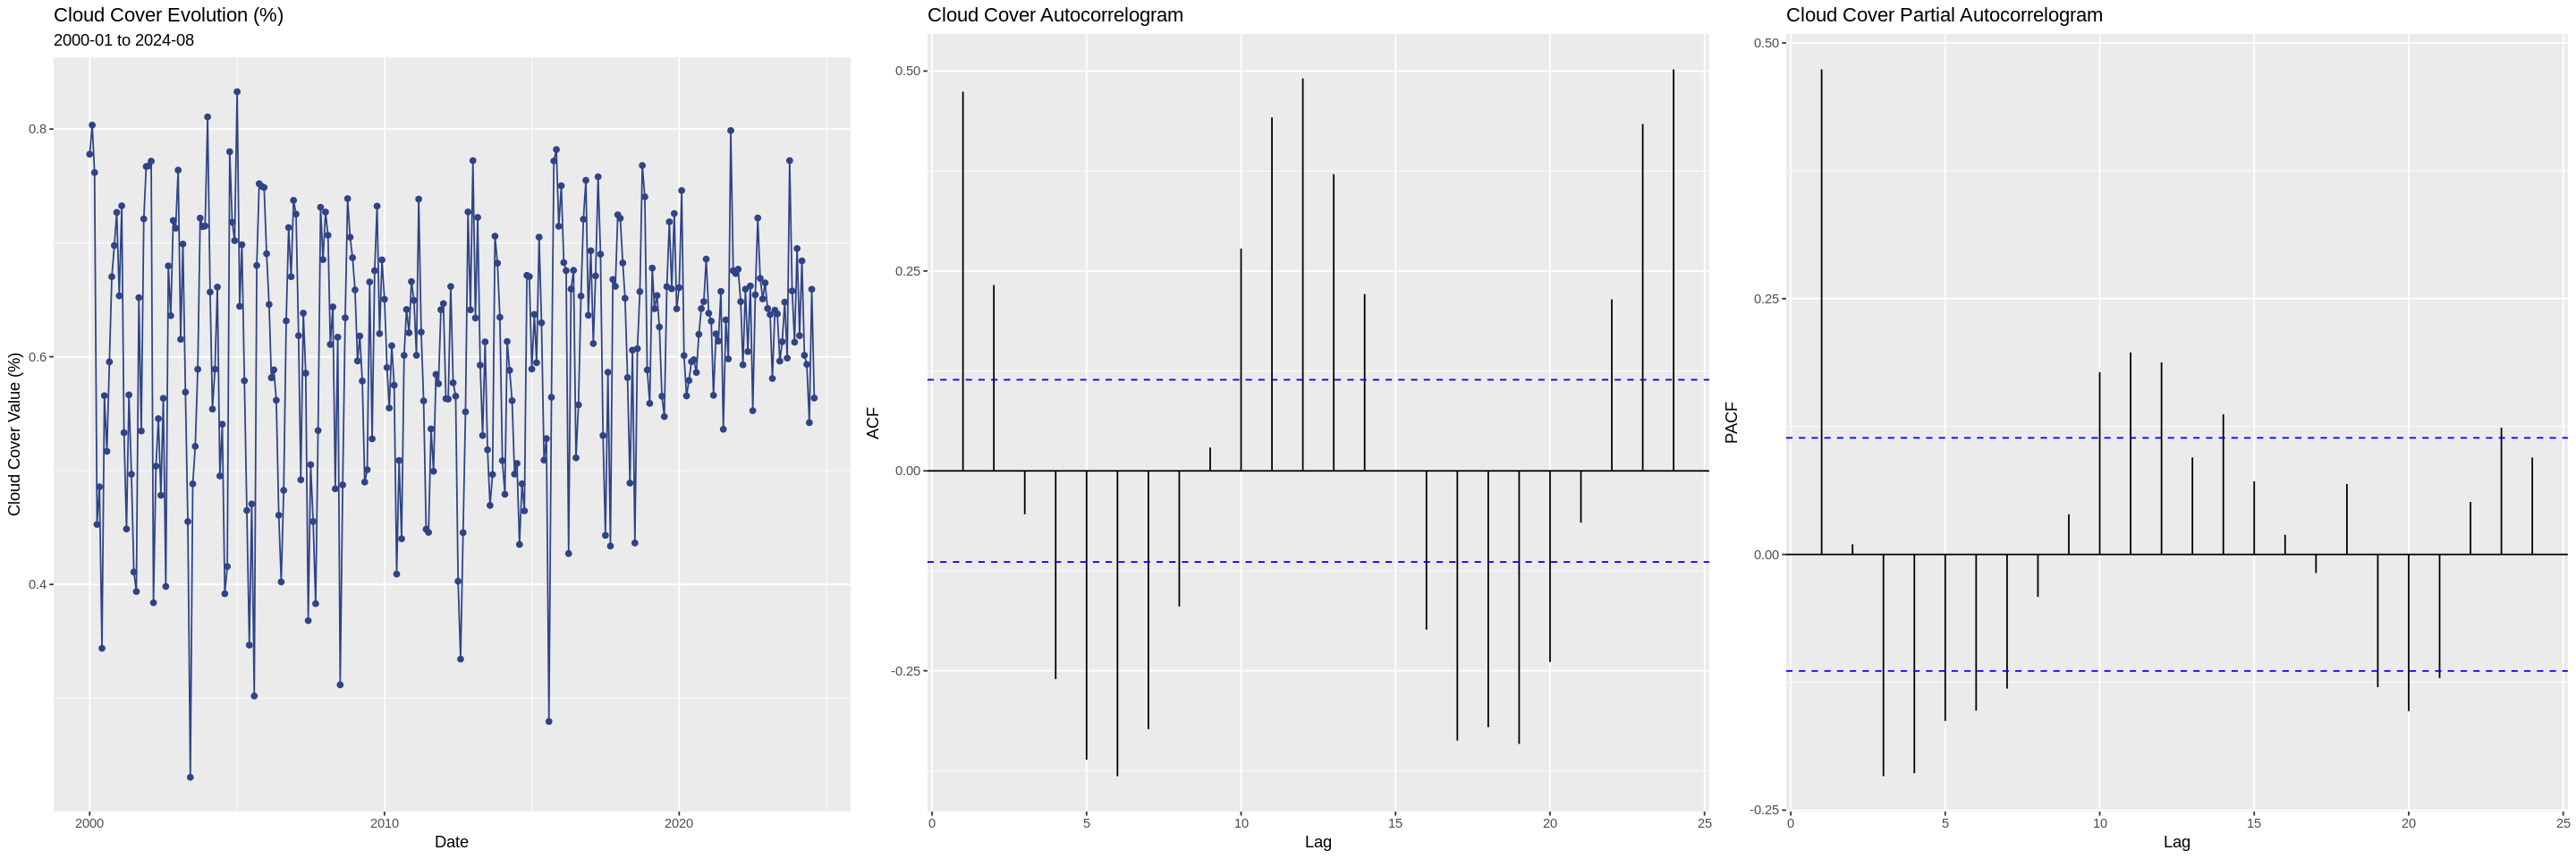


-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
                                                                              Europe Brent Spot Price FOB 
-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
        

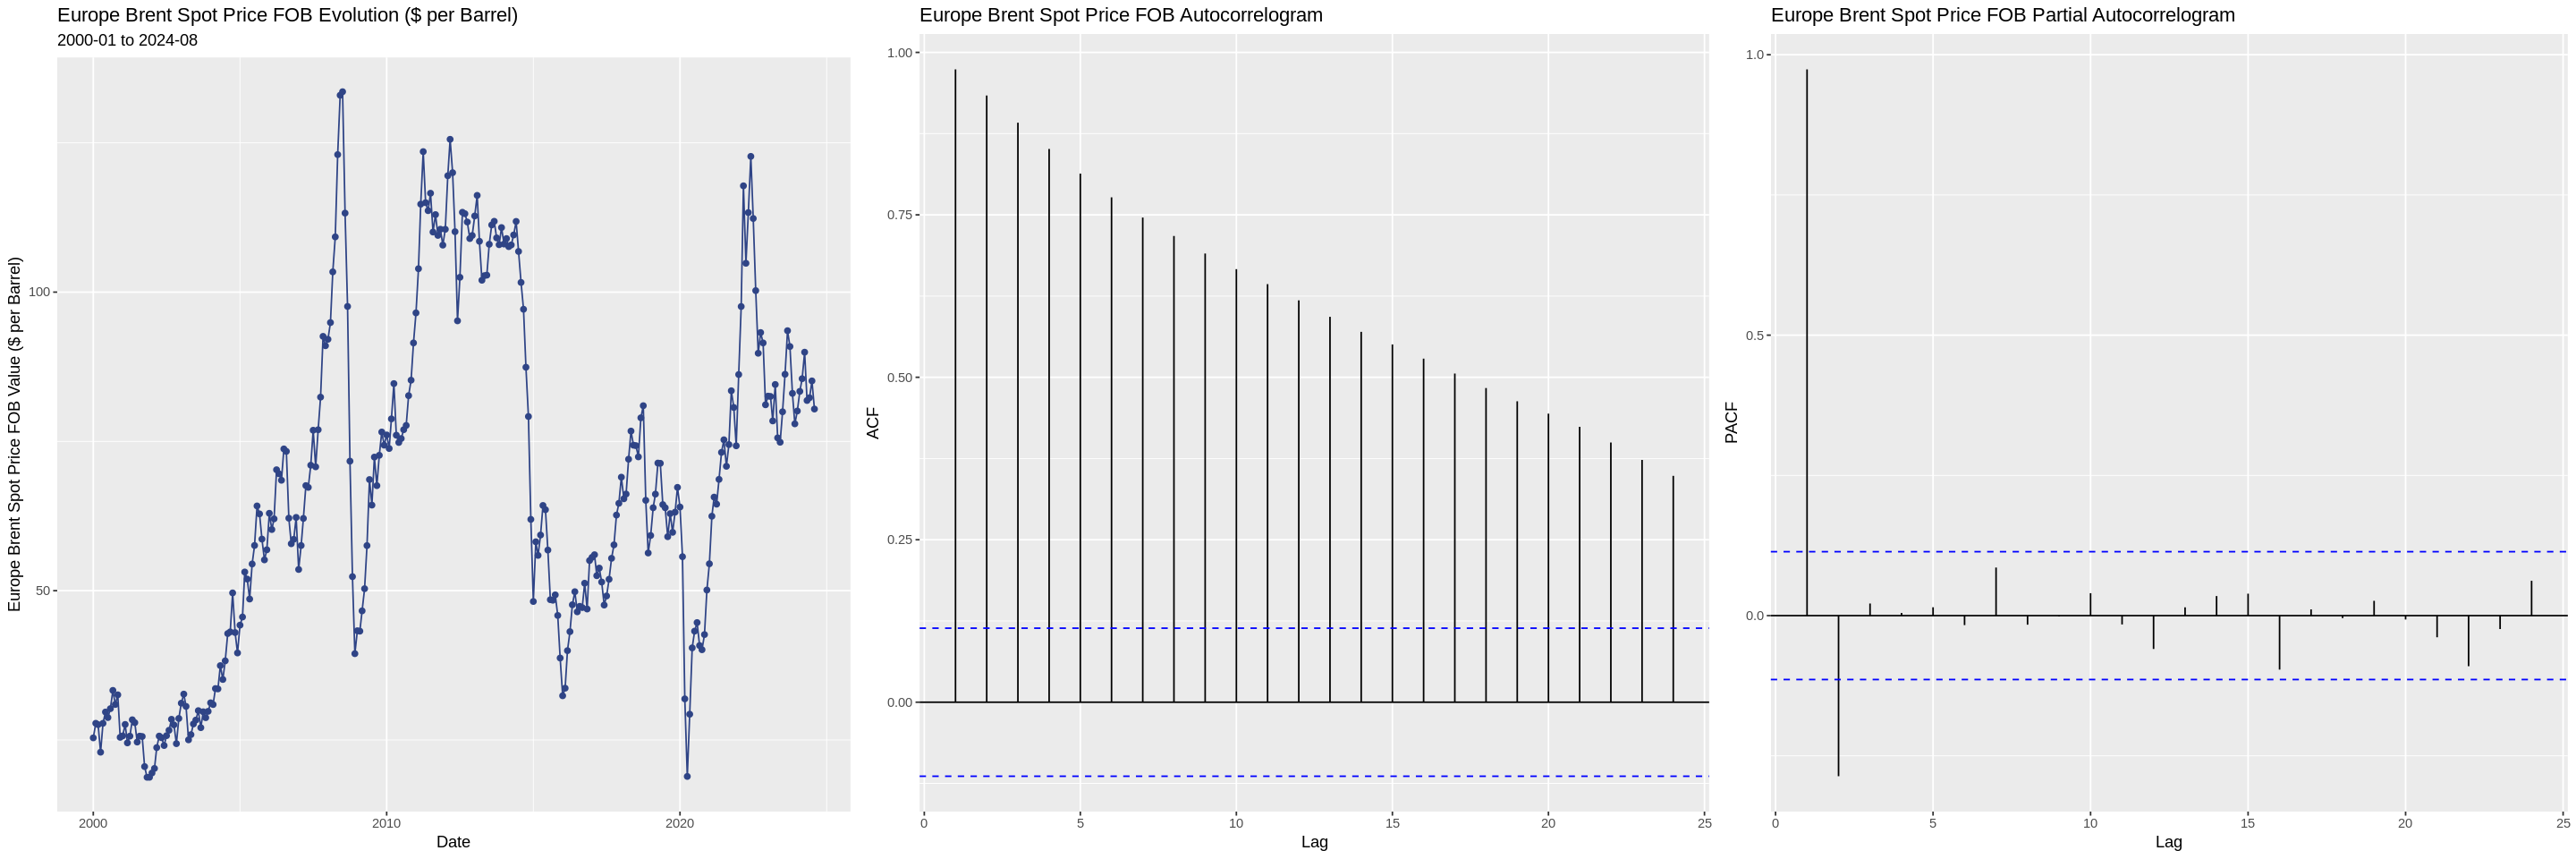


-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
                                                                              Exchange Rate 
-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
        

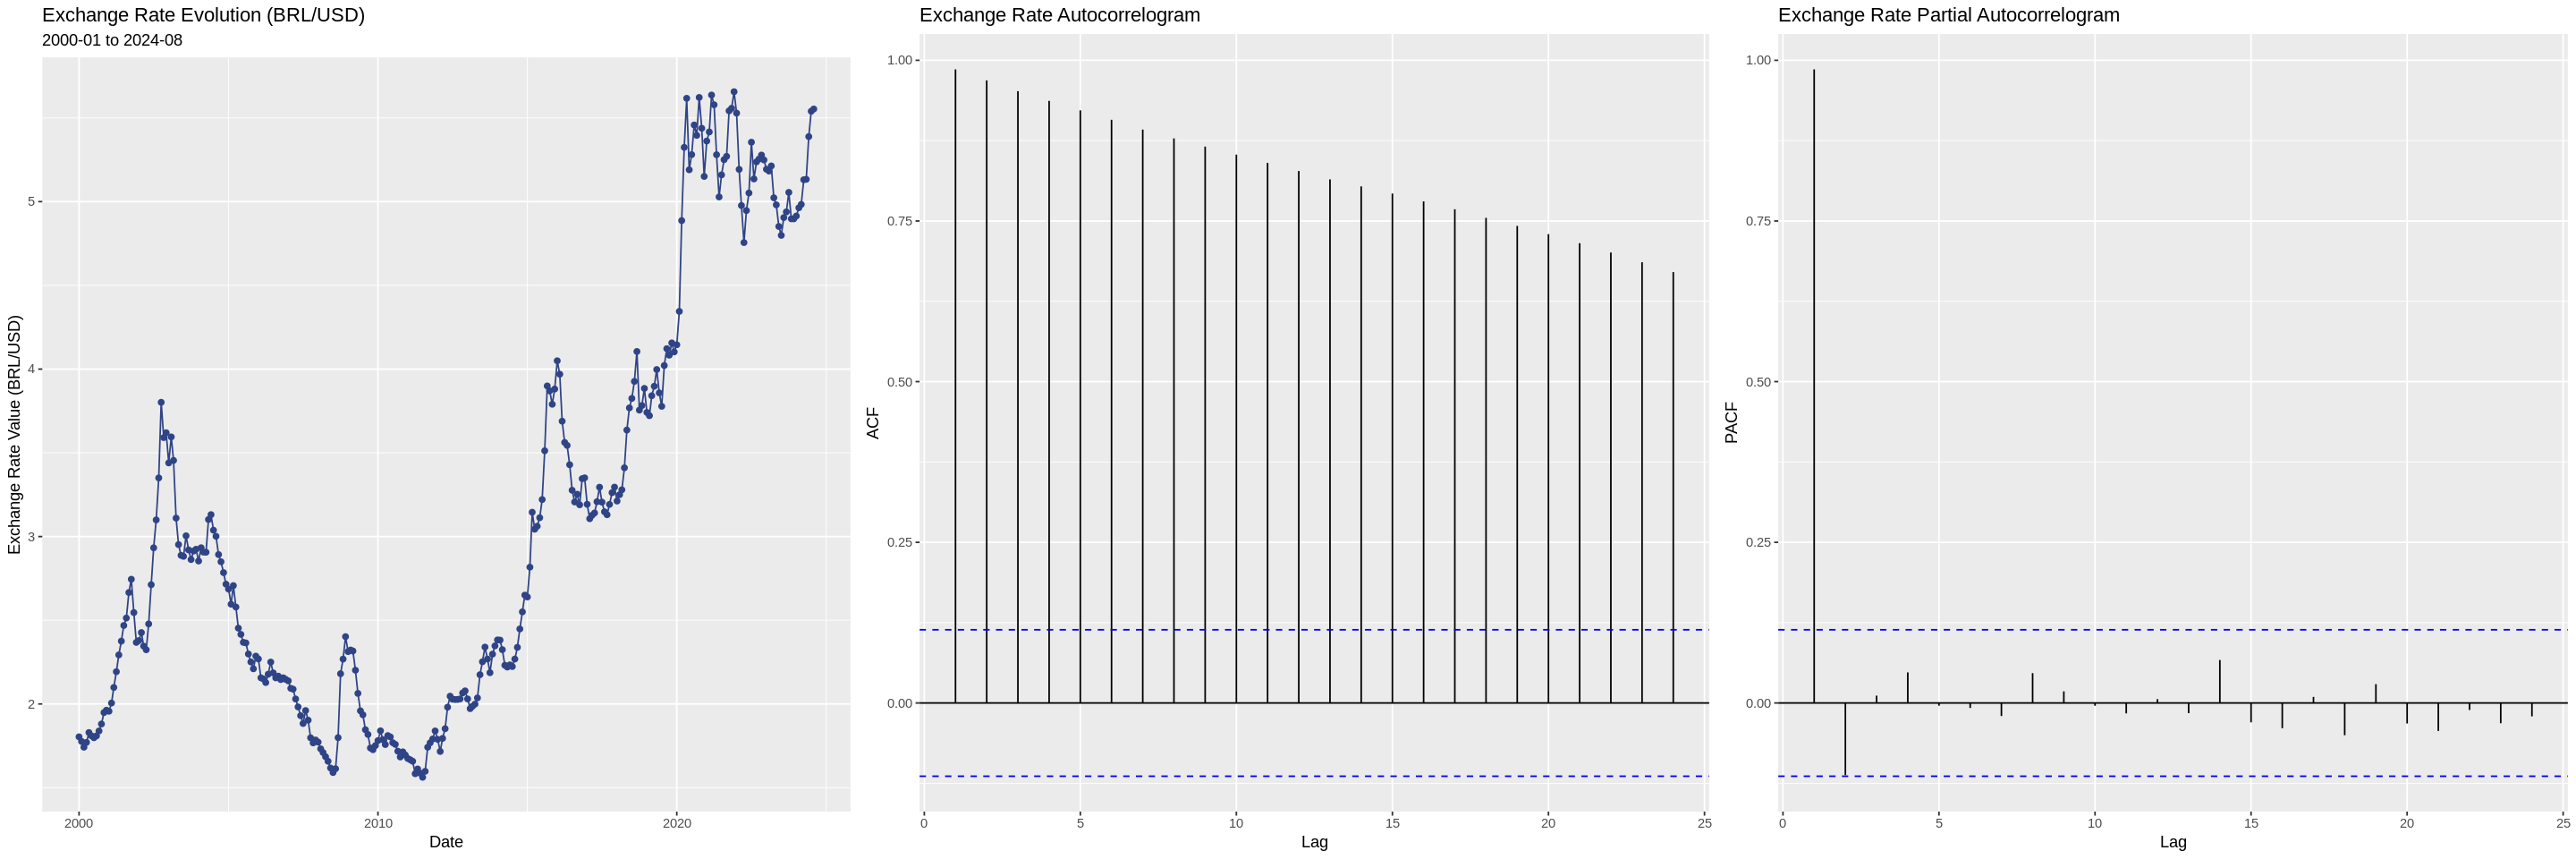

In [77]:
# Ajuster la taille des graphiques dans le Notebook
options(repr.plot.width = 24, repr.plot.height = 8)

all_combined_plots <- list()

# Initialiser le compteur de graphique à 0 (pour la sauvegarde de nos graphiques)
k <- 0

# Parcourir toutes les colonnes à partir de la deuxième
for (col in colnames(df)[-1]) {
  # Incrémenter le compteur de 1
  k <- k + 1
  # Extraire le nom de la variable et l'unité à partir du nom de la colonne
  parts <- unlist(strsplit(col, " \\(")) # Séparer par espace suivi de parenthèse ouvrante
  variable_name <- parts[1] # Partie avant la parenthèse
  unit <- ifelse(length(parts) > 1, gsub("\\)", "", parts[2]), "") # Supprimer la parenthèse fermante

  # Créer un DataFrame temporaire avec la date et la colonne courante
  df_temp <- df[, c("Date", col)]
  colnames(df_temp) <- c("date", "value")


  # Créer le graphique avec ggplot2
  p <- ggplot(data=df_temp, aes(x=date, y=value)) +
    geom_point(color='#2F4486') +
    geom_line(color='#2F4486') +
    xlab('Date') +
    ylab(paste(variable_name, "Value", paste("(",unit,")",sep=""))) +
    labs(title=paste(variable_name, "Evolution", paste("(",unit,")",sep="")),
         subtitle="2000-01 to 2024-08")

  # ACF
  #acf_plot <- acf(df_temp$value, main = paste(variable_name, "Autocorrelogram - January 2000 to August 2024"), na.action = na.pass)
  acf_plot <- autoplot(acf(df_temp$value, plot = FALSE)) +
    ggtitle(paste(variable_name, "Autocorrelogram"))

  #PACF
  #pacf_plot <- pacf(df_temp$value, main = paste(variable_name, "Partial Autocorrelogram - January 2000 to August 2024"), na.action = na.pass)
  pacf_plot <- autoplot(pacf(df_temp$value, plot = FALSE)) +
    ggtitle(paste(variable_name, "Partial Autocorrelogram"))

  # Afficher les graphiques
  combined_plot <- grid.arrange(p, acf_plot, pacf_plot,
                                ncol=3,
                                widths = c(1, 1, 1), # Garde la même largeur relative
                                heights = c(1),       # Garde la hauteur égale
                                padding = unit(1, "cm") # Ajuste l'espacement
                                )

  all_combined_plots[[k]] <- combined_plot

  cat(paste("\n-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------\n",
            "                                                                            ",
            variable_name,
            "\n-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------\n        "))

  ### [Optionnel] Enregistrer les graphiques
  #ggsave(filename=paste0("graphics/graph_",k,"_", variable_name, ".png"), plot=p, width=8, height=5, create.dir=TRUE)       # Représentation graphique
  #ggsave(filename=paste0("graphics/acf_",k,"_", variable_name, ".png"), plot=acf_plot, width=8, height=5, create.dir=TRUE)  # ACF
  #ggsave(filename=paste0("graphics/pacf_",k,"_", variable_name, ".png"), plot=pacf_plot, width=8, height=5, create.dir=TRUE)# PACF

}